# Análisis de rendimiento de bots

## Librerias

In [180]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
import pandas as pd
import numpy as np
import re
import sys

## Constantes

In [181]:
# Directorios
BASE_DIR = Path.cwd()
LOG_DIR = BASE_DIR / "historiales"
OUTPUT_DIR = BASE_DIR / "resultados_analisis"
OUTPUT_DIR.mkdir(exist_ok=True)

# Métricas
METRICAS = ["VPIP", "PFR", "3Bet", "WTSD", "WSD", "WWSF"]
TIPOS_BOT = ["BOT_LLM", "BOT_NN", "BOT_FSM"]
ESTILOS = [
    "TIGHT_PASSIVE",
    "TIGHT_AGGRESSIVE",
    "LOOSE_PASSIVE",
    "LOOSE_AGGRESSIVE",
    "MANIAC",
    "DEFAULT",
]
NOMBRES_ESTILOS = {
    "TIGHT_PASSIVE": "Tight Passive",
    "TIGHT_AGGRESSIVE": "Tight Aggressive",
    "LOOSE_PASSIVE": "Loose Passive",
    "LOOSE_AGGRESSIVE": "Loose Aggressive",
    "MANIAC": "Maniac",
    "DEFAULT": "Default",
}

## Funciones de lectura de logs

In [182]:
# ============================================================
# FUNCIONES DE LECTURA
# ============================================================
def extraer_campo(linea, campo):
    patron = rf"^{re.escape(campo)}\.*\s+(.+)$"
    resultado = re.match(patron, linea.strip(), re.IGNORECASE)

    if resultado:
        return resultado.group(1).strip()

    return None


def convertir_si_no(valor):
    if valor is None:
        return np.nan

    return 1 if valor.strip().upper() == "YES" else 0


def normalizar_tipo(valor):
    if valor is None:
        return None

    return valor.strip().upper()


def normalizar_estilo(valor):
    """
    IMPORTANTE:
    El estilo se obtiene SIEMPRE del campo Style del bloque
    *** EXPERIMENT ***.

    Mapeo exacto de getPlayerStyle():

        DEFAULT -> DEFAULT
        TP      -> TIGHT_PASSIVE
        TAG     -> TIGHT_AGGRESSIVE
        LP      -> LOOSE_PASSIVE
        LAG     -> LOOSE_AGGRESSIVE
        MANIAC  -> MANIAC
    """

    if valor is None:
        return None

    equivalencias = {
        "DEFAULT": "DEFAULT",
        "TP": "TIGHT_PASSIVE",
        "TAG": "TIGHT_AGGRESSIVE",
        "LP": "LOOSE_PASSIVE",
        "LAG": "LOOSE_AGGRESSIVE",
        "MANIAC": "MANIAC",
    }

    return equivalencias.get(valor.strip().upper(), valor.strip().upper())


def parsear_hand(path):

    texto = path.read_text(encoding="utf-8", errors="replace")
    lineas = texto.splitlines()

    match_id = path.parent.name
    hand_match = re.search(r"hand_(\d+)\.log$", path.name, re.IGNORECASE)
    hand_id = int(hand_match.group(1)) if hand_match else None

    jugadores = []
    actual = None
    en_experiment = False
    resumen_jugadores = {}

    # ========================================================
    # BLOQUE EXPERIMENT
    # ========================================================
    for linea in lineas:
        s = linea.strip()

        if s == "*** EXPERIMENT ***":
            en_experiment = True
            continue

        if not en_experiment:
            continue

        if s.startswith("--------- PLAYER"):
            if actual is not None:
                jugadores.append(actual)

            actual = {
                "Match": match_id,
                "Hand": hand_id,
                "File": path.name,
                "Player": None,
                "PlayerId": None,
                "Type": None,
                "Model": None,
                "Style": None,
                "Position": None,
                "Initial stack": np.nan,
                "Final stack": np.nan,
                "VPIP": np.nan,
                "PFR": np.nan,
                "3Bet": np.nan,
                "WTSD": np.nan,
                "WSD": np.nan,
                "WWSF": np.nan,
                # Acciones para calcular AF:
                "Calls": 0,
                "Bets": 0,
                "Raises": 0,
                "Folds": 0,
                "Checks": 0,
                "AllIns": 0,
                "Preflop equity": np.nan,
                "Flop equity": np.nan,
                "Turn equity": np.nan,
                "River equity": np.nan,

                "End reason": None,
            }

            continue

        if actual is None:
            continue

        # ----------------------------------------------------
        # Campos básicos
        # ----------------------------------------------------

        campos = [
            "Player",
            "PlayerId",
            "Type",
            "Model",
            "Style",
            "Position",
            "Initial stack",
            "Final stack",
            "Hand result",
            "Preflop equity",
            "Flop equity",
            "Turn equity",
            "River equity",
        ]

        encontrado = False

        for campo in campos:
            valor = extraer_campo(s, campo)

            if valor is None:
                continue

            if campo == "PlayerId":
                try:
                    valor = int(valor)
                except ValueError:
                    pass

            elif campo in ["Initial stack", "Final stack"]:
                try:
                    valor = float(valor)
                except ValueError:
                    valor = np.nan

            elif campo in [
                "Preflop equity",
                "Flop equity",
                "Turn equity",
                "River equity"
            ]:
                try:
                    valor = float(
                        valor
                        .replace("%", "")
                        .replace(",", ".")
                        .strip()
                    )
                except ValueError:
                    valor = np.nan
                
        
            elif campo == "Type":
                valor = normalizar_tipo(valor)

            elif campo == "Style":
                # REGLA FUNDAMENTAL:
                # nunca inferir el estilo desde el nombre,
                # modelo o acciones.
                valor = normalizar_estilo(valor)

            actual[campo] = valor
            encontrado = True
            break

        if encontrado:
            continue

        # ----------------------------------------------------
        # Métricas YES/NO
        # ----------------------------------------------------

        for metrica in METRICAS:
            valor = extraer_campo(s, metrica)

            if valor is not None:
                actual[metrica] = convertir_si_no(valor)

                break

    if actual is not None:
        jugadores.append(actual)

     # ========================================================
    # RESULTADO DEL SUMMARY
    # ========================================================

    en_summary = False

    for linea in lineas:
        s = linea.strip()

        if s == "*** SUMMARY ***":
            en_summary = True
            continue

        if not en_summary:
            continue

        if s == "*** EXPERIMENT ***":
            break

        # Ejemplo:
        # Seat 1: carlaDos (SB) - Winner (+14)
        # Seat 2: Llama Poker LLM ... (BB) - Fold (FLOP)

        patron = r"^Seat\s+\d+:\s+(.+?)\s+\([^)]+\)\s+-\s+(.+)$"

        resultado = re.match(
            patron,
            s,
            re.IGNORECASE
        )

        if resultado:

            nombre = resultado.group(1).strip()
            motivo = resultado.group(2).strip()

            resumen_jugadores[nombre] = motivo

    # ========================================================
    # ACCIONES DEL HISTORIAL
    # ========================================================
    #
    # AF = (Bets + Raises) / Calls
    #
    # Las acciones se extraen del historial de la mano,
    # mientras que Style/Type/Model salen del EXPERIMENT.
    # ========================================================

    acciones = {}

    for jugador in jugadores:
        nombre = jugador.get("Player")

        if nombre:
            acciones[nombre] = {
                "Calls": 0,
                "Bets": 0,
                "Raises": 0,
                "Folds": 0,
                "Checks": 0,
                "AllIns": 0,
            }

    en_historial = False

    for linea in lineas:
        s = linea.strip()

        if s == "*** HOLE CARDS ***":
            en_historial = True
            continue

        if not en_historial:
            continue

        if (
            s.startswith("*** SHOW DOWN ***")
            or s.startswith("*** SUMMARY ***")
            or s.startswith("*** EXPERIMENT ***")
        ):
            break

        if (
            s.startswith("*** FLOP ***")
            or s.startswith("*** TURN ***")
            or s.startswith("*** RIVER ***")
        ):
            continue

        if ":" not in s:
            continue

        nombre, accion = s.split(":", 1)

        nombre = nombre.strip()
        accion = accion.strip().lower()

        if nombre not in acciones:
            continue

        # El all-in se contabiliza además como acción agresiva.
        if "fold" in accion:
            acciones[nombre]["Folds"] += 1

        elif "check" in accion:
            acciones[nombre]["Checks"] += 1

        elif "call" in accion:
            acciones[nombre]["Calls"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "raise" in accion:
            acciones[nombre]["Raises"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "bet" in accion:
            acciones[nombre]["Bets"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "is all-in" in accion:
            acciones[nombre]["Bets"] += 1
            acciones[nombre]["AllIns"] += 1

    for jugador in jugadores:
        nombre = jugador.get("Player")

         # Añadir acciones
        if nombre in acciones:
            jugador.update(acciones[nombre])
    
        # Añadir motivo de finalización
        if nombre in resumen_jugadores:
            jugador["End reason"] = resumen_jugadores[nombre]

    return jugadores


def analizar_completo():

    print("Parseando todos los datos...")

    # Listar todos los experimentos
    df_completo = {}
    for exp in LOG_DIR.iterdir():
        if not exp.is_dir():
            continue

        # Generar diccionario de dataframes para el experimento
        df_completo[exp.name] = {}

        # Directorios : Uno por experimento
        for variante in exp.iterdir():
            if not variante.is_dir():
                continue

            # Generar diccionarios para cada variante del experimento
            df_acumulado = pd.DataFrame()
            for partida in variante.iterdir():
                if not partida.is_dir():
                    continue

                for mano in sorted(partida.iterdir()):
                    # Generar dataframe uniendo cada partida de la variante
                    df_nuevo = pd.DataFrame(parsear_hand(mano))
                    df_acumulado = pd.concat(
                        [df_nuevo, df_acumulado], ignore_index=True
                    )

                # Incluir dataframe completo al diccionario del experimento
                df_completo[exp.name][variante.name] = df_acumulado

    print("Todos los datos parseados correctamente!")
    return df_completo

## Funciones de análisis

In [183]:
def calcular_metricas_por_grupo(datos, grupo):
    return datos.groupby(grupo, dropna=False)[METRICAS].mean() * 100


def resumen_bots(df_bots):

    resumen_bots = calcular_metricas_por_grupo(df_bots, "Type")

    # Etiquetas más legibles.
    nombres_tipos = {"BOT_LLM": "LLM", "BOT_NN": "Red Neuronal", "BOT_FSM": "FSM"}
    resumen_bots.index = [nombres_tipos.get(x, x) for x in resumen_bots.index]

    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(resumen_bots))

    width = 0.12
    offsets = np.linspace(-2.5 * width, 2.5 * width, len(METRICAS))

    for offset, metrica in zip(offsets, METRICAS):
        ax.bar(x + offset, resumen_bots[metrica], width=width, label=metrica)

    ax.set_title("Perfil de comportamiento de los bots")
    ax.set_ylabel("Porcentaje (%)")
    ax.set_xlabel("Bot")
    ax.set_ylim(0, 100)

    # Mostrar claramente los extremos del eje.
    ax.axhline(0, linewidth=1.2, alpha=0.65)
    ax.axhline(100, linewidth=1.2, alpha=0.65)

    ax.set_yticks(np.arange(0, 101, 10))
    ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)])

    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.9, alpha=0.45)
    ax.xaxis.grid(False)

    ax.set_axisbelow(True)
    ax.set_xticks(x)

    ax.set_xticklabels(resumen_bots.index)
    ax.legend(ncol=3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "punto_0_bots_barras.png", dpi=300, bbox_inches="tight")
    plt.show()

    return resumen_bots


## Funciones generales

In [184]:
def test():

    # Experimentos
    experimentos = datos.keys()
    print(experimentos)

    # Variantes
    for exp in experimentos:
        variantes = list(datos[exp].keys())
        print("Experimento:", exp)
        print("Variantes:", variantes)

    # Dataframe de cada uno
    print("INFO COMPLETA")
    for exp in datos.keys():
        print(f"EXPERIMENTO-{exp}")
        for var in datos[exp]:
            print(f"\tVARIANTE-{var}")
        print()

    # Ver columnas de cualquier dataframe
    columnas = next(iter(next(iter(datos.values())).values()))
    columnas = columnas.columns.tolist()
    print("Columnas:", columnas)


def print_titulo(title, ancho=120):

    # Calcular espacios
    titulo = title.upper()
    espacios = ancho - len(titulo) - 2
    iguales = espacios // 2

    # Mostrar con formato: === <TITULO> ===
    print(("=" * iguales) + f" {titulo} " + ("=" * iguales))

    
def get_dataframes_experimento(all_data, exp):
    return all_data[exp]


def get_dataframe_variante(all_data, exp, var):
    return all_data[exp][var]


## Análisis completo

In [185]:
# Leer todos los experimentos
# Formato:
#
# {
#  "EXP1": {
#    "VAR1": DF1,
#    "VAR2": DF2,
#    ...
#  },
#  "EXP2": {
#    "VAR1": DF1,
#    "VAR2": DF2,
#    ...
#  },
#  "EXP3": {
#    "VAR1": DF1,
#    "VAR2": DF2,
#    ...
#  },
#
#  ...
#
# }
datos = analizar_completo()
test()

for experimento, variantes in datos.items():
    for variante, df in variantes.items():
        print_titulo(f"{experimento.upper()} - {variante.upper()}")
        print(df.head(5))
        print()  # Línea vacía entre variantes

print()  # Línea adicional entre experimentos


# Mostrar columnas del dataframe
columnas = next(iter(next(iter(datos.values())).values()))
columnas = columnas.columns.tolist()
print("Columnas:", columnas)


# Experimentos
experimentos = list(datos.keys())

# Variantes
for exp in experimentos:
    variantes = list(datos[exp].keys())
    print("Experimento:", exp)
    print("\tVariantes:", variantes)


Parseando todos los datos...
Todos los datos parseados correctamente!
dict_keys(['1-bot_vs_1-bot', '1-bot_vs_1-humano', '1-humano_vs_4-bots', '6-bots'])
Experimento: 1-bot_vs_1-bot
Variantes: ['llama_cfr', 'llama_fsm']
Experimento: 1-bot_vs_1-humano
Variantes: ['1v1-medio', '1v1-novato', '1v1-profesional']
Experimento: 1-humano_vs_4-bots
Variantes: ['Humano_A', 'Humano_B']
Experimento: 6-bots
Variantes: ['1-unique', '6-mixed']
INFO COMPLETA
EXPERIMENTO-1-bot_vs_1-bot
	VARIANTE-llama_cfr
	VARIANTE-llama_fsm

EXPERIMENTO-1-bot_vs_1-humano
	VARIANTE-1v1-medio
	VARIANTE-1v1-novato
	VARIANTE-1v1-profesional

EXPERIMENTO-1-humano_vs_4-bots
	VARIANTE-Humano_A
	VARIANTE-Humano_B

EXPERIMENTO-6-bots
	VARIANTE-1-unique
	VARIANTE-6-mixed

Columnas: ['Match', 'Hand', 'File', 'Player', 'PlayerId', 'Type', 'Model', 'Style', 'Position', 'Initial stack', 'Final stack', 'VPIP', 'PFR', '3Bet', 'WTSD', 'WSD', 'WWSF', 'Calls', 'Bets', 'Raises', 'Folds', 'Checks', 'AllIns', 'Preflop equity', 'Flop equity',

In [186]:
# Comprobar End reason en los datos recién procesados

for experimento, variantes in datos.items():

    for variante, df in variantes.items():

        if 'End reason' in df.columns:

            print(f"\n{experimento} - {variante}")
            print(df[
                [
                    'Player',
                    'Type',
                    'Hand result',
                    'End reason'
                ]
            ].head(10))


1-bot_vs_1-bot - llama_cfr
            Player     Type Hand result        End reason
0        DeepCFR#1   BOT_NN        LOST               NaN
1  LlamaPokerLLM#0  BOT_LLM         WON      Winner (+12)
2  LlamaPokerLLM#0  BOT_LLM         WON     Winner (+196)
3        DeepCFR#1   BOT_NN         WON       Winner (+4)
4        DeepCFR#1   BOT_NN         WON      Winner (+32)
5  LlamaPokerLLM#0  BOT_LLM        LOST  Lost at Showdown
6  LlamaPokerLLM#0  BOT_LLM         WON      Winner (+32)
7        DeepCFR#1   BOT_NN        LOST  Lost at Showdown
8        DeepCFR#1   BOT_NN        LOST    Fold (PREFLOP)
9  LlamaPokerLLM#0  BOT_LLM         WON      Winner (+12)

1-bot_vs_1-bot - llama_fsm
            Player     Type Hand result        End reason
0  LlamaPokerLLM#0  BOT_LLM         WON     Winner (+196)
1            FSM#1  BOT_FSM        LOST               NaN
2            FSM#1  BOT_FSM        LOST       Fold (FLOP)
3  LlamaPokerLLM#0  BOT_LLM         WON       Winner (+8)
4  LlamaPokerLLM

In [187]:
# Todos los experimentos y variantes para acceder a los dataframes
PRUEBA_1 = experimentos[0]
VAR_1_1 = list(datos[PRUEBA_1])[0]
VAR_1_2 = list(datos[PRUEBA_1])[1]

PRUEBA_2 = experimentos[1]
VAR_2_1 = list(datos[PRUEBA_2])[0]
VAR_2_2 = list(datos[PRUEBA_2])[1]
VAR_2_3 = list(datos[PRUEBA_2])[2]

PRUEBA_3 = experimentos[2]
VAR_3_1 = list(datos[PRUEBA_3])[0]
VAR_3_2 = list(datos[PRUEBA_3])[1]

PRUEBA_4 = experimentos[3]
VAR_4_1 = list(datos[PRUEBA_4])[0]


# Obtener todos los dataframes por separado
# EXPERIMENTO 1
prueba1_var1_data = get_dataframe_variante(datos, PRUEBA_1, VAR_1_1)
prueba1_var2_data = get_dataframe_variante(datos, PRUEBA_1, VAR_1_2)
print("\n\nSizes:", len(prueba1_var1_data), len(prueba1_var2_data))

# EXPERIMENTO 2
prueba2_var1_data = get_dataframe_variante(datos, PRUEBA_2, VAR_2_1)
prueba2_var2_data = get_dataframe_variante(datos, PRUEBA_2, VAR_2_2)
prueba2_var3_data = get_dataframe_variante(datos, PRUEBA_2, VAR_2_3)
print("Sizes:", len(prueba2_var1_data), len(prueba2_var2_data), len(prueba2_var3_data))

# EXPERIMENTO 3
prueba3_var1_data = get_dataframe_variante(datos, PRUEBA_3, VAR_3_1)
prueba3_var2_data = get_dataframe_variante(datos, PRUEBA_3, VAR_3_2)
print("Sizes:", len(prueba3_var1_data), len(prueba3_var2_data))

# EXPERIMENTO 4
prueba4_var1_data = get_dataframe_variante(datos, PRUEBA_4, VAR_4_1)
print("Sizes:", len(prueba4_var1_data))

# Unir todos los datos en un solo dataframe
all_data = pd.concat(
    [
        prueba1_var1_data, prueba1_var2_data,
        prueba2_var1_data, prueba2_var2_data, prueba2_var3_data,
        prueba3_var1_data, prueba3_var2_data,
        prueba4_var1_data
    ],
    ignore_index=True
)

# Dataframe solo con información de bots
all_bot_data = all_data[all_data['Type'] != 'HUMAN']

print("Numero de entradas en total:", len(all_bot_data))



Sizes: 1334 82
Sizes: 550 610 278
Sizes: 835 145
Sizes: 558
Numero de entradas en total: 3477


# Análisis general

## Pregunta 0 - ¿Cómo juega cada bot?
- VPIP, PFR, 3Bet, WTSD, WSD, WWSF y AF.
- Comparar LLM Local, LLM Online, Red Neuronal y FSM.
- Dentro de los LLM, comparar también los distintos estilos.
- Gráficas:  Barras

In [188]:
### BOTS POR TIPO ###
def dist_bots_completa():
    
    columnas = ['VPIP', 'PFR', '3Bet', 'WTSD', 'WSD', 'WWSF']

    df_plot = all_bot_data.groupby('Type')[columnas].mean() * 100

    ax = df_plot.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Bot')
    plt.ylabel('Porcentaje (%)')
    plt.title('Pregunta 0 - Estadísticas de los bots (A)')
    plt.xticks(rotation=0)
    plt.legend(title='Métricas de juego')
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_0_distribucion_todos_los_bots.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()


### BOTS LLM POR ESTILO ###
def dist_llm_style():

    columnas = ['VPIP', 'PFR', '3Bet', 'WTSD', 'WSD', 'WWSF']

    df_plot = (
        all_bot_data[all_bot_data['Type'] == 'BOT_LLM']
        .groupby('Style')[columnas]
        .mean() * 100
    )

    df_plot.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Style')
    plt.ylabel('Porcentaje (%)')
    plt.title('Pregunta 0 - Estadísticas de los LLM por estilo (B)')
    plt.xticks(rotation=0)
    plt.ylim(0, 100)
    plt.legend(title='Estilos')
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_0_distribucion_llm_bots_por_style.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    

In [189]:
### ============================================================
### PREGUNTA 0 - TODAS LAS GRÁFICAS JUNTAS
### ============================================================

def dist_completa_pregunta_0():

    columnas = [
        'VPIP',
        'PFR',
        '3Bet',
        'WTSD',
        'WSD',
        'WWSF'
    ]


    # ========================================================
    # DATOS - BOTS POR TIPO
    # ========================================================

    df_tipo = (
        all_bot_data
        .groupby('Type')[columnas]
        .mean()
        * 100
    )


    # ========================================================
    # DATOS - LLM POR ESTILO
    # ========================================================

    df_estilo = (
        all_bot_data[
            all_bot_data['Type'] == 'BOT_LLM'
        ]
        .groupby('Style')[columnas]
        .mean()
        * 100
    )


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 7)
    )


    # ========================================================
    # GRÁFICA 1 - BOTS POR TIPO
    # ========================================================

    df_tipo.plot(
        kind='bar',
        ax=axes[0]
    )

    axes[0].set_xlabel(
        'Bot'
    )

    axes[0].set_ylabel(
        'Porcentaje (%)'
    )

    axes[0].set_title(
        'Estadísticas de los bots (A)'
    )

    axes[0].set_xticklabels(
        axes[0].get_xticklabels(),
        rotation=0
    )

    axes[0].set_ylim(
        0,
        100
    )

    axes[0].legend(
        title='Métricas de juego'
    )

    axes[0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # GRÁFICA 2 - LLM POR ESTILO
    # ========================================================

    df_estilo.plot(
        kind='bar',
        ax=axes[1]
    )

    axes[1].set_xlabel(
        'Estilo'
    )

    axes[1].set_ylabel(
        'Porcentaje (%)'
    )

    axes[1].set_title(
        'Estadísticas de los LLM por estilo (B)'
    )

    axes[1].set_xticklabels(
        axes[1].get_xticklabels(),
        rotation=0
    )

    axes[1].set_ylim(
        0,
        100
    )

    axes[1].legend(
        title='Métricas de juego'
    )

    axes[1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 0 - Estadísticas de los bots',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.95
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_0_completa.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

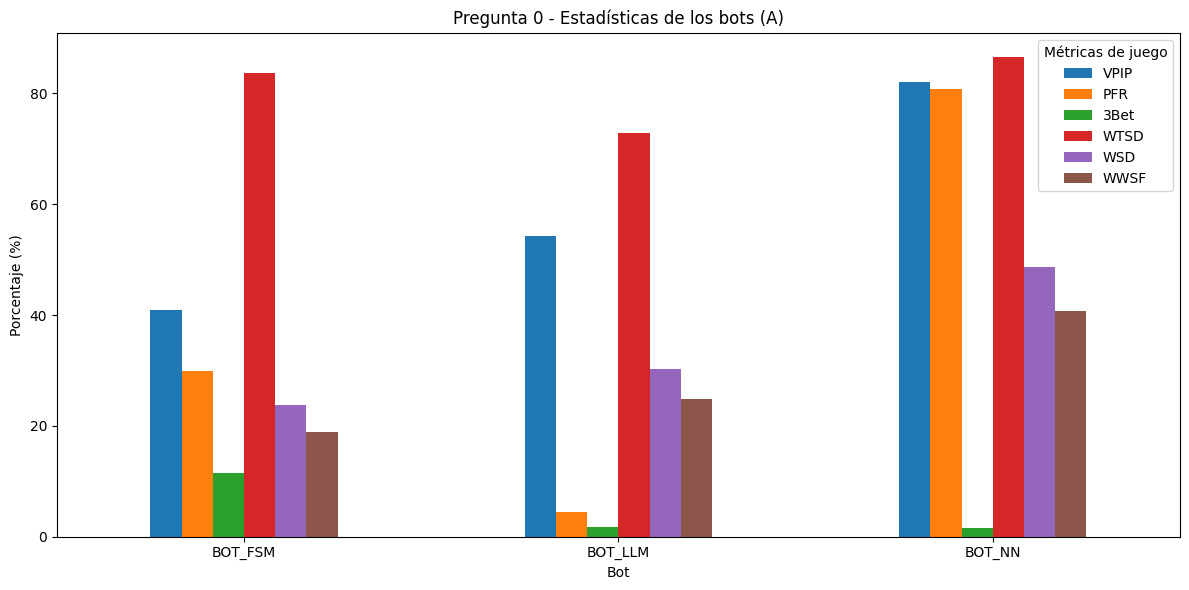

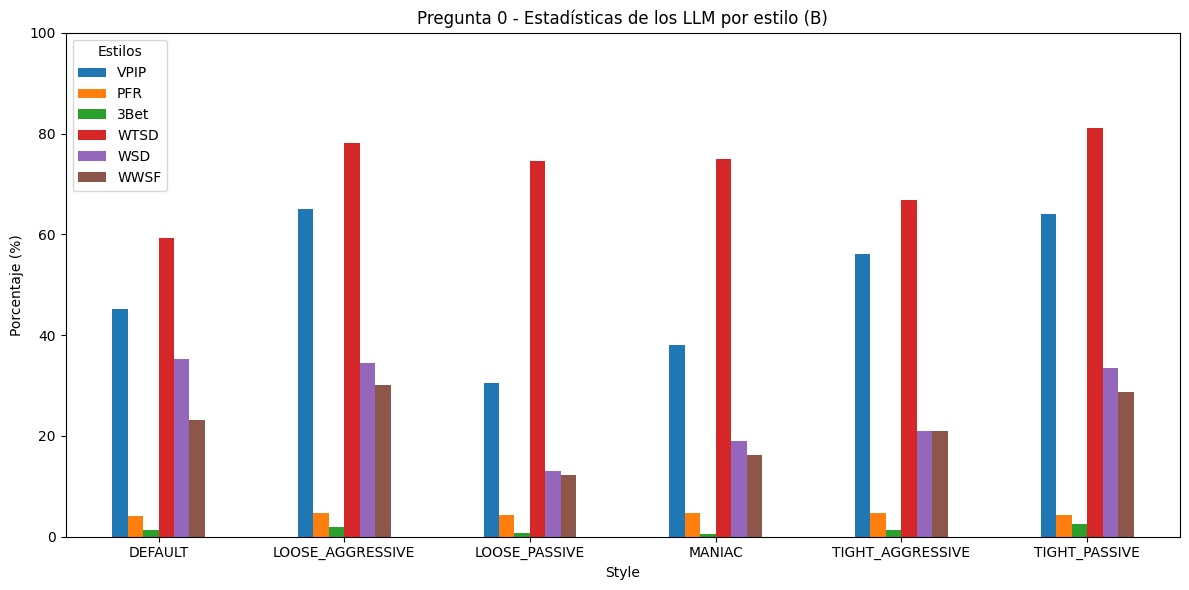

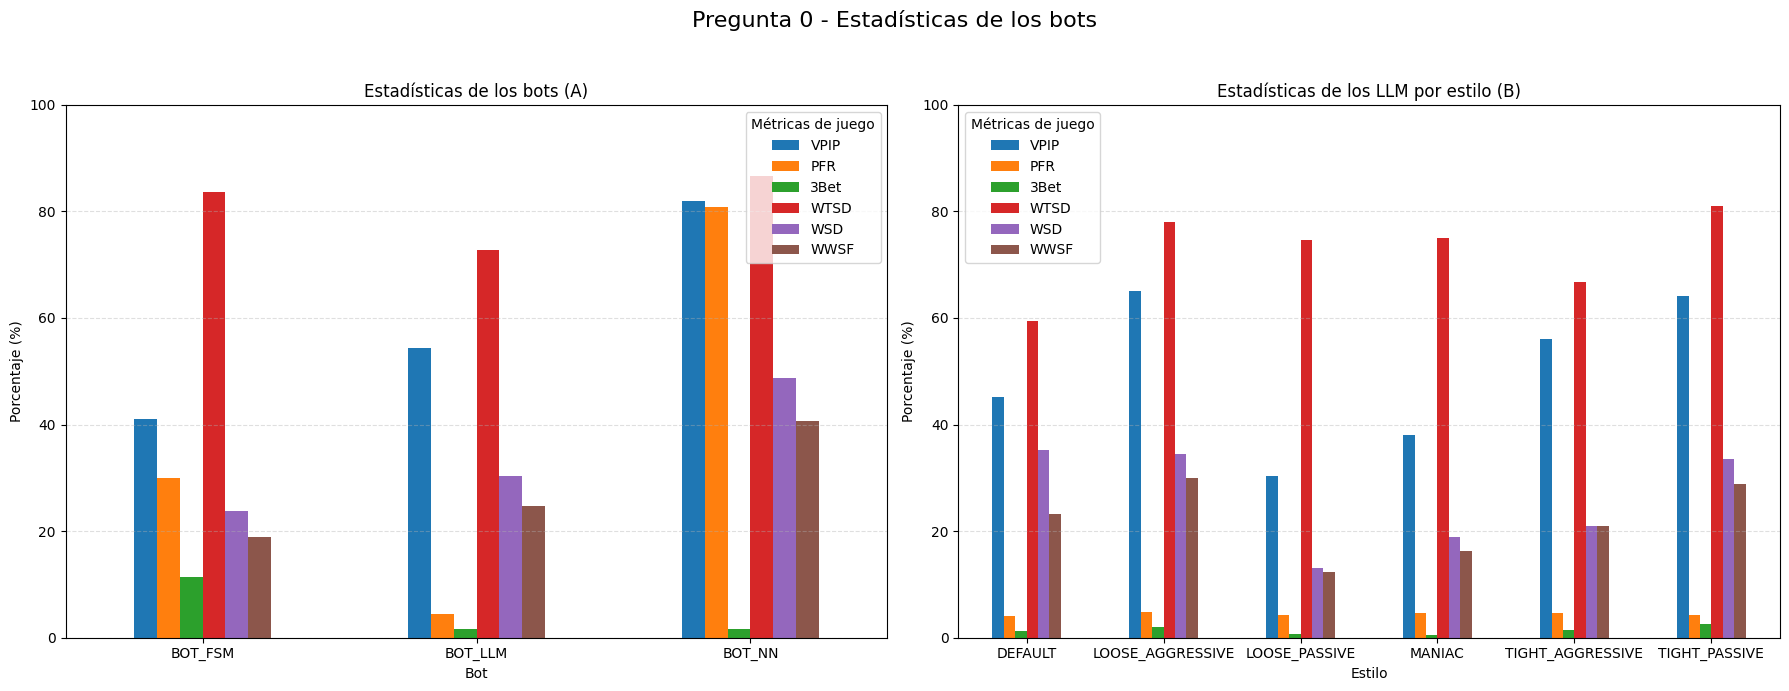

In [190]:
dist_bots_completa()
dist_llm_style()
dist_completa_pregunta_0()

## Pregunta 1 - ¿Qué bot tiene mejores resultados?
- Win Rate, chips, manos hasta ganar, supervivencia y consistencia
- Comparar LLM, wRed Neuronal y FSM
- Dentro de los LLM, comparar también los distintos estilos
- Gráficas: Barras + BoxPlot

In [191]:
### WINRATE POR TIPO DE BOT ###
def winrate_bots():
    
    win_rate = (
        all_bot_data
        .groupby('Type')['Hand result']
        .apply(lambda x: (x == 'WON').mean() * 100)
        .sort_values(ascending=False)
    )

    # Gráfico
    plt.figure(figsize=(10, 6))
    plt.bar(win_rate.index, win_rate.values)

    plt.xlabel('Tipo de bot')
    plt.ylabel('Win Rate (%)')
    plt.title('Win Rate por tipo de bot (A)')
    plt.ylim(0, 100)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_1_win_rate_por_bot.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

### CHIPS POR TIPO DE BOT
def chips_pregunta_1():

    datos_chips = all_bot_data.copy()

    datos_chips['Net chips'] = (
        datos_chips['Final stack']
        - datos_chips['Initial stack']
    )

    chips = (
        datos_chips
        .groupby('Type')['Net chips']
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        chips.index,
        chips.values
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Chips netas medias'
    )

    plt.title(
        'Chips por tipo de bot (C)'
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_chips_por_bot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### MANOS HASTA GANAR
def manos_ganar_pregunta_1():


    victorias = all_bot_data[
        all_bot_data['Hand result'] == 'WON'
    ]

    manos = (
        victorias
        .groupby('Type')['Hand']
        .mean()
        .sort_values()
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        manos.index,
        manos.values
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Número medio de mano'
    )

    plt.title(
        'Manos hasta ganar por tipo de bot (E)'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_manos_hasta_ganar.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### SUPERVIVENCIA
def supervivencia_pregunta_1():

    supervivencia = (
        all_bot_data
        .groupby('Type')['Hand']
        .max()
        .sort_values(ascending=False)
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        supervivencia.index,
        supervivencia.values
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Número de manos'
    )

    plt.title(
        'Supervivencia por tipo de bot (F)'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_supervivencia.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


### WINRATE DE LLMS POR ESTILO ###
def winrate_llm_style():

    # Winrate de LLMs por estilo
    llm_data = all_bot_data[all_bot_data['Type'] == 'BOT_LLM']
    win_rate = (
        llm_data.groupby('Style')['Hand result']
        .apply(lambda x: (x == 'WON').mean() * 100)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(win_rate.index, win_rate.values)

    plt.xlabel('Style')
    plt.ylabel('Win Rate (%)')
    plt.title('Win Rate de los LLM por estilo (B)')
    plt.ylim(0, 100)

    # Mostrar porcentaje encima de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_1_win_rate_llm_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

### CHIPS DE LLMS POR ESTILO
def chips_llm_style():

    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ].copy()

    llm_data['Net chips'] = (
        llm_data['Final stack']
        - llm_data['Initial stack']
    )

    chips = (
        llm_data
        .groupby('Style')['Net chips']
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        chips.index,
        chips.values
    )

    plt.xlabel(
        'Style'
    )

    plt.ylabel(
        'Chips netas medias'
    )

    plt.title(
        'Chips de los LLM por estilo (D)'
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_chips_llm_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### MANOS HASTA GANAR - LLM POR ESTILO
def manos_ganar_llm_style():

    victorias = all_bot_data[
        (all_bot_data['Type'] == 'BOT_LLM')
        &
        (all_bot_data['Hand result'] == 'WON')
    ]

    manos = (
        victorias
        .groupby('Style')['Hand']
        .mean()
        .sort_values()
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        manos.index,
        manos.values
    )

    plt.xlabel(
        'Style'
    )

    plt.ylabel(
        'Número medio de mano'
    )

    plt.title(
        'Manos hasta ganar de los LLM por estilo (G)'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_manos_hasta_ganar_llm_style.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### SUPERVIVENCIA - LLM POR ESTILO
def supervivencia_llm_style():

    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ]

    supervivencia = (
        llm_data
        .groupby('Style')['Hand']
        .max()
        .sort_values(ascending=False)
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.bar(
        supervivencia.index,
        supervivencia.values
    )

    plt.xlabel(
        'Style'
    )

    plt.ylabel(
        'Número de manos'
    )

    plt.title(
        'Supervivencia de los LLM por estilo (H)'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_supervivencia_llm_style.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



In [192]:
### ============================================================
### TODAS LAS GRÁFICAS DE LA PREGUNTA 1 JUNTAS
### ============================================================

def completa_pregunta_1():

    # ========================================================
    # DATOS
    # ========================================================

    # --------------------------------------------------------
    # Win Rate por tipo
    # --------------------------------------------------------

    win_rate_tipo = (
        all_bot_data
        .groupby('Type')['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
        .sort_values(ascending=False)
    )


    # --------------------------------------------------------
    # Win Rate LLM por estilo
    # --------------------------------------------------------

    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ].copy()

    win_rate_style = (
        llm_data
        .groupby('Style')['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
    )


    # --------------------------------------------------------
    # Chips
    # --------------------------------------------------------

    all_bot_data_temp = all_bot_data.copy()

    all_bot_data_temp['Net chips'] = (
        all_bot_data_temp['Final stack']
        - all_bot_data_temp['Initial stack']
    )

    chips_tipo = (
        all_bot_data_temp
        .groupby('Type')['Net chips']
        .mean()
        .sort_values(ascending=False)
    )


    # --------------------------------------------------------
    # Manos hasta ganar
    # --------------------------------------------------------

    victorias = all_bot_data[
        all_bot_data['Hand result'] == 'WON'
    ]

    manos_tipo = (
        victorias
        .groupby('Type')['Hand']
        .mean()
        .sort_values()
    )


    # --------------------------------------------------------
    # Supervivencia
    # --------------------------------------------------------

    supervivencia = (
        all_bot_data
        .groupby('Type')['Hand']
        .max()
        .sort_values(ascending=False)
    )


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(16, 16)
    )


    # ========================================================
    # 1 - WIN RATE POR TIPO
    # ========================================================

    axes[0, 0].bar(
        win_rate_tipo.index,
        win_rate_tipo.values
    )

    axes[0, 0].set_title(
        'Win Rate por tipo de bot'
    )

    axes[0, 0].set_ylabel(
        'Win Rate (%)'
    )

    axes[0, 0].set_ylim(
        0,
        100
    )

    axes[0, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 2 - WIN RATE LLM POR ESTILO
    # ========================================================

    bars = axes[0, 1].bar(
        win_rate_style.index,
        win_rate_style.values
    )

    axes[0, 1].set_title(
        'Win Rate de los LLM por estilo'
    )

    axes[0, 1].set_ylabel(
        'Win Rate (%)'
    )

    axes[0, 1].set_ylim(
        0,
        100
    )

    for bar in bars:

        height = bar.get_height()

        axes[0, 1].text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )

    axes[0, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 3 - CHIPS
    # ========================================================

    axes[1, 0].bar(
        chips_tipo.index,
        chips_tipo.values
    )

    axes[1, 0].set_title(
        'Chips por tipo de bot'
    )

    axes[1, 0].set_ylabel(
        'Chips netas medias'
    )

    axes[1, 0].axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )

    axes[1, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 4 - MANOS HASTA GANAR
    # ========================================================

    axes[1, 1].bar(
        manos_tipo.index,
        manos_tipo.values
    )

    axes[1, 1].set_title(
        'Manos hasta ganar'
    )

    axes[1, 1].set_ylabel(
        'Número medio de mano'
    )

    axes[1, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 5 - SUPERVIVENCIA
    # ========================================================

    axes[2, 0].bar(
        supervivencia.index,
        supervivencia.values
    )

    axes[2, 0].set_title(
        'Supervivencia'
    )

    axes[2, 0].set_ylabel(
        'Número de manos'
    )

    axes[2, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # OCULTAR ESPACIO SOBRANTE
    # ========================================================

    axes[2, 1].axis(
        'off'
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 1 - ¿Qué bot tiene mejores resultados?',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_1_completa.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

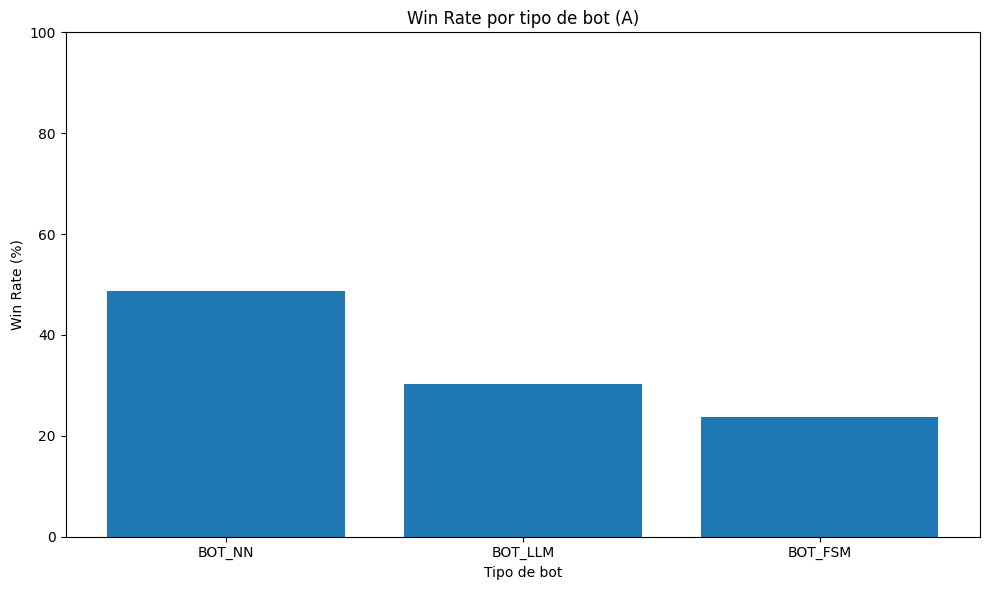

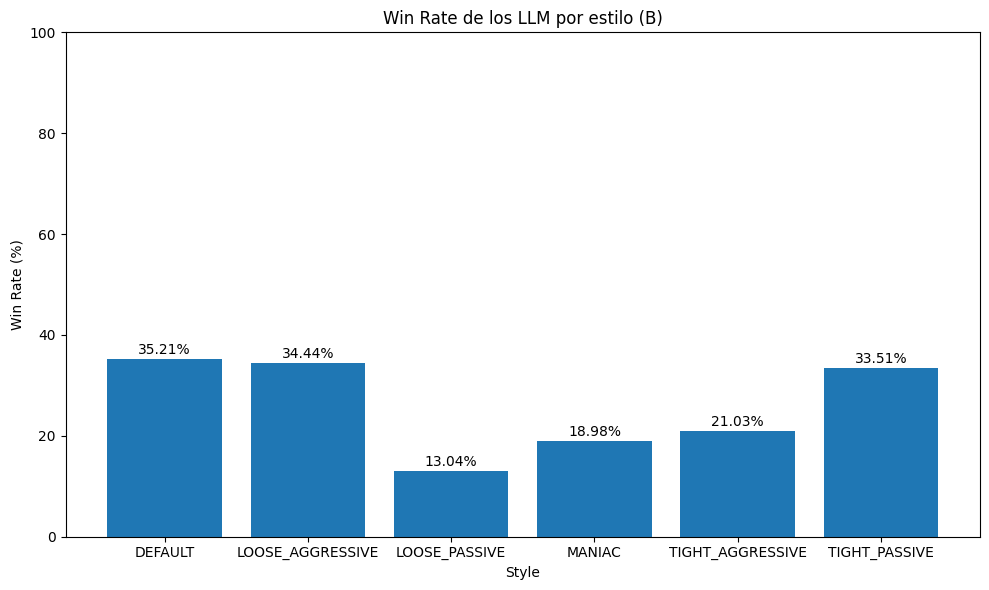

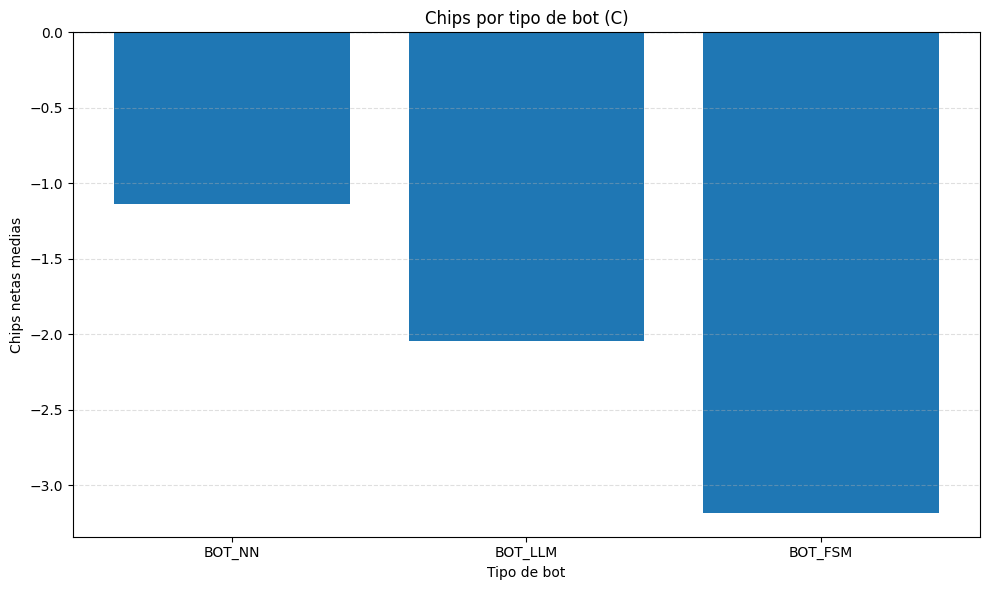

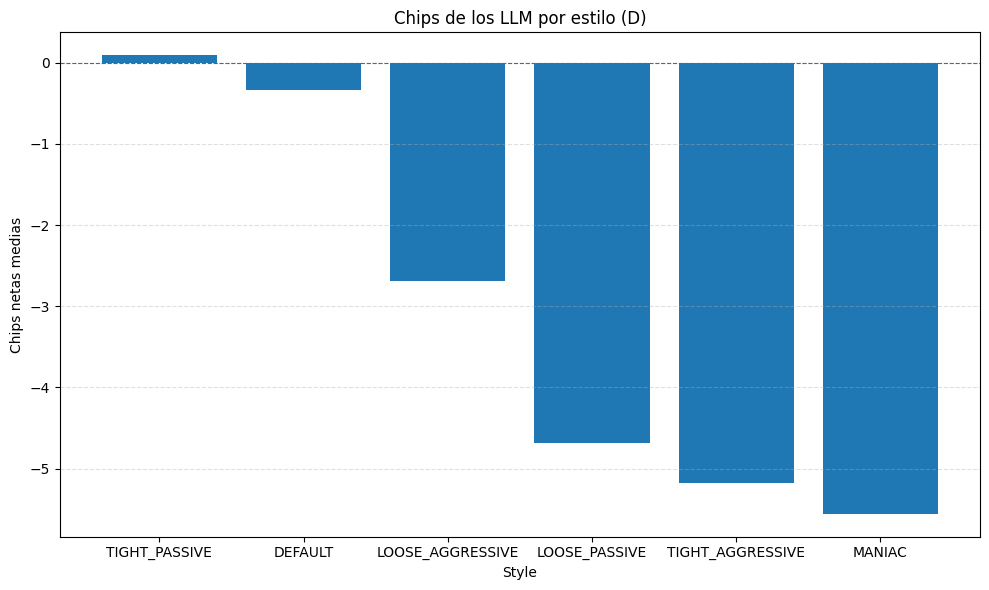

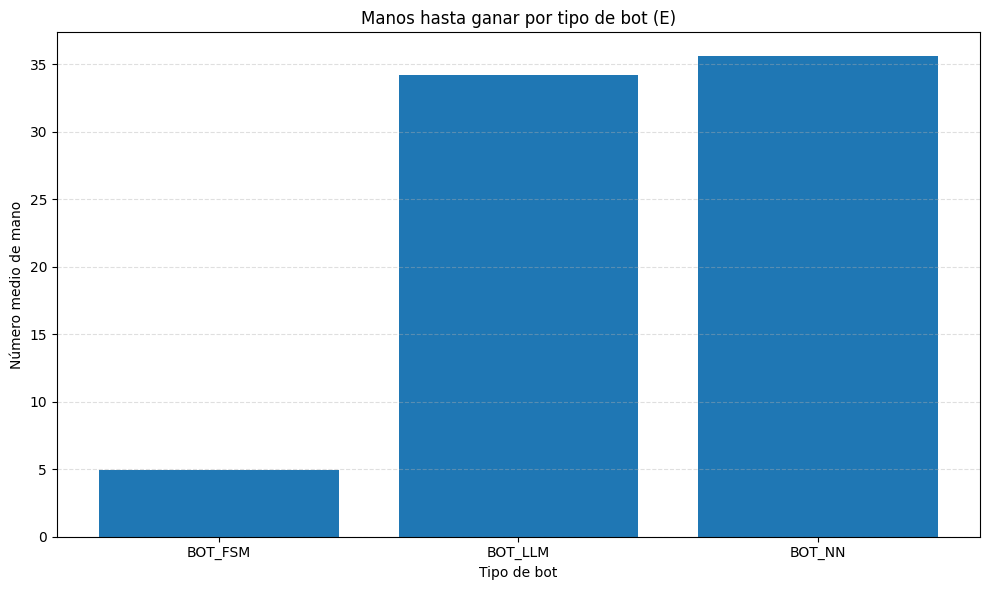

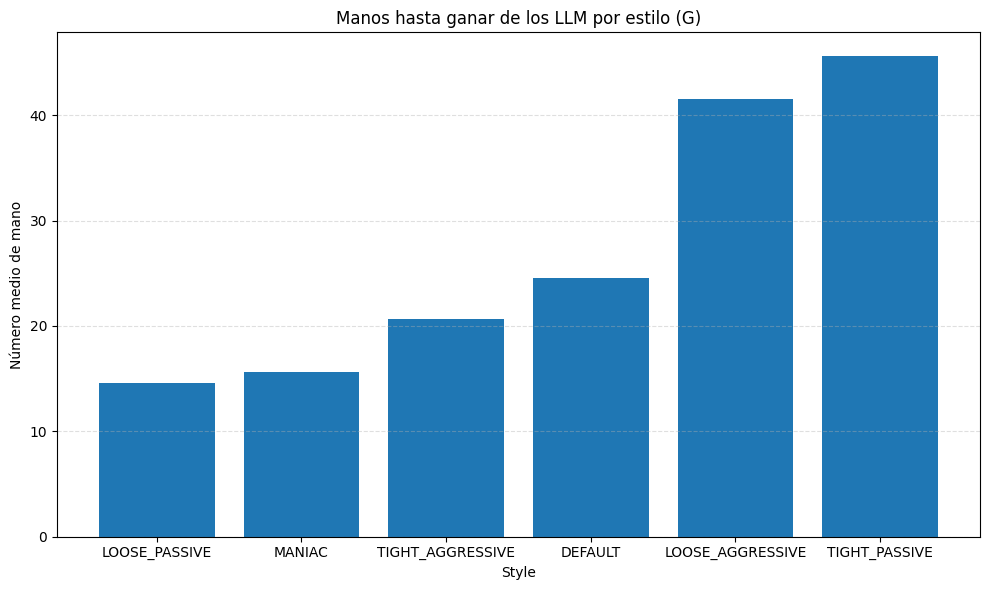

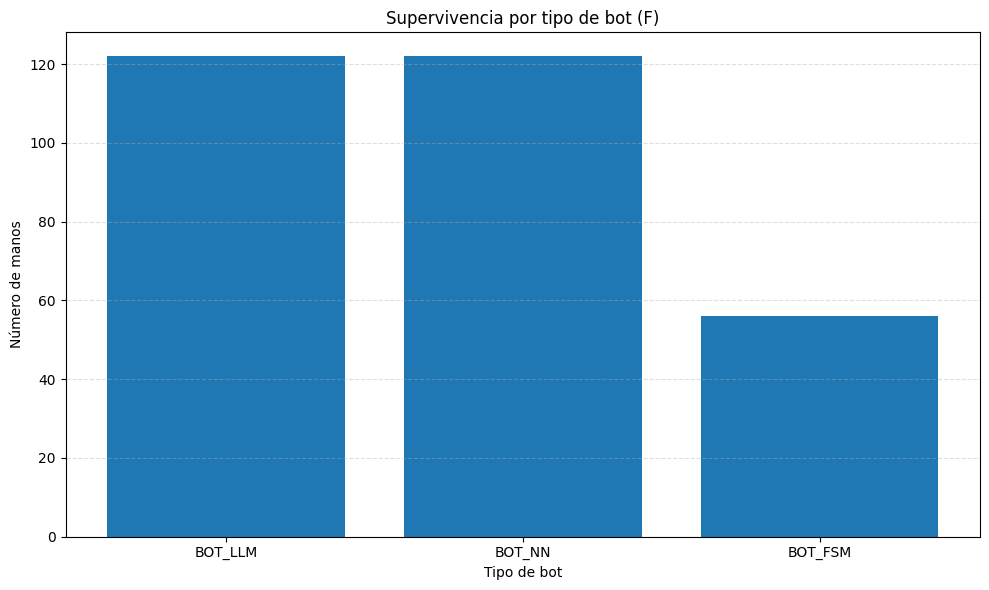

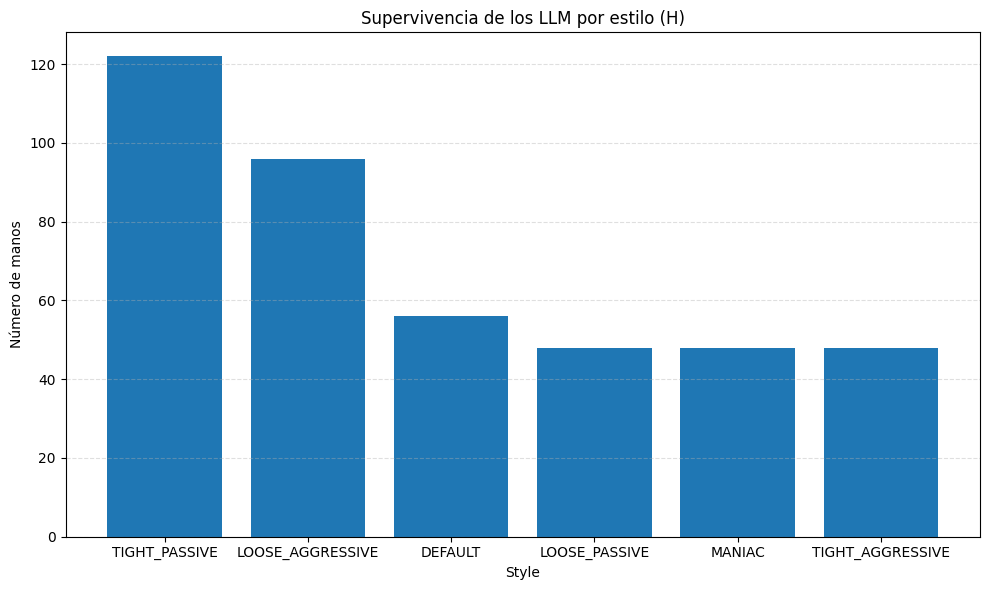

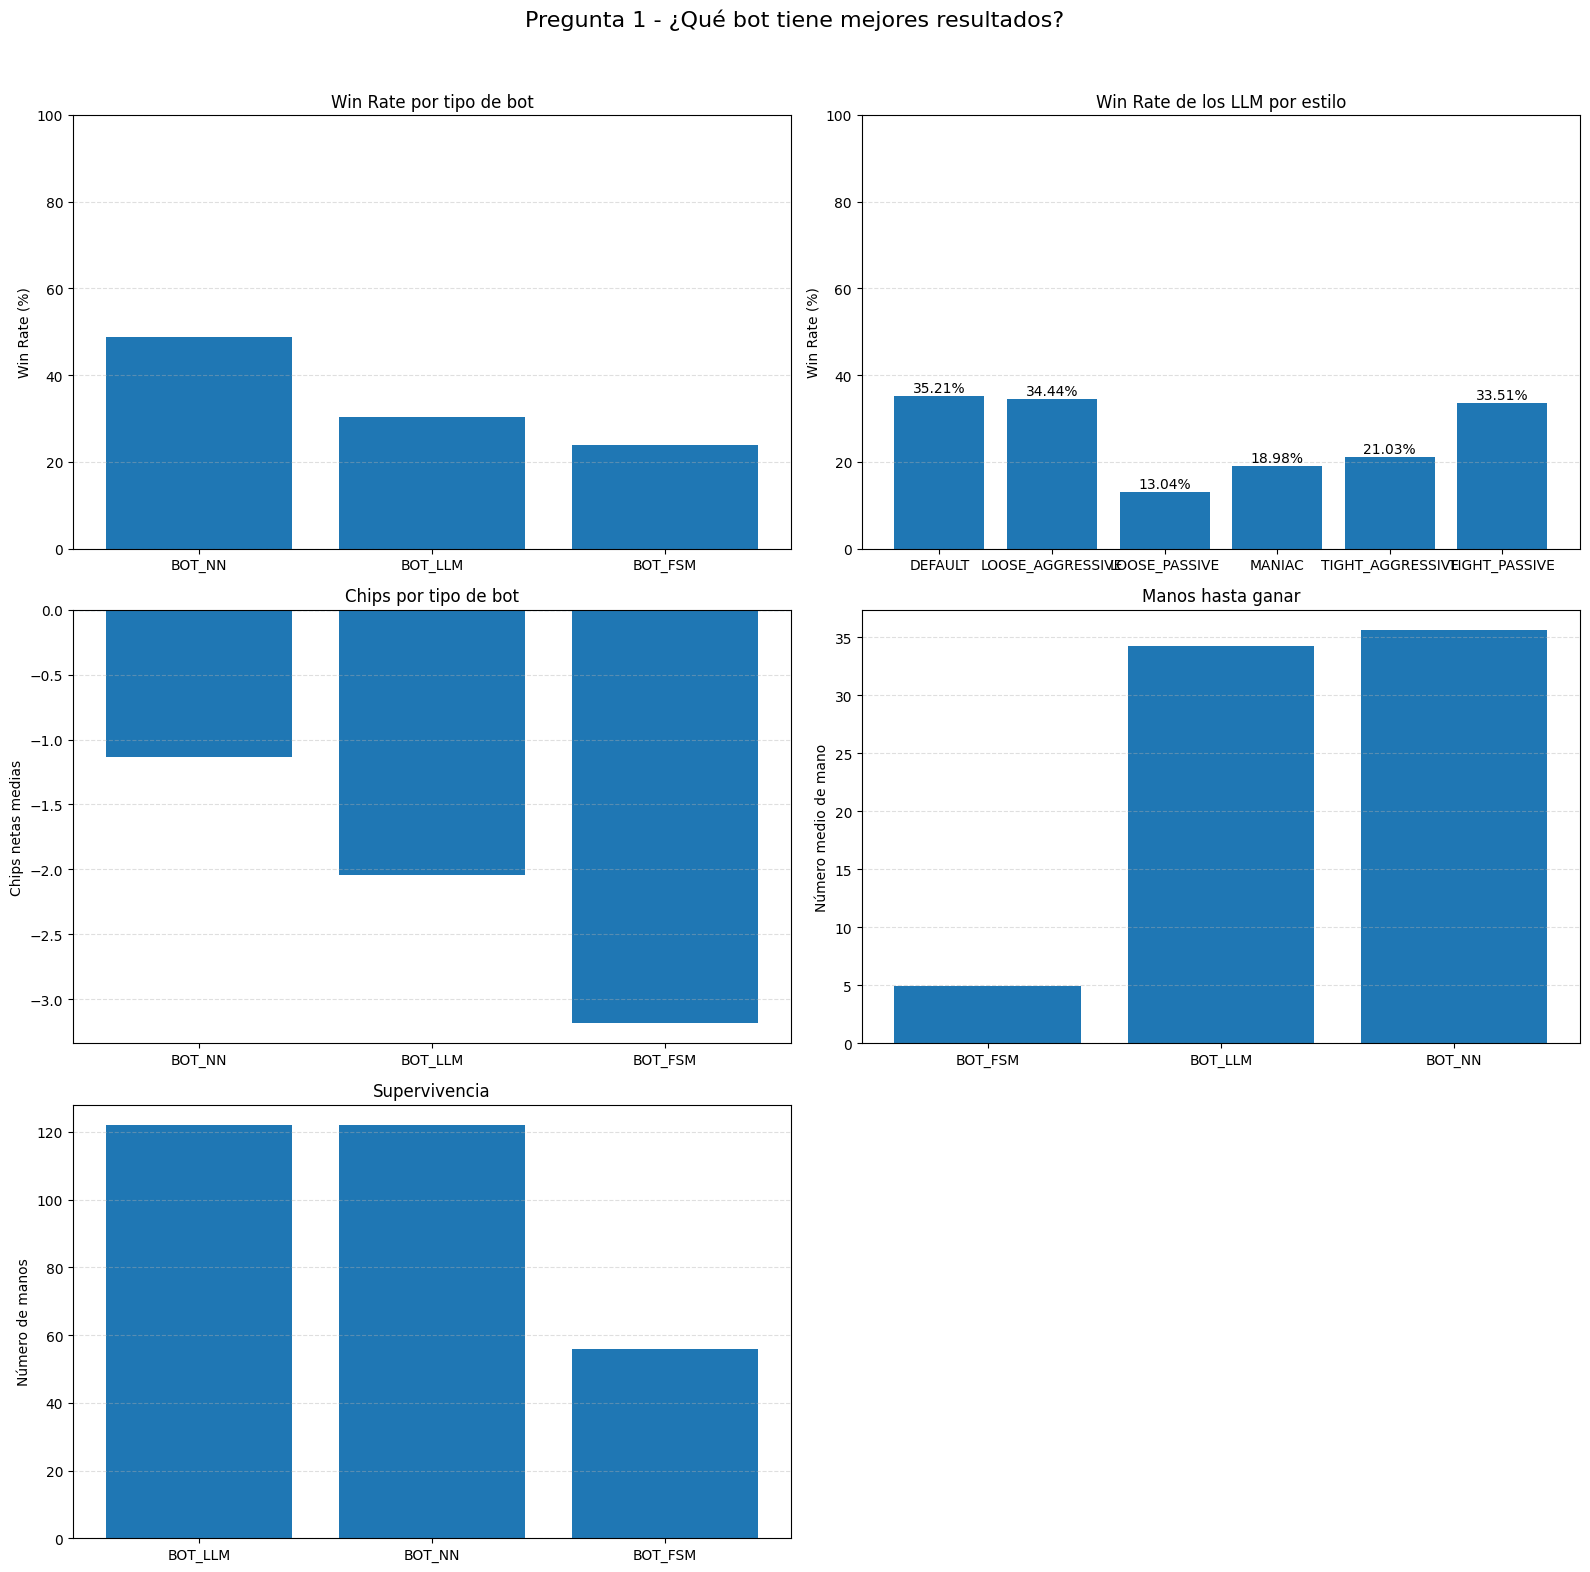

In [193]:
winrate_bots()
winrate_llm_style()

chips_pregunta_1()
chips_llm_style()

manos_ganar_pregunta_1()
manos_ganar_llm_style()

supervivencia_pregunta_1()
supervivencia_llm_style()

completa_pregunta_1()

## Pregunta 2 - ¿La agresividad mejora los resultados?
- Nº de All-ins, % ganados/perdidos, calle del All-in y equity al hacer All-in , que bot elimina mas jugadores
- Comparar LLM Local, LLM Online, Red Neuronal y FSM
- Dentro de los LLM, comparar también los distintos estilos
- Gráficas: Barras apiladas + Scatter. graficas de quesitos

In [194]:
### ============================================================
### PREGUNTA 2 - ¿LA AGRESIVIDAD MEJORA LOS RESULTADOS?
### ============================================================


# ============================================================
# 1. ALL-INS DE BOTS POR TIPO
# ============================================================
def allins_bots():

    allins = (
        all_bot_data
        .groupby('Type')['AllIns']
        .sum()
    )

    colors = plt.cm.tab10(
        range(len(allins))
    )

    plt.figure(
        figsize=(10, 6)
    )

    bars = plt.bar(
        allins.index,
        allins.values,
        color=colors
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Número de All-ins'
    )

    plt.title(
        'Número de All-ins por tipo de bot - A'
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    legend_elements = [
        Patch(
            facecolor=bar.get_facecolor(),
            label=bot_type
        )
        for bar, bot_type
        in zip(
            bars,
            allins.index
        )
    ]

    plt.legend(
        handles=legend_elements,
        title='Tipo de bot'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_4_allins_por_bot.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 2. ALL-INS DE LLMS POR ESTILO
# ============================================================
def allins_llms():

    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ]

    allins = (
        llm_data
        .groupby('Style')['AllIns']
        .sum()
    )

    colors = plt.cm.tab10(
        range(len(allins))
    )

    plt.figure(
        figsize=(10, 6)
    )

    bars = plt.bar(
        allins.index,
        allins.values,
        color=colors
    )

    plt.xlabel(
        'Style'
    )

    plt.ylabel(
        'Número de All-ins'
    )

    plt.title(
        'Número de All-ins de los LLM por estilo - B'
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    legend_elements = [
        Patch(
            facecolor=bar.get_facecolor(),
            label=style
        )
        for bar, style
        in zip(
            bars,
            allins.index
        )
    ]

    plt.legend(
        handles=legend_elements,
        title='Style'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_allins_llm_por_style.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 3. ALL-INS GANADOS / PERDIDOS
# ============================================================
def resultado_allins_pregunta_2():

    datos_allin = all_bot_data[
        all_bot_data['AllIns'] > 0
    ].copy()

    datos_allin['Resultado All-in'] = np.where(
        datos_allin['Hand result'] == 'WON',
        'Ganado',
        'Perdido'
    )

    resultados = pd.crosstab(
        datos_allin['Type'],
        datos_allin['Resultado All-in']
    )

    for columna in [
        'Ganado',
        'Perdido'
    ]:

        if columna not in resultados.columns:
            resultados[columna] = 0

    resultados = resultados[
        [
            'Ganado',
            'Perdido'
        ]
    ]

    resultados.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Número de All-ins'
    )

    plt.title(
        'All-ins ganados y perdidos por tipo de bot - C'
    )

    plt.xticks(
        rotation=0
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_resultado_allins.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 4. CALLE DEL ALL-IN
# ============================================================
def calle_allin_pregunta_2():

    equity_columnas = [
        'Preflop equity',
        'Flop equity',
        'Turn equity',
        'River equity'
    ]

    datos_allin = all_bot_data[
        all_bot_data['AllIns'] > 0
    ].copy()

    datos_calle = datos_allin.copy()

    datos_calle[
        equity_columnas
    ] = (
        datos_calle[
            equity_columnas
        ].replace(
            0,
            np.nan
        )
    )

    datos_calle['Calle All-in'] = pd.Series(
        np.nan,
        index=datos_calle.index,
        dtype='object'
    )

    datos_calle.loc[
        datos_calle['Preflop equity'].notna(),
        'Calle All-in'
    ] = 'Preflop'

    datos_calle.loc[
        datos_calle['Flop equity'].notna(),
        'Calle All-in'
    ] = 'Flop'

    datos_calle.loc[
        datos_calle['Turn equity'].notna(),
        'Calle All-in'
    ] = 'Turn'

    datos_calle.loc[
        datos_calle['River equity'].notna(),
        'Calle All-in'
    ] = 'River'

    tabla_calles = pd.crosstab(
        datos_calle['Type'],
        datos_calle['Calle All-in']
    )

    tabla_calles = tabla_calles.reindex(
        columns=[
            'Preflop',
            'Flop',
            'Turn',
            'River'
        ],
        fill_value=0
    )

    tabla_calles.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Número de All-ins'
    )

    plt.title(
        'Calle en la que se produce el All-in - D'
    )

    plt.xticks(
        rotation=0
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_calle_allin.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 5. EQUITY DEL ALL-IN
# ============================================================
def equity_allin_pregunta_2():

    equity_columnas = [
        'Preflop equity',
        'Flop equity',
        'Turn equity',
        'River equity'
    ]

    datos_allin = all_bot_data[
        all_bot_data['AllIns'] > 0
    ].copy()

    datos_equity = datos_allin.copy()

    datos_equity[
        equity_columnas
    ] = (
        datos_equity[
            equity_columnas
        ].replace(
            0,
            np.nan
        )
    )

    datos_equity['Equity All-in'] = (
        datos_equity[
            equity_columnas
        ]
        .ffill(axis=1)
        .iloc[:, -1]
    )

    equity = (
        datos_equity
        .groupby('Type')['Equity All-in']
        .mean()
        .dropna()
    )

    plt.figure(
        figsize=(10, 6)
    )

    bars = plt.bar(
        equity.index,
        equity.values
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Equity media (%)'
    )

    plt.title(
        'Equity en el momento del All-in - E'
    )

    plt.ylim(
        0,
        100
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_equity_allin.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 6. ELIMINACIONES
# ============================================================
def eliminaciones_pregunta_2():

    eliminaciones = (
        all_bot_data[
            all_bot_data['Final stack'] == 0
        ]
        .groupby('Type')
        .size()
    )

    plt.figure(
        figsize=(10, 6)
    )

    bars = plt.bar(
        eliminaciones.index,
        eliminaciones.values
    )

    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Jugadores eliminados'
    )

    plt.title(
        'Jugadores eliminados por tipo de bot - F'
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_eliminaciones.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 7. ALL-INS LLM GANADOS / PERDIDOS
# ============================================================
def resultado_allins_llm_style_pregunta_2():

    datos_llm = all_bot_data[
        (all_bot_data['Type'] == 'BOT_LLM')
        &
        (all_bot_data['AllIns'] > 0)
    ].copy()

    datos_llm['Resultado All-in'] = np.where(
        datos_llm['Hand result'] == 'WON',
        'Ganado',
        'Perdido'
    )

    resultados_llm = pd.crosstab(
        datos_llm['Style'],
        datos_llm['Resultado All-in']
    )

    for columna in [
        'Ganado',
        'Perdido'
    ]:

        if columna not in resultados_llm.columns:
            resultados_llm[columna] = 0

    resultados_llm = resultados_llm[
        [
            'Ganado',
            'Perdido'
        ]
    ]

    resultados_llm.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    plt.xlabel(
        'Style'
    )

    plt.ylabel(
        'Número de All-ins'
    )

    plt.title(
        'All-ins ganados y perdidos de los LLM - G'
    )

    plt.xticks(
        rotation=0
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_resultado_allins_llm_style.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 8. EQUITY LLM POR ESTILO
# ============================================================
def equity_allin_llm_style_pregunta_2():

    equity_columnas = [
        'Preflop equity',
        'Flop equity',
        'Turn equity',
        'River equity'
    ]

    datos_llm = all_bot_data[
        (all_bot_data['Type'] == 'BOT_LLM')
        &
        (all_bot_data['AllIns'] > 0)
    ].copy()

    datos_llm[
        equity_columnas
    ] = (
        datos_llm[
            equity_columnas
        ].replace(
            0,
            np.nan
        )
    )

    datos_llm['Equity All-in'] = (
        datos_llm[
            equity_columnas
        ]
        .ffill(axis=1)
        .iloc[:, -1]
    )

    equity_style = (
        datos_llm
        .groupby('Style')['Equity All-in']
        .mean()
        .dropna()
    )

    plt.figure(
        figsize=(10, 6)
    )

    bars = plt.bar(
        equity_style.index,
        equity_style.values
    )

    plt.xlabel(
        'Style'
    )

    plt.ylabel(
        'Equity media (%)'
    )

    plt.title(
        'Equity en el All-in de los LLM - H'
    )

    plt.ylim(
        0,
        100
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_2_equity_allin_llm_style.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()



# ============================================================
# 9. TODAS LAS GRÁFICAS JUNTAS
# ============================================================
def completa_pregunta_2():

    archivos = [

        "pregunta_4_allins_por_bot.png",

        "pregunta_2_allins_llm_por_style.png",

        "pregunta_2_resultado_allins.png",

        "pregunta_2_calle_allin.png",

        "pregunta_2_equity_allin.png",

        "pregunta_2_eliminaciones.png",

        "pregunta_2_resultado_allins_llm_style.png",

        "pregunta_2_equity_allin_llm_style.png"

    ]


    imagenes = []

    for archivo in archivos:

        ruta = OUTPUT_DIR / archivo

        if ruta.exists():

            imagenes.append(
                Image.open(ruta).convert('RGB')
            )

        else:

            print(
                f"AVISO: no se encontró {archivo}"
            )


    if not imagenes:

        print(
            "No se encontraron las gráficas."
        )

        return


    # --------------------------------------------------------
    # 2 COLUMNAS × 4 FILAS
    # --------------------------------------------------------

    ancho = max(
        imagen.width
        for imagen in imagenes
    )

    alto = max(
        imagen.height
        for imagen in imagenes
    )


    margen = 30

    imagen_final = Image.new(
        'RGB',
        (
            ancho * 2 + margen * 3,
            alto * 4 + margen * 5
        ),
        'white'
    )


    for i, imagen in enumerate(imagenes):

        fila = i // 2
        columna = i % 2

        x = (
            margen
            + columna * (ancho + margen)
        )

        y = (
            margen
            + fila * (alto + margen)
        )

        imagen_final.paste(
            imagen,
            (
                x,
                y
            )
        )


    imagen_final.save(
        OUTPUT_DIR
        / "pregunta_2_completa.png"
    )


    display(
        imagen_final
    )


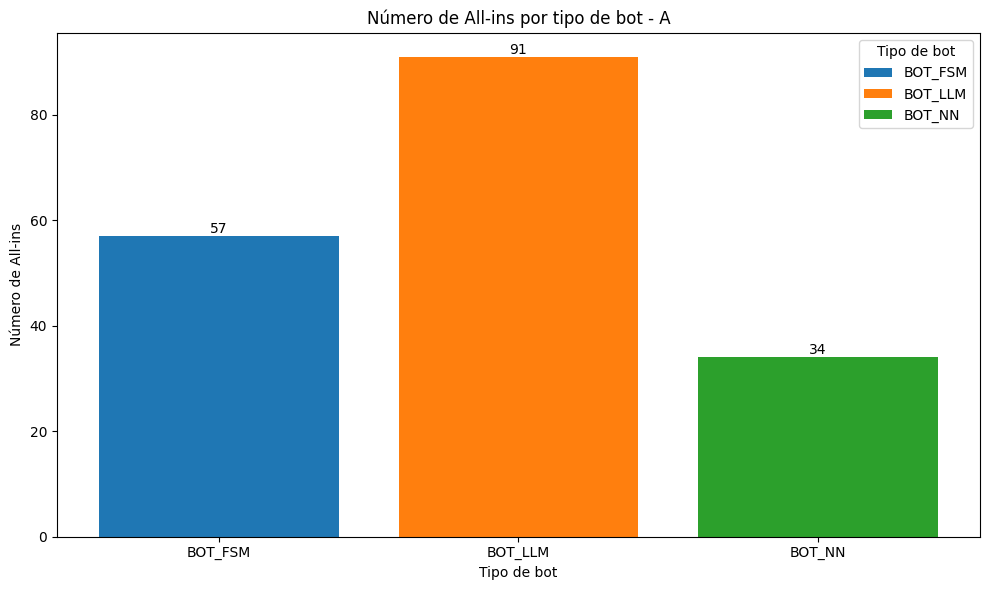

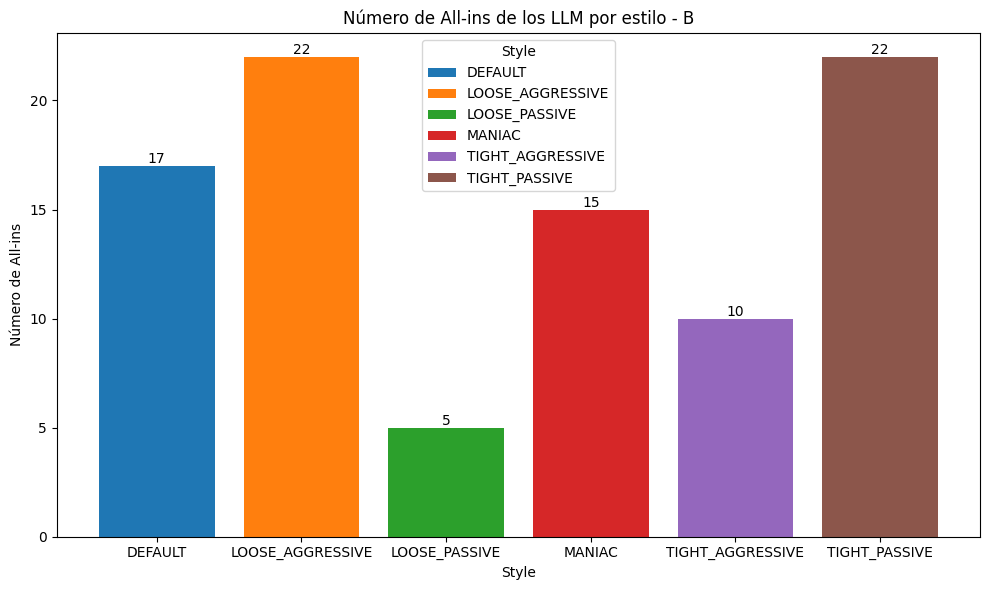

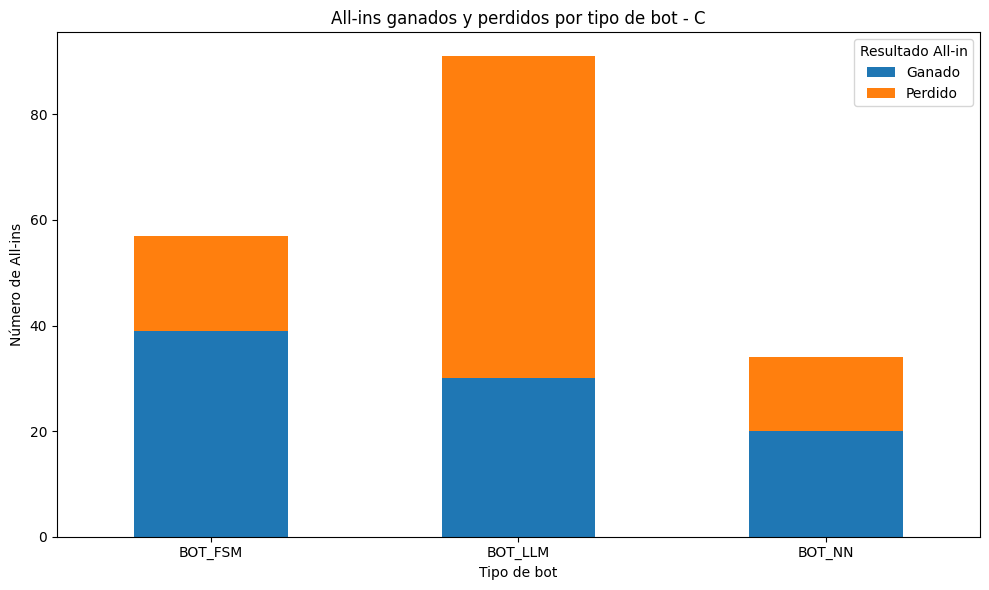

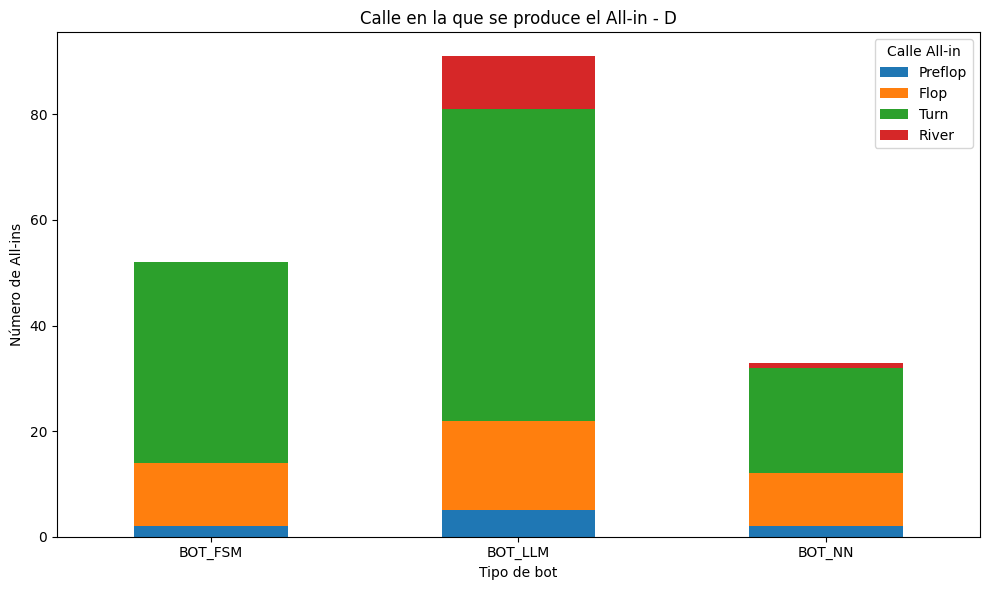

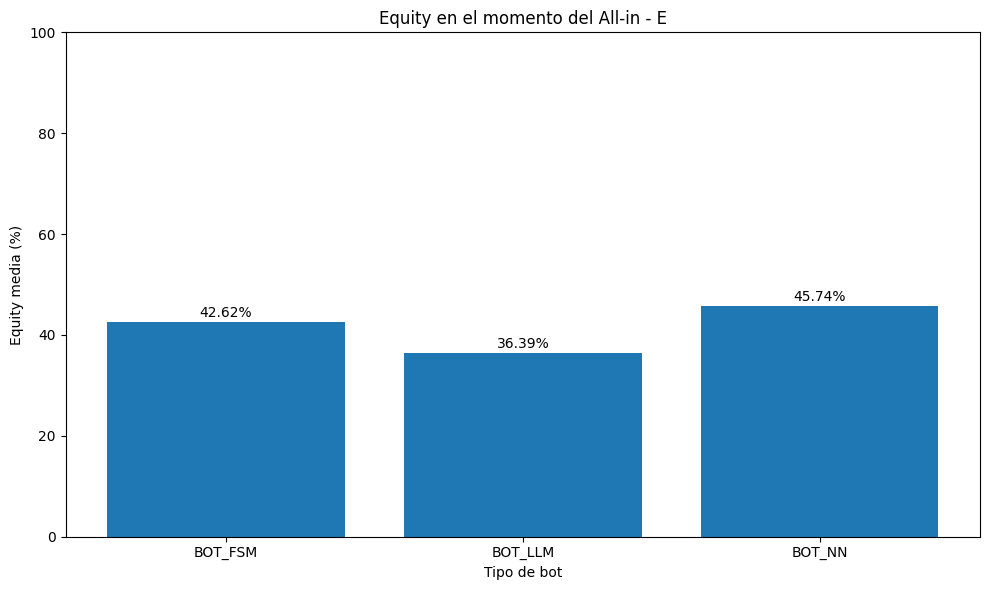

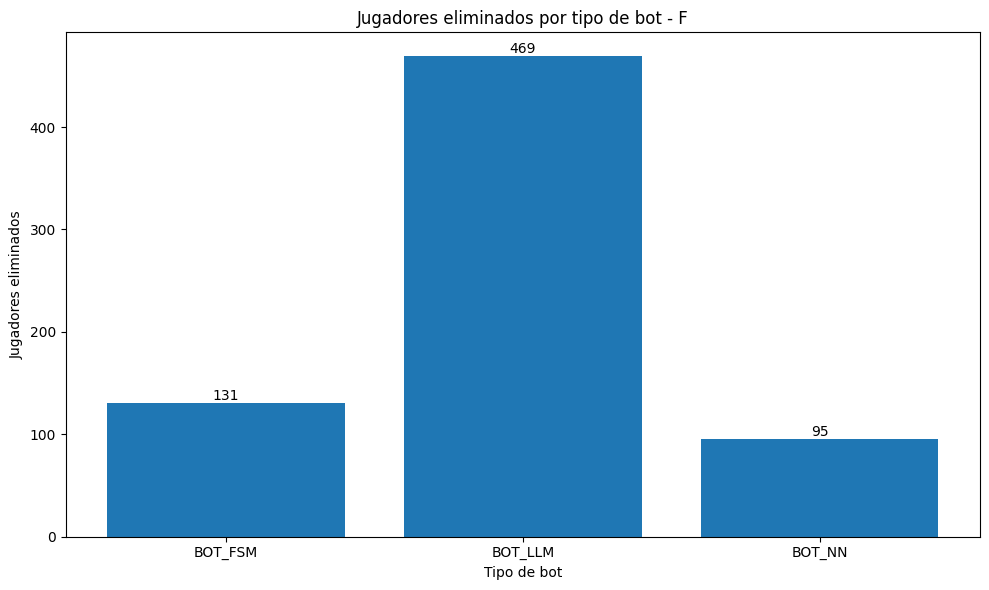

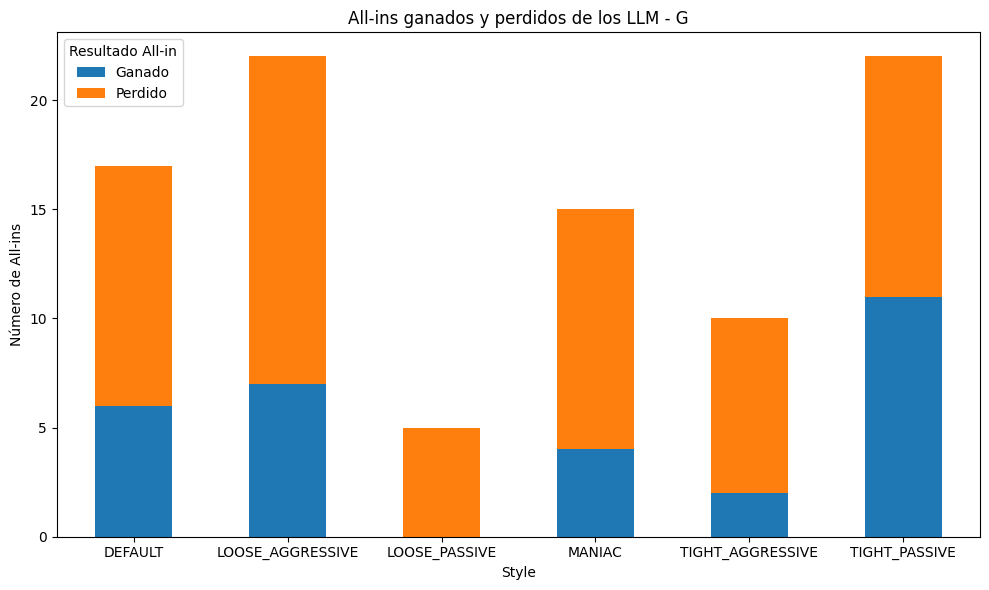

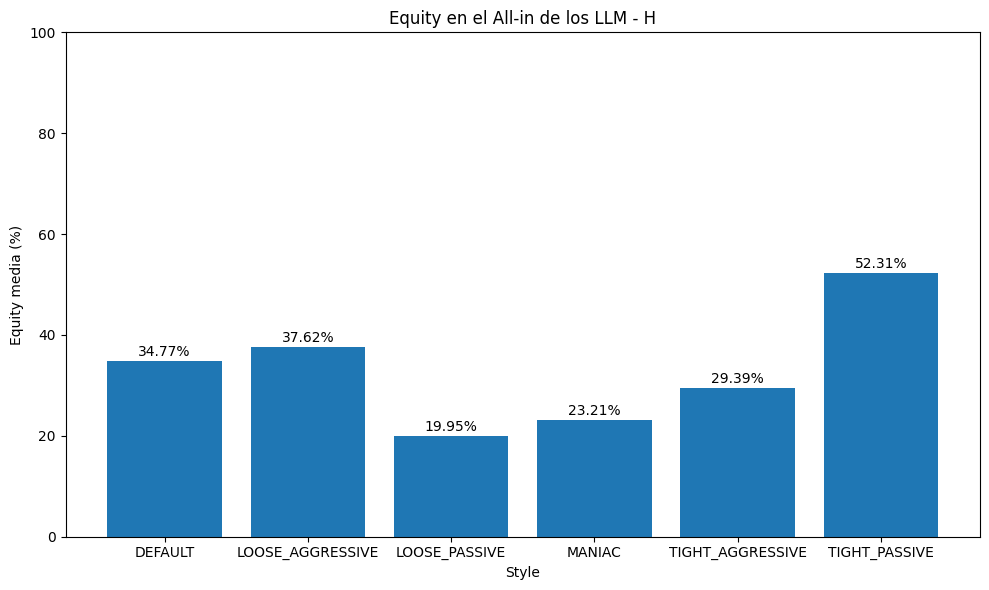

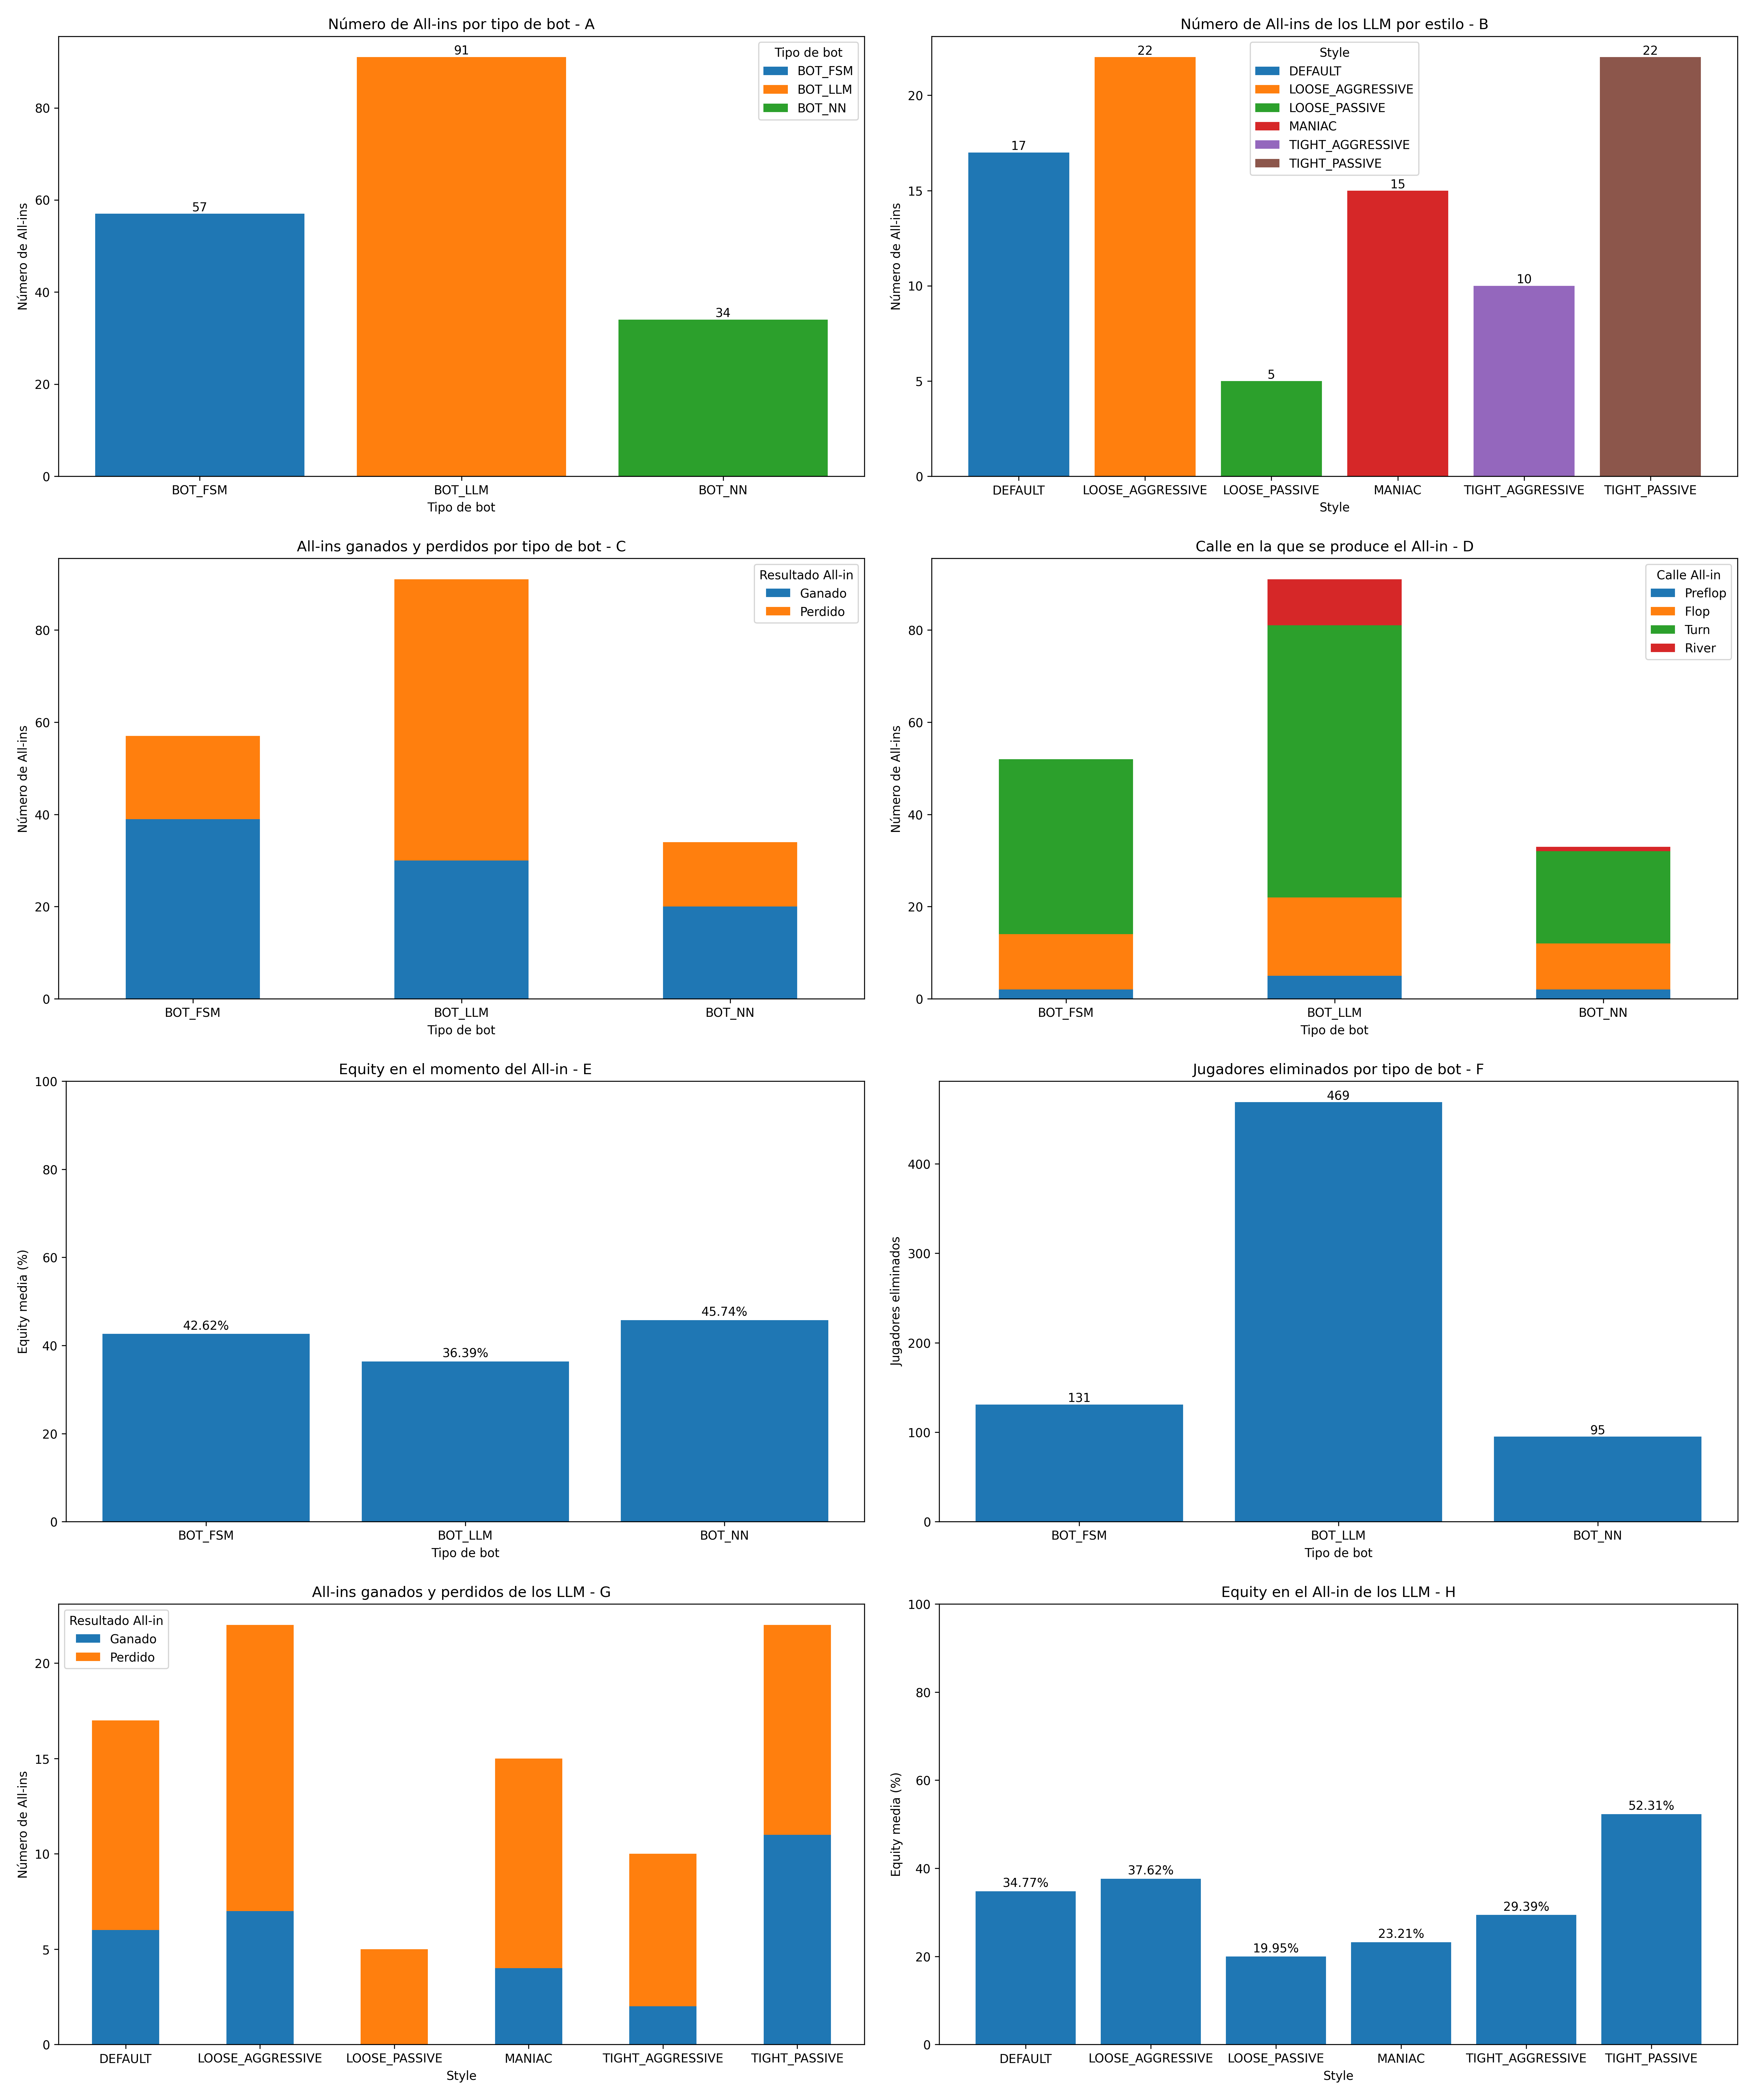

In [195]:
allins_bots()
allins_llms()

resultado_allins_pregunta_2()
calle_allin_pregunta_2()
equity_allin_pregunta_2()
eliminaciones_pregunta_2()

resultado_allins_llm_style_pregunta_2()
equity_allin_llm_style_pregunta_2()

completa_pregunta_2()

## Pregunta 3 - ¿Qué decisiones tienen mayor impacto en el resultado?
- Acción realizada
- Equity
- Comparar Fold, Call, Raise y All-in
- Gráficas: Barras comparativas + Grafica de quesitos

In [196]:
### DECISIONES DE BOTS POR TIPO ###
def decisiones_bots():

    # Número de decisiones por tipo de bot
    decisiones = all_bot_data.groupby('Type')[
        ['Folds', 'Calls', 'Raises', 'AllIns']
    ].sum()

    # Colores
    colors = plt.cm.tab10(range(len(decisiones.columns)))

    # Gráfico
    ax = decisiones.plot(
        kind='bar',
        figsize=(12, 6),
        color=colors
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('Número de decisiones')
    plt.title('Decisiones realizadas por tipo de bot (A)')
    plt.xticks(rotation=0)

    plt.legend(
        title='Acción',
        labels=['Fold', 'Call', 'Raise', 'All-in']
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_3_decisiones_por_bot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### DECISIONES DE LLMS POR ESTILO ###
def decisiones_llms():

    # Solo LLM
    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ]

    # Número de decisiones por estilo
    decisiones = llm_data.groupby('Style')[
        ['Folds', 'Calls', 'Raises', 'AllIns']
    ].sum()

    # Colores
    colors = plt.cm.tab10(range(len(decisiones.columns)))

    # Gráfico
    ax = decisiones.plot(
        kind='bar',
        figsize=(12, 6),
        color=colors
    )

    plt.xlabel('Style')
    plt.ylabel('Número de decisiones')
    plt.title('Decisiones realizadas por los LLM según el estilo (B)')
    plt.xticks(rotation=20)

    plt.legend(
        title='Acción',
        labels=['Fold', 'Call', 'Raise', 'All-in']
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_3_decisiones_llm_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



### DISTRIBUCIÓN DE DECISIONES DE BOTS POR TIPO ###
def quesitos_decisiones_bots():

    decisiones = all_bot_data.groupby('Type')[
        ['Folds', 'Calls', 'Raises', 'AllIns']
    ].sum()

    nombres_acciones = [
        'Fold',
        'Call',
        'Raise',
        'All-in'
    ]

    # Gráfico
    fig, axes = plt.subplots(
        1,
        len(decisiones),
        figsize=(15, 5)
    )

    for ax, (bot_type, valores) in zip(
        axes,
        decisiones.iterrows()
    ):

        ax.pie(
            valores.values,
            labels=nombres_acciones,
            autopct='%1.1f%%',
            startangle=90
        )

        ax.set_title(bot_type)

    fig.suptitle(
        'Distribución de decisiones por tipo de bot (C)'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_3_quesitos_decisiones_por_bot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### DISTRIBUCIÓN DE DECISIONES DE LLMS POR ESTILO ###
def quesitos_decisiones_llms():

    # Solo LLM
    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ]

    decisiones = llm_data.groupby('Style')[
        ['Folds', 'Calls', 'Raises', 'AllIns']
    ].sum()

    nombres_acciones = [
        'Fold',
        'Call',
        'Raise',
        'All-in'
    ]

    # Gráfico
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )

    axes = axes.flatten()

    for ax, (style, valores) in zip(
        axes,
        decisiones.iterrows()
    ):

        ax.pie(
            valores.values,
            labels=nombres_acciones,
            autopct='%1.1f%%',
            startangle=90
        )

        ax.set_title(
            NOMBRES_ESTILOS.get(style, style)
        )

    fig.suptitle(
        'Distribución de decisiones de los LLM según el estilo (D)'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_3_quesitos_decisiones_llm_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    

In [197]:
### ============================================================
### TODAS LAS GRÁFICAS DE LA PREGUNTA 3 JUNTAS
### ============================================================

def completa_pregunta_3():

    # ========================================================
    # DATOS
    # ========================================================

    # --------------------------------------------------------
    # Decisiones por tipo de bot
    # --------------------------------------------------------

    decisiones = all_bot_data.groupby('Type')[
        ['Folds', 'Calls', 'Raises', 'AllIns']
    ].sum()


    # --------------------------------------------------------
    # Decisiones de LLM por estilo
    # --------------------------------------------------------

    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ]

    decisiones_llm = llm_data.groupby('Style')[
        ['Folds', 'Calls', 'Raises', 'AllIns']
    ].sum()


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig = plt.figure(
        figsize=(20, 16)
    )

    gs = fig.add_gridspec(
        2,
        2
    )


    # ========================================================
    # 1. DECISIONES POR TIPO DE BOT
    # ========================================================

    ax1 = fig.add_subplot(
        gs[0, 0]
    )

    colors = plt.cm.tab10(
        range(len(decisiones.columns))
    )

    decisiones.plot(
        kind='bar',
        ax=ax1,
        color=colors
    )

    ax1.set_xlabel(
        'Tipo de bot'
    )

    ax1.set_ylabel(
        'Número de decisiones'
    )

    ax1.set_title(
        'Decisiones realizadas por tipo de bot'
    )

    ax1.set_xticklabels(
        ax1.get_xticklabels(),
        rotation=0
    )

    ax1.legend(
        title='Acción',
        labels=[
            'Fold',
            'Call',
            'Raise',
            'All-in'
        ]
    )


    # ========================================================
    # 2. DECISIONES DE LLM POR ESTILO
    # ========================================================

    ax2 = fig.add_subplot(
        gs[0, 1]
    )

    colors = plt.cm.tab10(
        range(len(decisiones_llm.columns))
    )

    decisiones_llm.plot(
        kind='bar',
        ax=ax2,
        color=colors
    )

    ax2.set_xlabel(
        'Style'
    )

    ax2.set_ylabel(
        'Número de decisiones'
    )

    ax2.set_title(
        'Decisiones realizadas por los LLM según el estilo'
    )

    ax2.set_xticklabels(
        ax2.get_xticklabels(),
        rotation=20
    )

    ax2.legend(
        title='Acción',
        labels=[
            'Fold',
            'Call',
            'Raise',
            'All-in'
        ]
    )


    # ========================================================
    # 3. QUESITOS POR TIPO DE BOT
    # ========================================================

    ax3 = fig.add_subplot(
        gs[1, 0]
    )

    # En este espacio mostramos los datos de todos los tipos
    # de bot manteniendo la misma distribución de decisiones.

    ax3.axis(
        'off'
    )

    posiciones = [
        (0.25, 0.65),
        (0.75, 0.65),
        (0.25, 0.15),
        (0.75, 0.15)
    ]

    for posicion, (bot_type, valores) in zip(
        posiciones,
        decisiones.iterrows()
    ):

        inset = ax3.inset_axes([
            posicion[0] - 0.20,
            posicion[1] - 0.20,
            0.40,
            0.40
        ])

        inset.pie(
            valores.values,
            labels=[
                'Fold',
                'Call',
                'Raise',
                'All-in'
            ],
            autopct='%1.1f%%',
            startangle=90
        )

        inset.set_title(
            bot_type,
            fontsize=10
        )

    ax3.set_title(
        'Distribución de decisiones por tipo de bot'
    )


    # ========================================================
    # 4. QUESITOS DE LOS LLM POR ESTILO
    # ========================================================

    ax4 = fig.add_subplot(
        gs[1, 1]
    )

    ax4.axis(
        'off'
    )

    estilos = list(
        decisiones_llm.iterrows()
    )

    posiciones_llm = [
        (0.25, 0.72),
        (0.75, 0.72),
        (0.25, 0.25),
        (0.75, 0.25)
    ]

    for posicion, (style, valores) in zip(
        posiciones_llm,
        estilos
    ):

        inset = ax4.inset_axes([
            posicion[0] - 0.20,
            posicion[1] - 0.20,
            0.40,
            0.40
        ])

        inset.pie(
            valores.values,
            labels=[
                'Fold',
                'Call',
                'Raise',
                'All-in'
            ],
            autopct='%1.1f%%',
            startangle=90
        )

        inset.set_title(
            NOMBRES_ESTILOS.get(
                style,
                style
            ),
            fontsize=10
        )

    ax4.set_title(
        'Distribución de decisiones de los LLM según el estilo'
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 3 - Análisis de las decisiones de los bots',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_3_completa.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

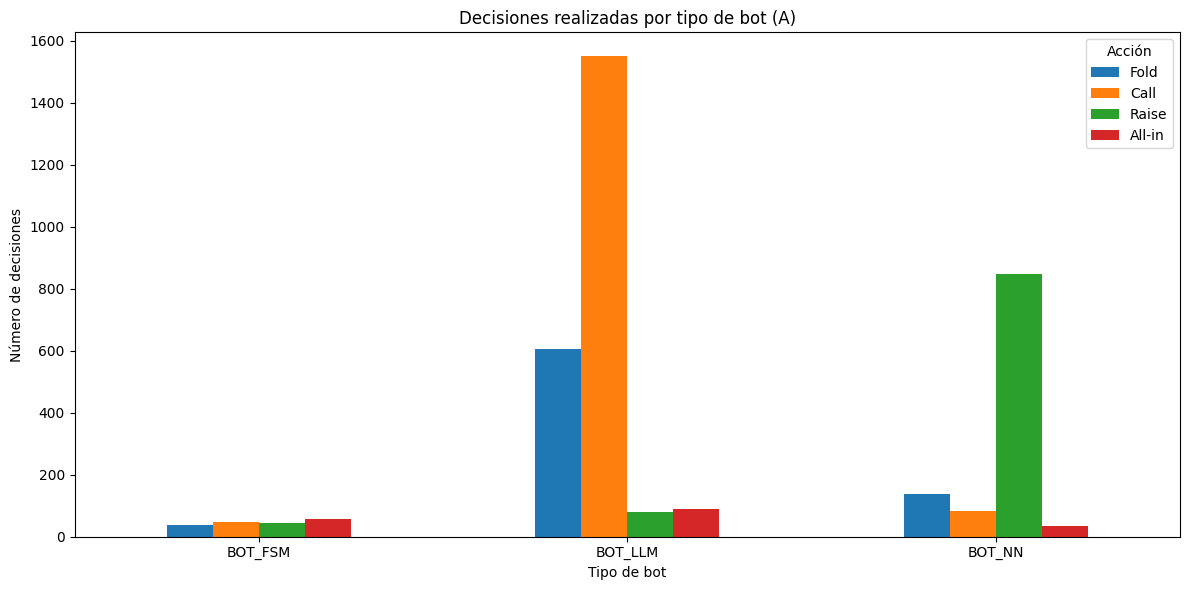

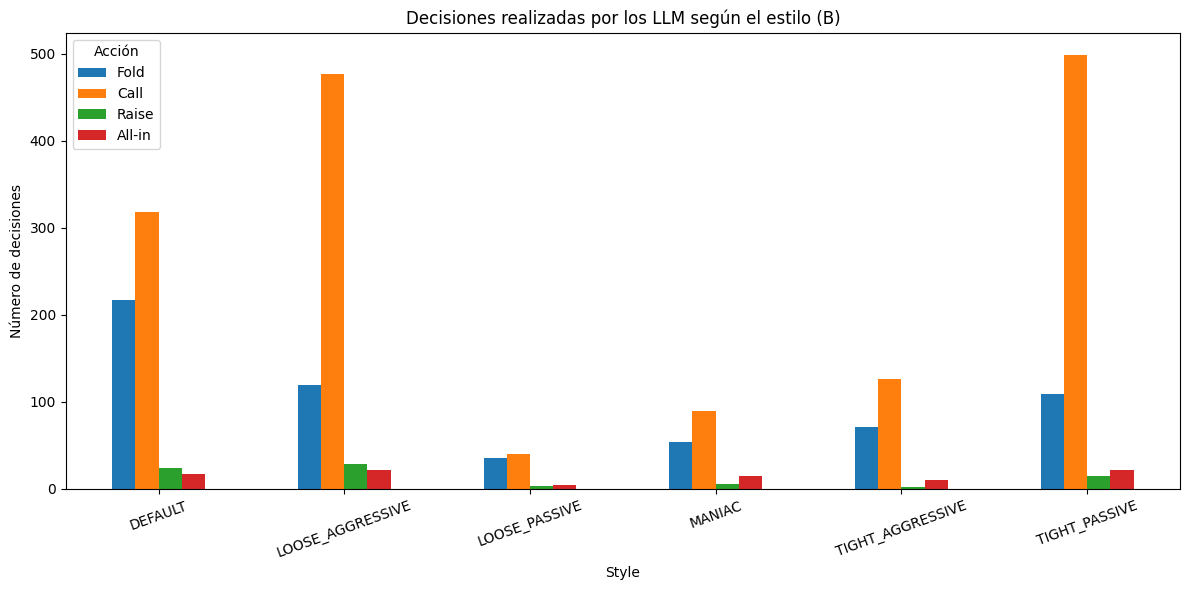

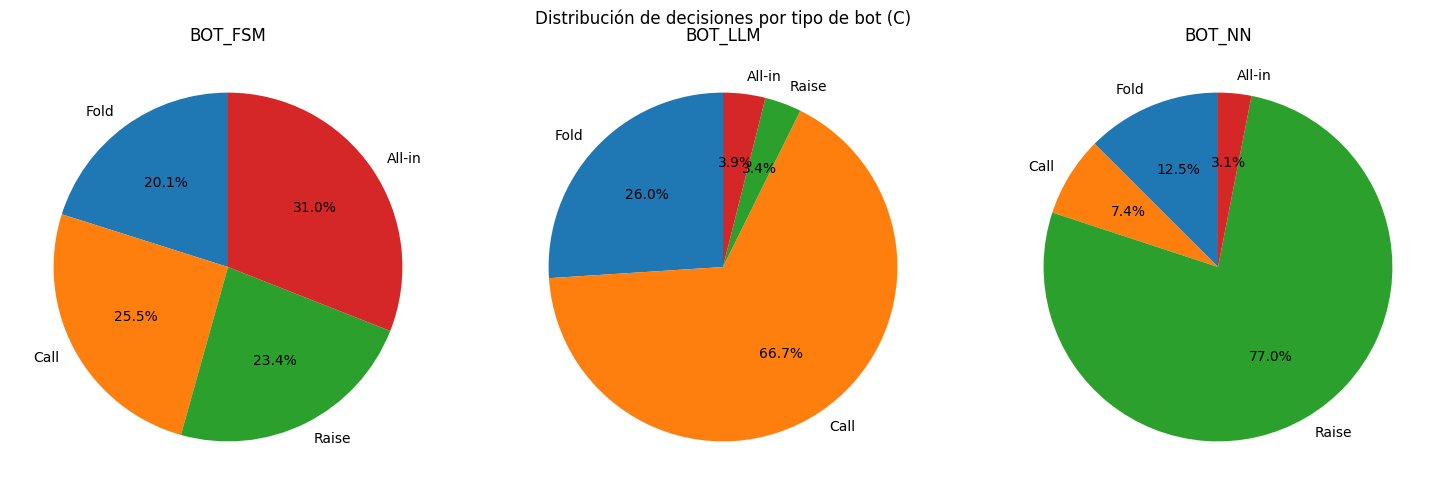

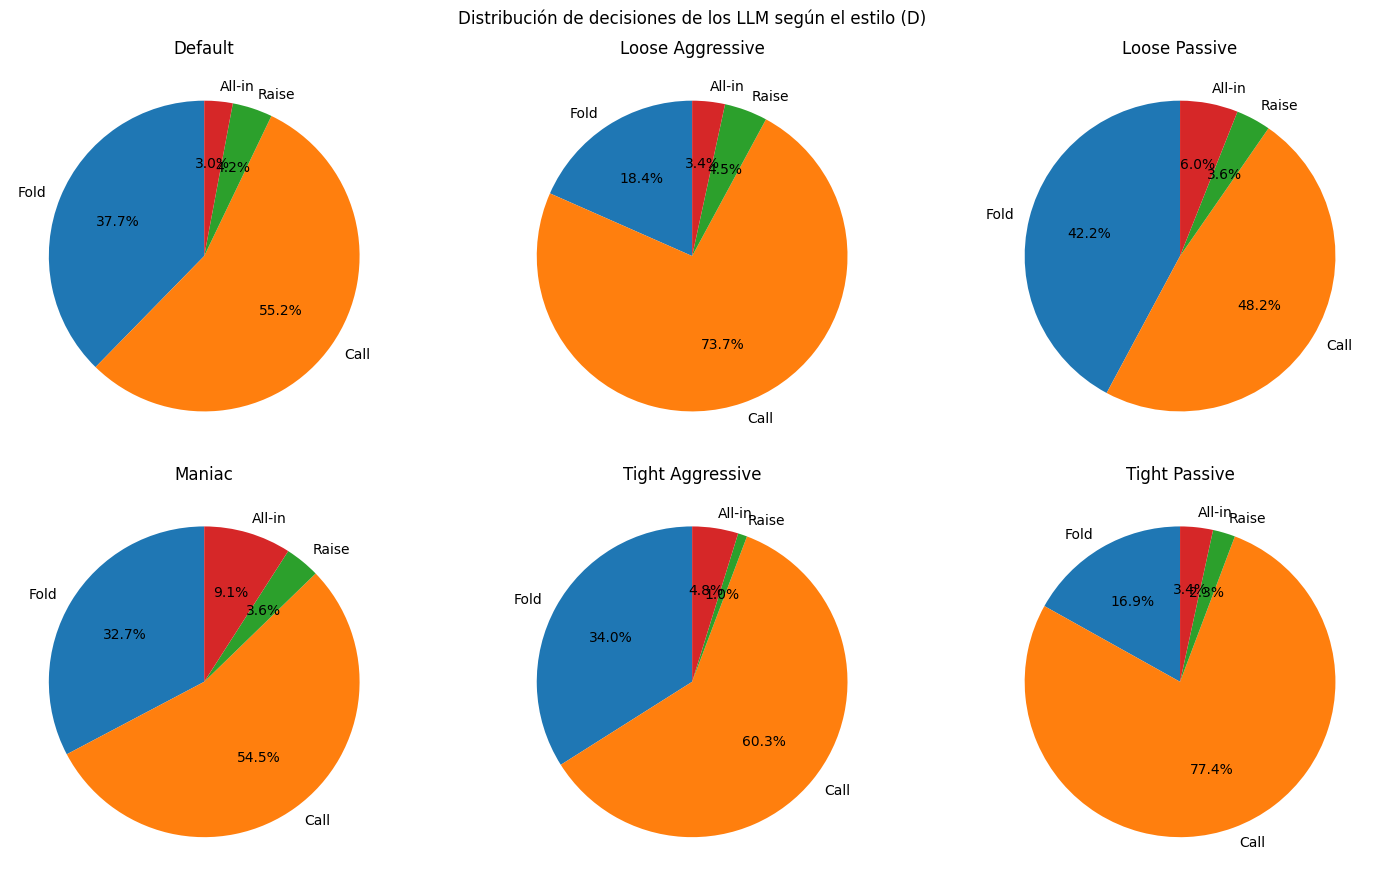

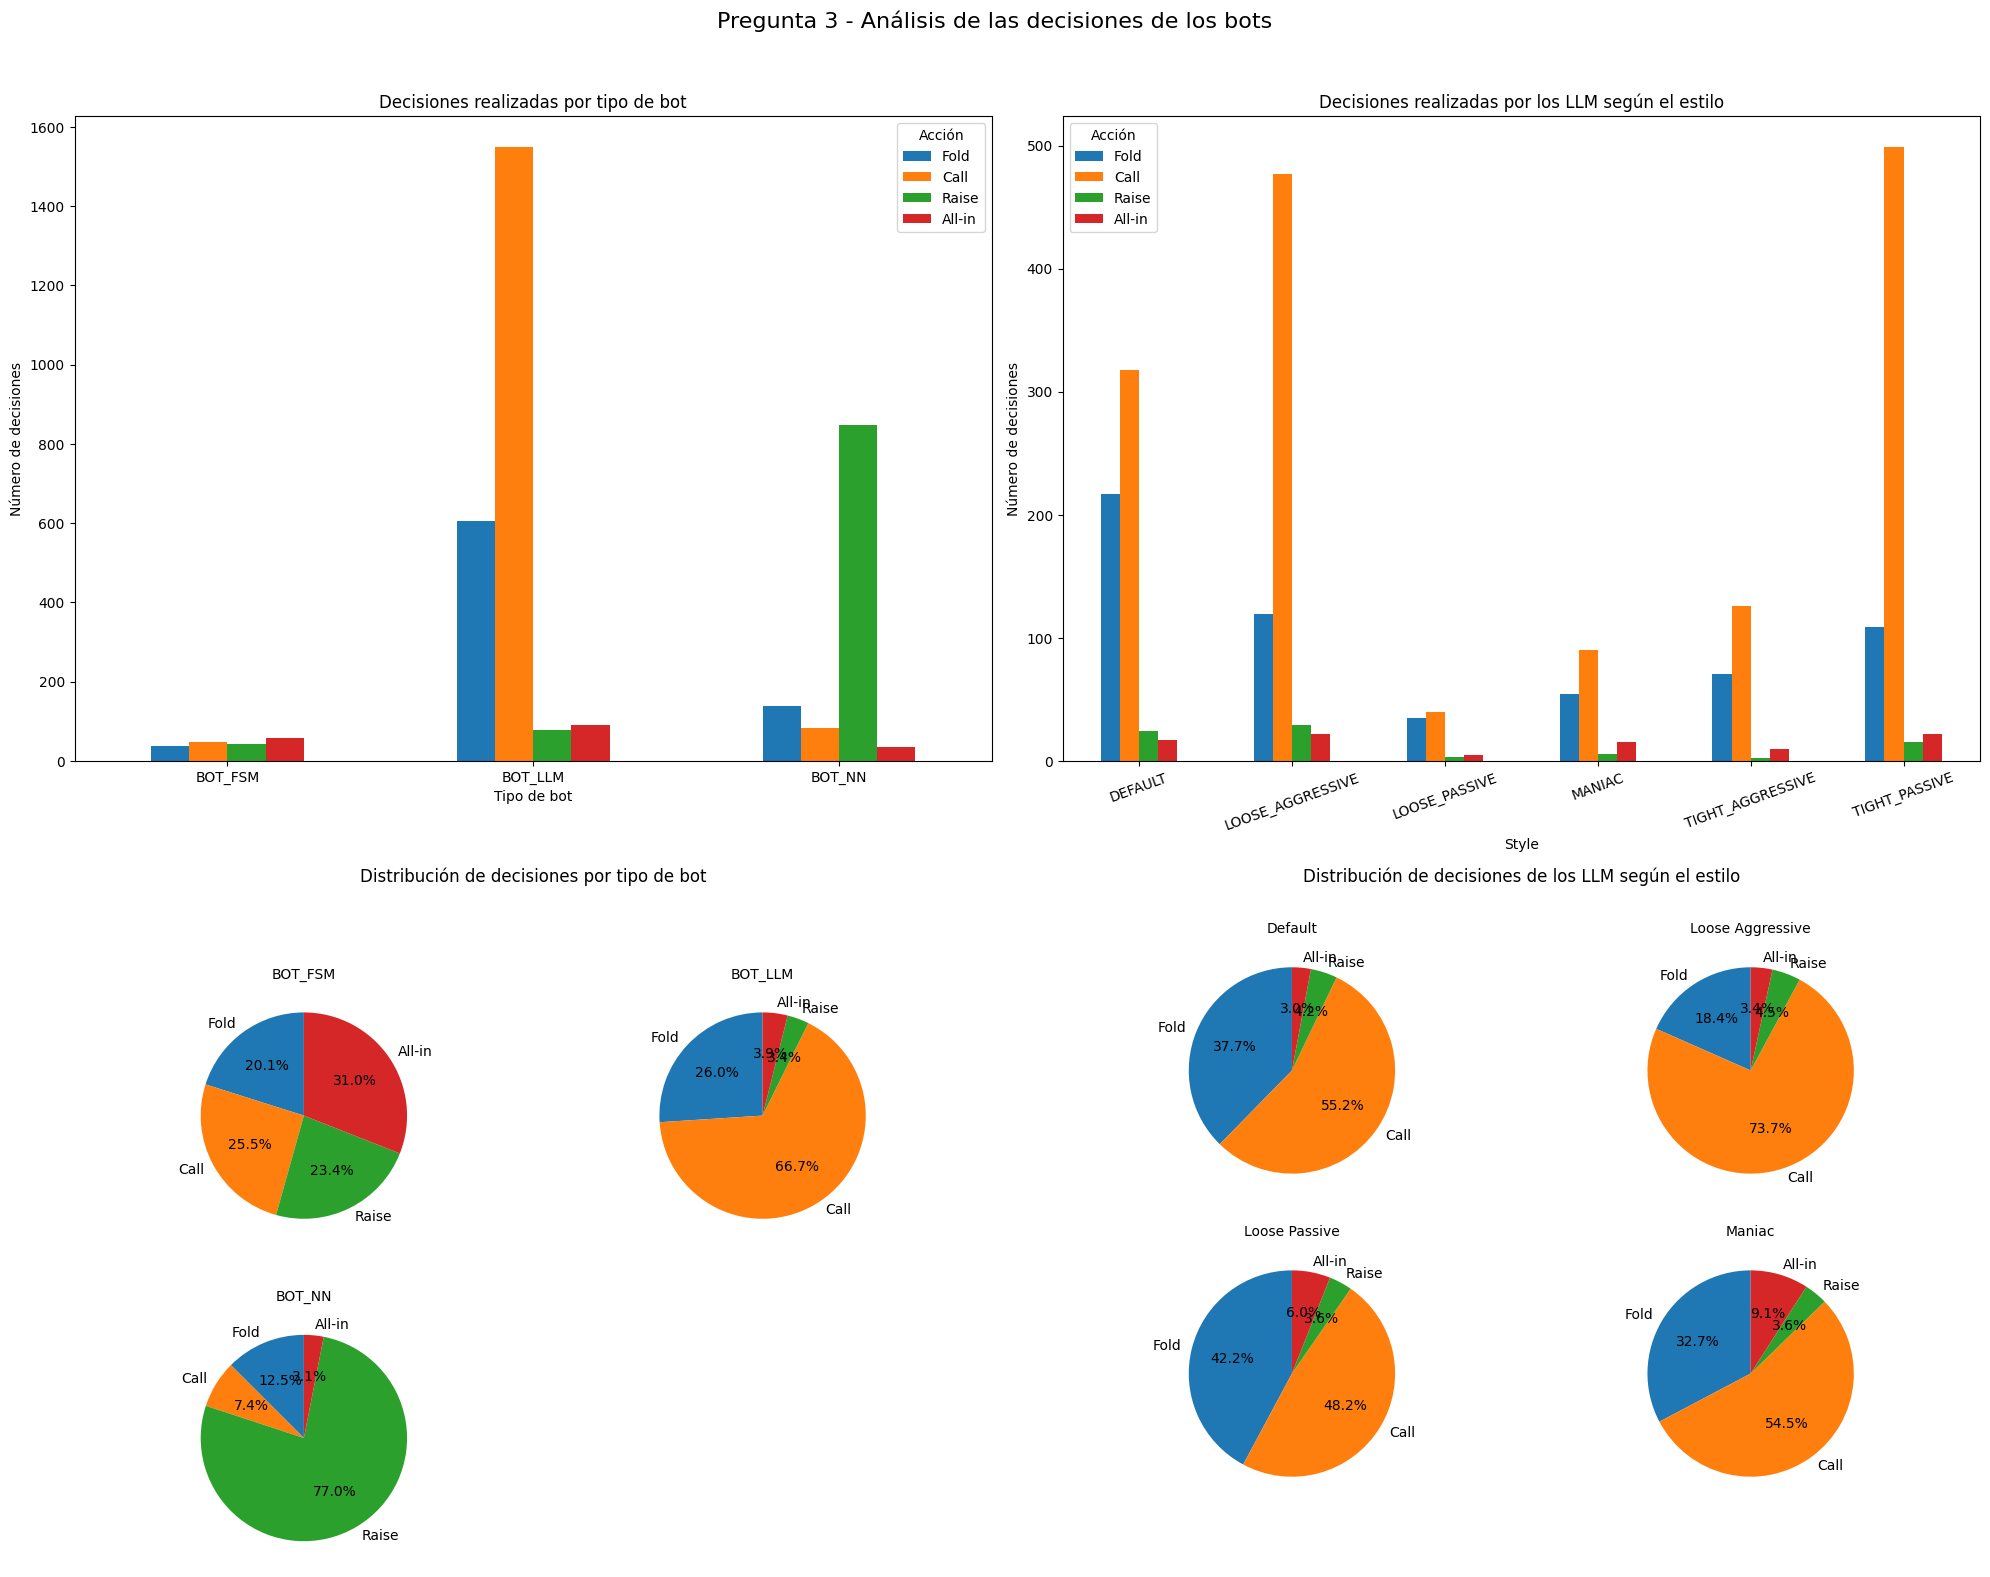

In [198]:

decisiones_bots()
decisiones_llms()
quesitos_decisiones_bots()
quesitos_decisiones_llms()

completa_pregunta_3()

## Pregunta 4 - ¿Cómo evoluciona el bot durante la partida?
- Evolución del stack.
- Win Rate por bloques de manos.
- Equity por bloques.
- Evolución de VPIP/AF.
- Tiempo como líder.
- Gráficas: Líneas + Barras graficas de columnas y lineas

In [199]:
### EVOLUCIÓN DEL STACK ###
def evolucion_stack():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # Stack medio de cada tipo de bot en cada mano
    stack = (
        all_bot_data
        .groupby(['Hand', 'Type'])['Final stack']
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    for tipo in stack['Type'].unique():

        datos_tipo = stack[
            stack['Type'] == tipo
        ]

        plt.plot(
            datos_tipo['Hand'],
            datos_tipo['Final stack'],
            label=nombres_tipos.get(tipo, tipo)
        )

    plt.xlabel('Número de mano')
    plt.ylabel('Stack medio')
    plt.title('Evolución del stack durante la partida (A)')

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_4_evolucion_stack.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### WIN RATE POR BLOQUES DE MANOS ###
def winrate_por_bloques():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # Tamaño de cada bloque
    tamano_bloque = 10

    datos = all_bot_data.copy()

    # Crear bloques de manos
    datos['Bloque'] = (
        ((datos['Hand'] - 1) // tamano_bloque) + 1
    )

    # Calcular Win Rate de cada bloque
    winrate = (
        datos
        .groupby(['Bloque', 'Type'])['Hand result']
        .apply(lambda x: (x == 'WON').mean() * 100)
        .reset_index(name='Win Rate')
    )

    plt.figure(figsize=(12, 6))

    for tipo in winrate['Type'].unique():

        datos_tipo = winrate[
            winrate['Type'] == tipo
        ]

        plt.bar(
            datos_tipo['Bloque'],
            datos_tipo['Win Rate'],
            alpha=0.75,
            label=nombres_tipos.get(tipo, tipo)
        )

    plt.xlabel('Bloque de manos')
    plt.ylabel('Win Rate (%)')
    plt.title('Pregunta 4 - Win Rate por bloques de manos')

    plt.ylim(0, 100)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_4_winrate_bloques.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### EVOLUCIÓN DEL VPIP ###
def evolucion_vpip():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # Tamaño de cada bloque
    tamano_bloque = 10

    datos = all_bot_data.copy()

    # Crear bloques de manos
    datos['Bloque'] = (
        ((datos['Hand'] - 1) // tamano_bloque) + 1
    )

    # VPIP medio por bloque
    vpip = (
        datos
        .groupby(['Bloque', 'Type'])['VPIP']
        .mean()
        .reset_index()
    )

    # Convertir YES/NO a porcentaje
    vpip['VPIP'] = vpip['VPIP'] * 100

    plt.figure(figsize=(12, 6))

    for tipo in vpip['Type'].unique():

        datos_tipo = vpip[
            vpip['Type'] == tipo
        ]

        plt.plot(
            datos_tipo['Bloque'],
            datos_tipo['VPIP'],
            marker='o',
            label=nombres_tipos.get(tipo, tipo)
        )

    plt.xlabel('Bloque de manos')
    plt.ylabel('VPIP (%)')
    plt.title('Evolución del VPIP durante la partida (B)')

    plt.ylim(0, 100)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='both',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_4_evolucion_vpip.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### MANOS COMO LÍDER ###
def manos_como_lider():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    datos = all_bot_data.copy()

    # Para cada mano y partida, determinar el stack
    # máximo de los jugadores.
    max_stack = (
        datos
        .groupby(['Match', 'Hand'])['Final stack']
        .transform('max')
    )

    # Un bot es líder si tiene el stack máximo
    datos['Es lider'] = (
        datos['Final stack'] == max_stack
    )

    # Número de manos en las que cada tipo de bot fue líder
    lideres = (
        datos[datos['Es lider']]
        .groupby('Type')
        .size()
    )

    lideres.index = [
        nombres_tipos.get(x, x)
        for x in lideres.index
    ]

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        lideres.index,
        lideres.values
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('Número de manos como líder')
    plt.title('Manos como líder (C)')

    # Valores encima de las barras
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_4_manos_como_lider.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### EVOLUCIÓN DE LA EQUITY ###
def evolucion_equity():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # Copia de los datos
    datos = all_bot_data.copy()

    # --------------------------------------------------------
    # Obtener una equity representativa para cada mano
    # utilizando la última calle disponible
    # --------------------------------------------------------

    datos['Equity'] = datos['River equity']

    datos.loc[
        datos['Equity'] == 0,
        'Equity'
    ] = datos.loc[
        datos['Equity'] == 0,
        'Turn equity'
    ]

    datos.loc[
        datos['Equity'] == 0,
        'Equity'
    ] = datos.loc[
        datos['Equity'] == 0,
        'Flop equity'
    ]

    datos.loc[
        datos['Equity'] == 0,
        'Equity'
    ] = datos.loc[
        datos['Equity'] == 0,
        'Preflop equity'
    ]

    # --------------------------------------------------------
    # Crear bloques de manos
    # --------------------------------------------------------

    tamano_bloque = 10

    datos['Bloque'] = (
        ((datos['Hand'] - 1) // tamano_bloque) + 1
    )

    # --------------------------------------------------------
    # Equity media por bloque y tipo de bot
    # --------------------------------------------------------

    equity = (
        datos
        .groupby(['Bloque', 'Type'])['Equity']
        .mean()
        .reset_index()
    )

    # --------------------------------------------------------
    # Gráfico
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))

    for tipo in equity['Type'].unique():

        datos_tipo = equity[
            equity['Type'] == tipo
        ]

        plt.plot(
            datos_tipo['Bloque'],
            datos_tipo['Equity'],
            marker='o',
            label=nombres_tipos.get(tipo, tipo)
        )

    plt.xlabel('Bloque de manos')
    plt.ylabel('Equity media (%)')
    plt.title('Evolución de la equity durante la partida (D)')

    plt.ylim(0, 100)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='both',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_4_evolucion_equity.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


In [200]:
### ============================================================
### TODAS LAS GRÁFICAS DE LA PREGUNTA 4 JUNTAS
### ============================================================

def completa_pregunta_4():

    # ========================================================
    # DATOS - EVOLUCIÓN DEL STACK
    # ========================================================

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    stack = (
        all_bot_data
        .groupby(['Hand', 'Type'])['Final stack']
        .mean()
        .reset_index()
    )


    # ========================================================
    # DATOS - WIN RATE POR BLOQUES
    # ========================================================

    tamano_bloque = 10

    datos_bloques = all_bot_data.copy()

    datos_bloques['Bloque'] = (
        ((datos_bloques['Hand'] - 1) // tamano_bloque) + 1
    )

    winrate = (
        datos_bloques
        .groupby(['Bloque', 'Type'])['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
        .reset_index(name='Win Rate')
    )


    # ========================================================
    # DATOS - EVOLUCIÓN DEL VPIP
    # ========================================================

    vpip = (
        datos_bloques
        .groupby(['Bloque', 'Type'])['VPIP']
        .mean()
        .reset_index()
    )

    vpip['VPIP'] = vpip['VPIP'] * 100


    # ========================================================
    # DATOS - MANOS COMO LÍDER
    # ========================================================

    datos_lider = all_bot_data.copy()

    max_stack = (
        datos_lider
        .groupby(['Match', 'Hand'])['Final stack']
        .transform('max')
    )

    datos_lider['Es lider'] = (
        datos_lider['Final stack'] == max_stack
    )

    lideres = (
        datos_lider[datos_lider['Es lider']]
        .groupby('Type')
        .size()
    )

    lideres.index = [
        nombres_tipos.get(x, x)
        for x in lideres.index
    ]


    # ========================================================
    # DATOS - EVOLUCIÓN DE EQUITY
    # ========================================================

    datos_equity = all_bot_data.copy()

    datos_equity['Equity'] = (
        datos_equity['River equity']
    )

    datos_equity.loc[
        datos_equity['Equity'] == 0,
        'Equity'
    ] = datos_equity.loc[
        datos_equity['Equity'] == 0,
        'Turn equity'
    ]

    datos_equity.loc[
        datos_equity['Equity'] == 0,
        'Equity'
    ] = datos_equity.loc[
        datos_equity['Equity'] == 0,
        'Flop equity'
    ]

    datos_equity.loc[
        datos_equity['Equity'] == 0,
        'Equity'
    ] = datos_equity.loc[
        datos_equity['Equity'] == 0,
        'Preflop equity'
    ]

    datos_equity['Bloque'] = (
        ((datos_equity['Hand'] - 1) // tamano_bloque) + 1
    )

    equity = (
        datos_equity
        .groupby(['Bloque', 'Type'])['Equity']
        .mean()
        .reset_index()
    )


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(16, 16)
    )


    # ========================================================
    # 1 - EVOLUCIÓN DEL STACK
    # ========================================================

    for tipo in stack['Type'].unique():

        datos_tipo = stack[
            stack['Type'] == tipo
        ]

        axes[0, 0].plot(
            datos_tipo['Hand'],
            datos_tipo['Final stack'],
            label=nombres_tipos.get(
                tipo,
                tipo
            )
        )

    axes[0, 0].set_xlabel(
        'Número de mano'
    )

    axes[0, 0].set_ylabel(
        'Stack medio'
    )

    axes[0, 0].set_title(
        'Evolución del stack durante la partida'
    )

    axes[0, 0].legend(
        title='Tipo de bot'
    )

    axes[0, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 2 - WIN RATE POR BLOQUES
    # ========================================================

    for tipo in winrate['Type'].unique():

        datos_tipo = winrate[
            winrate['Type'] == tipo
        ]

        axes[0, 1].bar(
            datos_tipo['Bloque'],
            datos_tipo['Win Rate'],
            alpha=0.75,
            label=nombres_tipos.get(
                tipo,
                tipo
            )
        )

    axes[0, 1].set_xlabel(
        'Bloque de manos'
    )

    axes[0, 1].set_ylabel(
        'Win Rate (%)'
    )

    axes[0, 1].set_title(
        'Win Rate por bloques de manos'
    )

    axes[0, 1].set_ylim(
        0,
        100
    )

    axes[0, 1].legend(
        title='Tipo de bot'
    )

    axes[0, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 3 - EVOLUCIÓN DEL VPIP
    # ========================================================

    for tipo in vpip['Type'].unique():

        datos_tipo = vpip[
            vpip['Type'] == tipo
        ]

        axes[1, 0].plot(
            datos_tipo['Bloque'],
            datos_tipo['VPIP'],
            marker='o',
            label=nombres_tipos.get(
                tipo,
                tipo
            )
        )

    axes[1, 0].set_xlabel(
        'Bloque de manos'
    )

    axes[1, 0].set_ylabel(
        'VPIP (%)'
    )

    axes[1, 0].set_title(
        'Evolución del VPIP durante la partida'
    )

    axes[1, 0].set_ylim(
        0,
        100
    )

    axes[1, 0].legend(
        title='Tipo de bot'
    )

    axes[1, 0].grid(
        axis='both',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 4 - MANOS COMO LÍDER
    # ========================================================

    bars = axes[1, 1].bar(
        lideres.index,
        lideres.values
    )

    axes[1, 1].set_xlabel(
        'Tipo de bot'
    )

    axes[1, 1].set_ylabel(
        'Número de manos como líder'
    )

    axes[1, 1].set_title(
        'Manos como líder'
    )

    for bar in bars:

        height = bar.get_height()

        axes[1, 1].text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    axes[1, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 5 - EVOLUCIÓN DE LA EQUITY
    # ========================================================

    for tipo in equity['Type'].unique():

        datos_tipo = equity[
            equity['Type'] == tipo
        ]

        axes[2, 0].plot(
            datos_tipo['Bloque'],
            datos_tipo['Equity'],
            marker='o',
            label=nombres_tipos.get(
                tipo,
                tipo
            )
        )

    axes[2, 0].set_xlabel(
        'Bloque de manos'
    )

    axes[2, 0].set_ylabel(
        'Equity media (%)'
    )

    axes[2, 0].set_title(
        'Evolución de la equity durante la partida'
    )

    axes[2, 0].set_ylim(
        0,
        100
    )

    axes[2, 0].legend(
        title='Tipo de bot'
    )

    axes[2, 0].grid(
        axis='both',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 6 - ESPACIO SOBRANTE
    # ========================================================

    axes[2, 1].axis(
        'off'
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 4 - Evolución y comportamiento durante la partida',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_4_completa.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

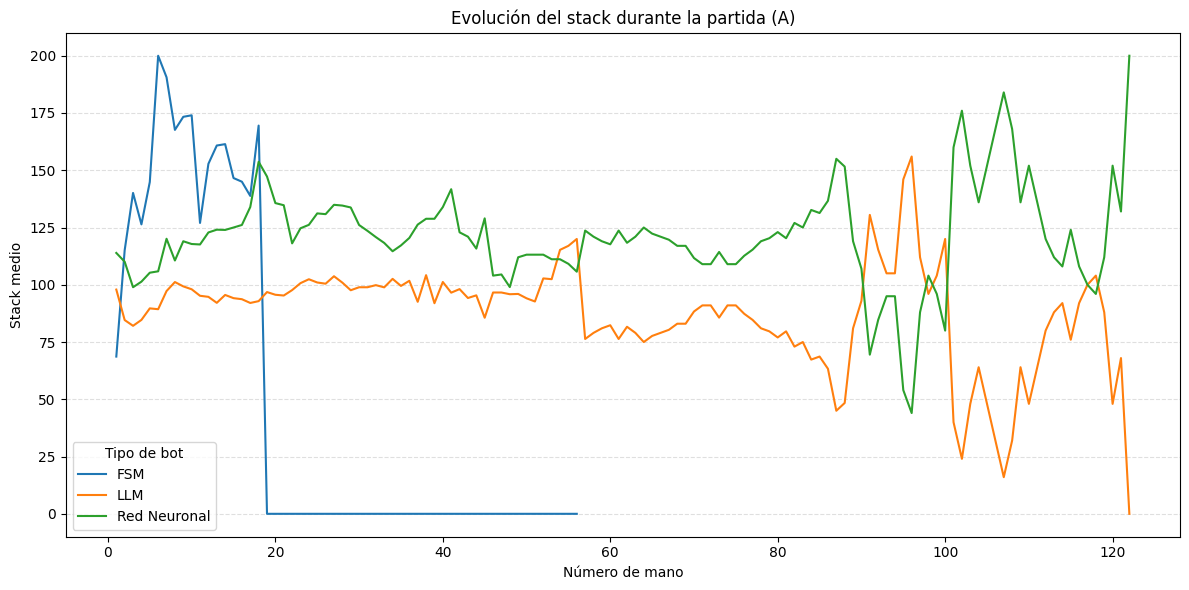

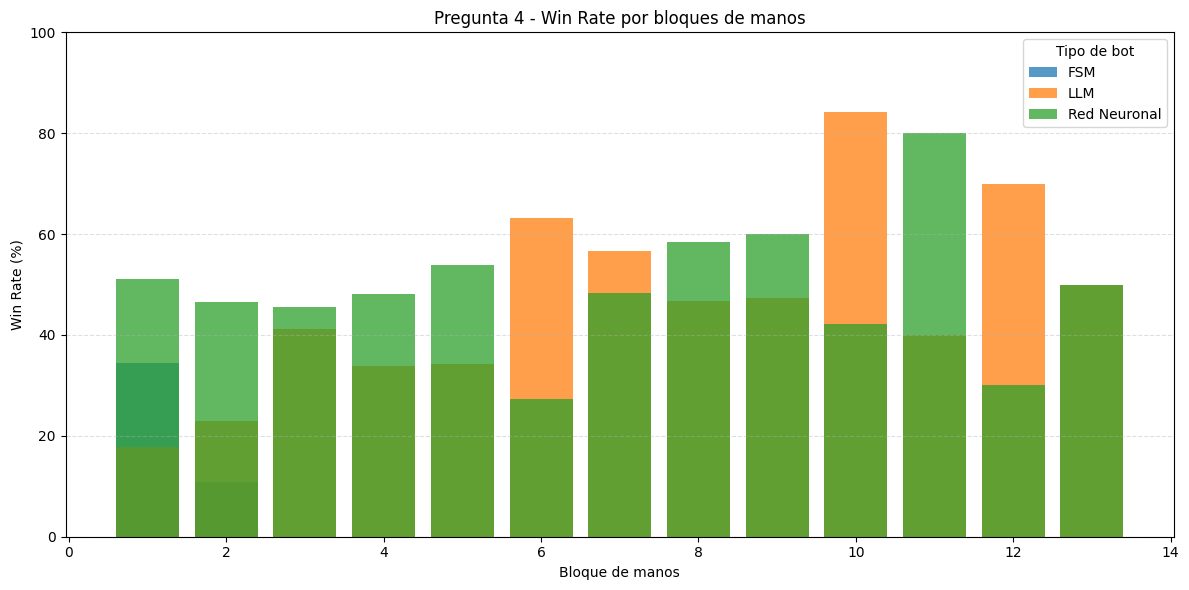

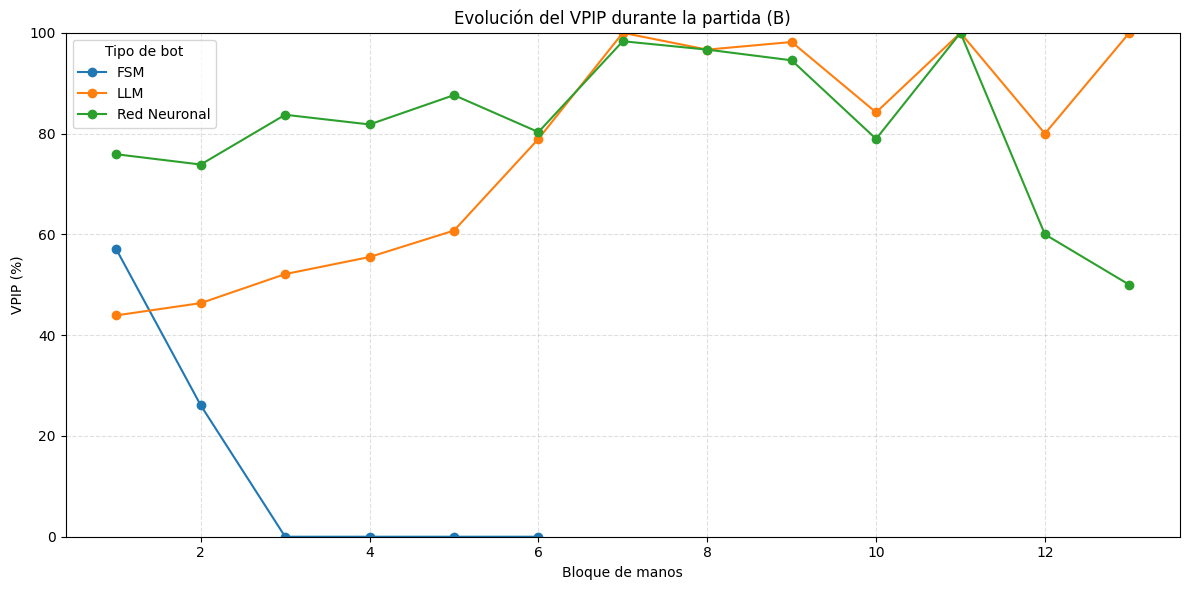

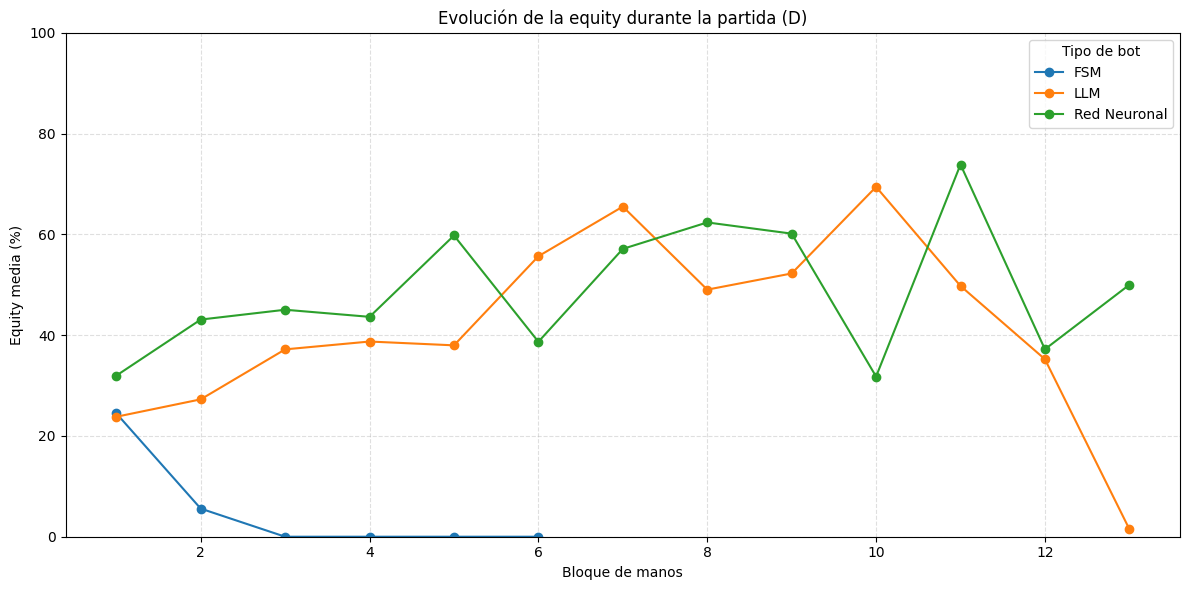

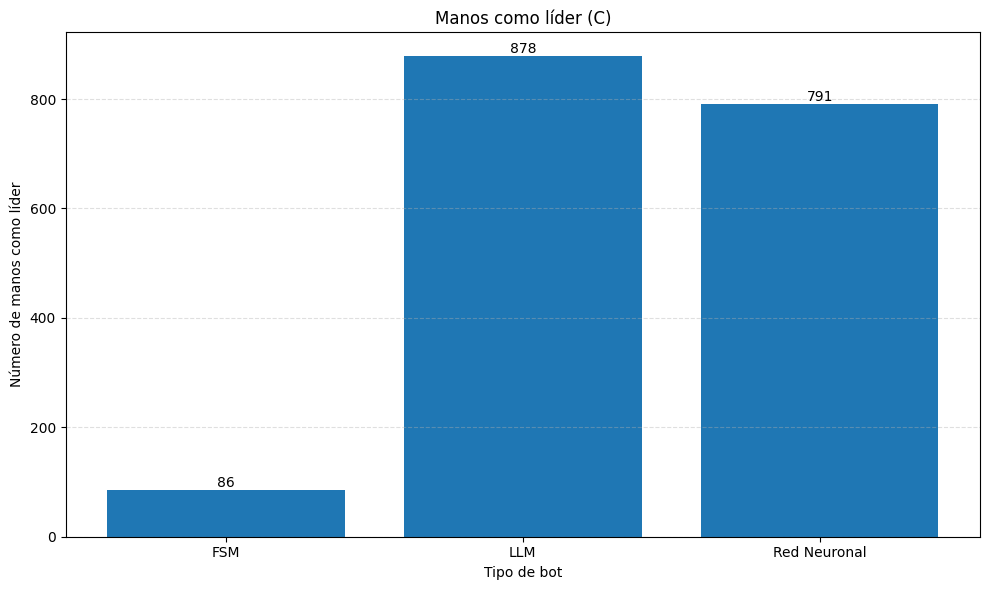

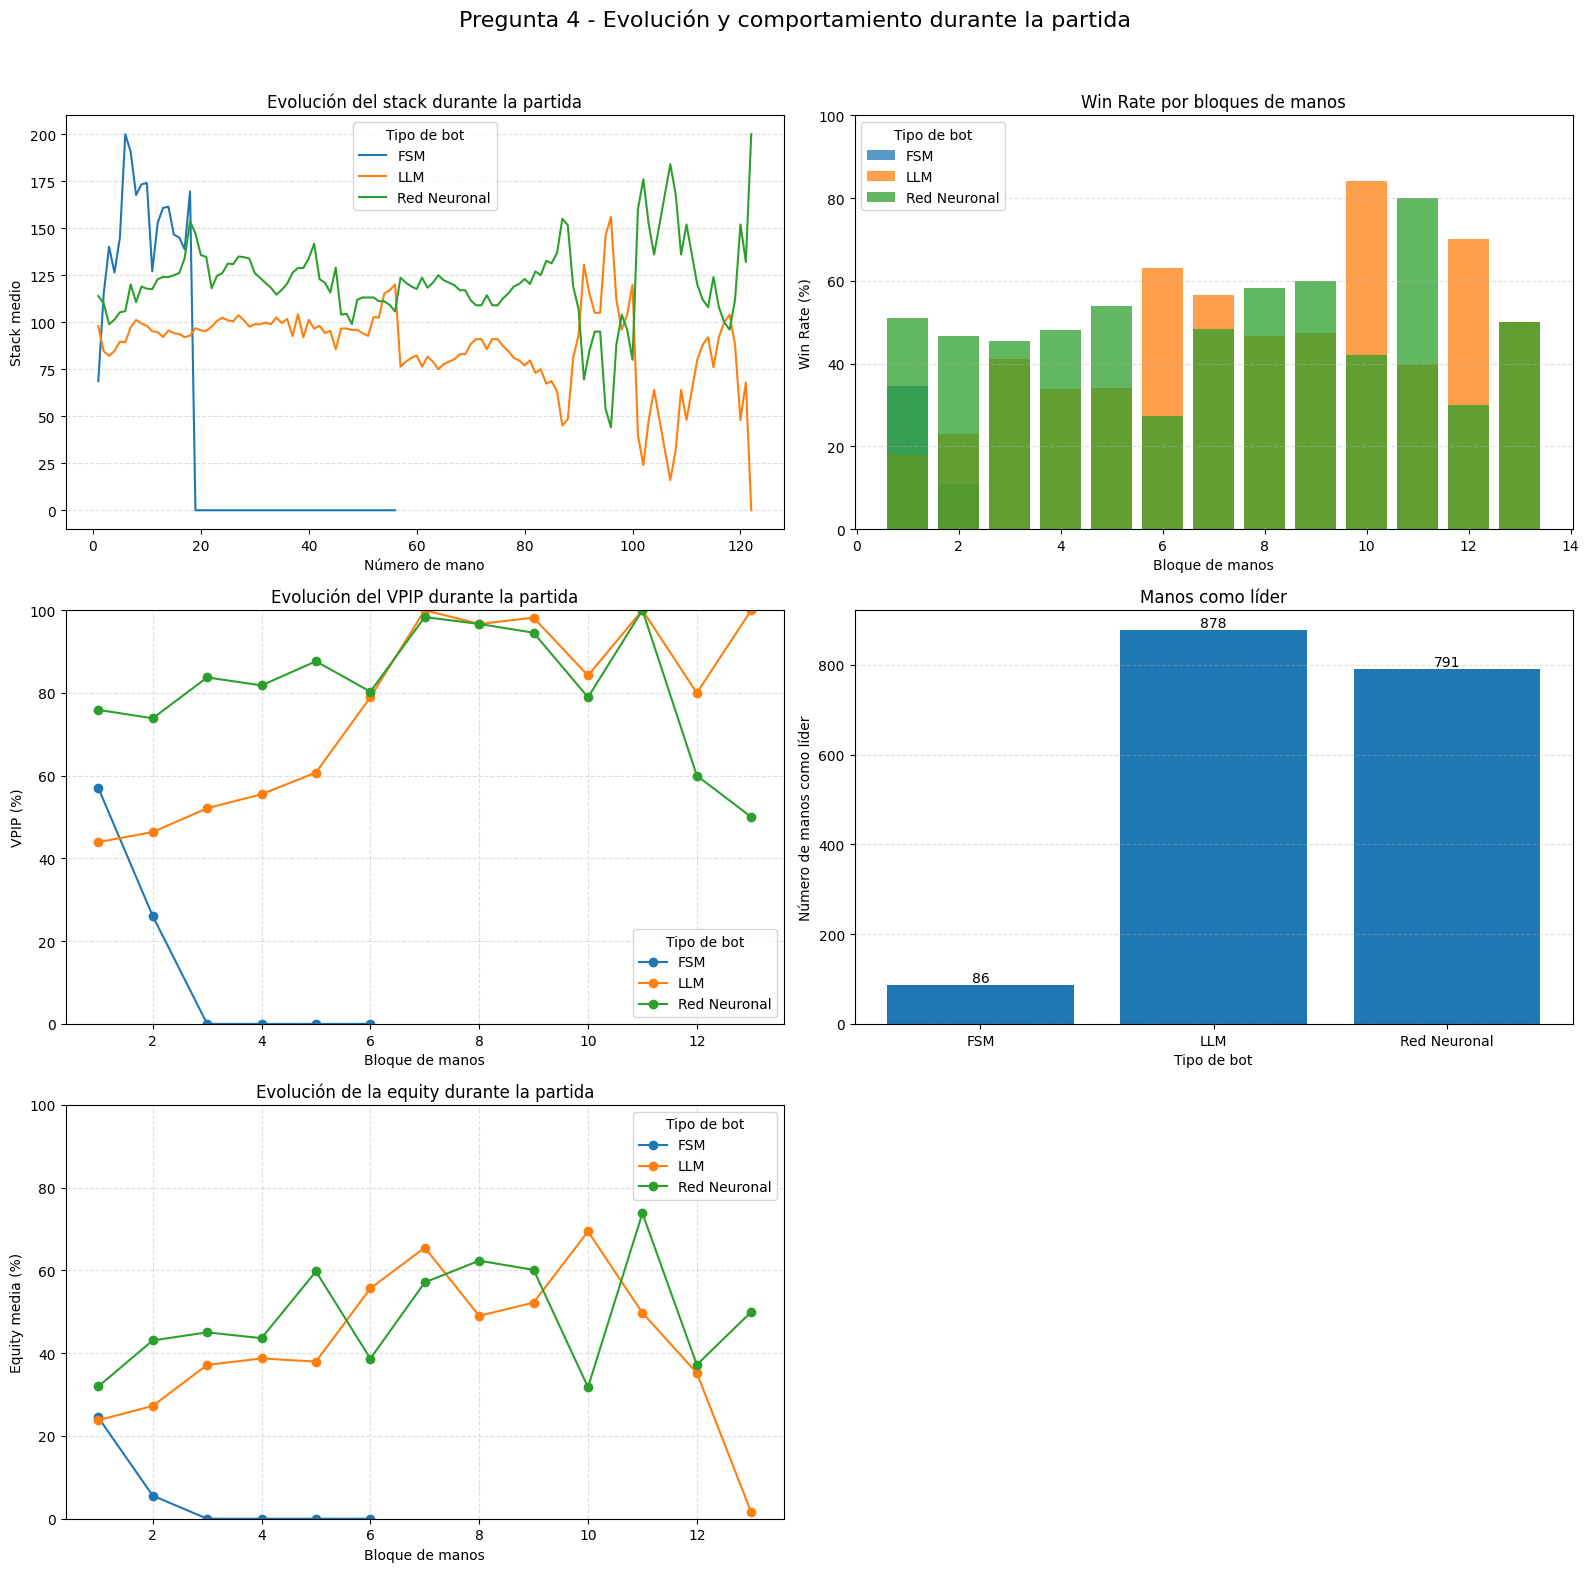

In [201]:
evolucion_stack()
winrate_por_bloques()
evolucion_vpip()
evolucion_equity()
manos_como_lider()

completa_pregunta_4()

## Pregunta 5 - ¿Cómo consigue ganar cada bot?
- Manos hasta ganar
- Eliminaciones
- All-ins por victoria
- Fold del rival
- Showdown
- All-in
- Gráficas: Variadas

In [202]:
### MANOS HASTA GANAR ###
def manos_hasta_ganar():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    victorias = all_bot_data[
        all_bot_data['Hand result'] == 'WON'
    ]

    # Número medio de mano en la que consigue la victoria
    manos = (
        victorias
        .groupby('Type')['Hand']
        .mean()
        .sort_values()
    )

    manos.index = [
        nombres_tipos.get(x, x)
        for x in manos.index
    ]

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        manos.index,
        manos.values
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('Número medio de mano')
    plt.title('Manos hasta conseguir la victoria (A)')

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.1f}',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_5_manos_hasta_ganar.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

### ELIMINACIONES ###
def eliminaciones_bots():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # Las eliminaciones se producen cuando un jugador
    # termina una mano con 0 fichas.
    eliminaciones = all_bot_data[
        all_bot_data['Final stack'] <= 0
    ]

    eliminaciones = (
        eliminaciones
        .groupby('Type')
        .size()
    )

    eliminaciones.index = [
        nombres_tipos.get(x, x)
        for x in eliminaciones.index
    ]

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        eliminaciones.index,
        eliminaciones.values
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('Número de eliminaciones')
    plt.title('Eliminaciones conseguidas (B)')

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_5_eliminaciones.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

### ALL-INS POR VICTORIA ###
def allins_por_victoria():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    victorias = all_bot_data[
        all_bot_data['Hand result'] == 'WON'
    ]

    # Media de All-ins realizados por victoria
    allins = (
        victorias
        .groupby('Type')['AllIns']
        .mean()
    )

    allins.index = [
        nombres_tipos.get(x, x)
        for x in allins.index
    ]

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        allins.index,
        allins.values
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('All-ins medios por victoria')
    plt.title('All-ins por victoria (C)')

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_5_allins_por_victoria.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

### FORMA DE CONSEGUIR LA VICTORIA ###
def forma_victorias():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    victorias = all_bot_data[
        all_bot_data['Hand result'] == 'WON'
    ].copy()

    resultados = []

    # --------------------------------------------------------
    # Analizar cada victoria
    # --------------------------------------------------------

    for _, victoria in victorias.iterrows():

        match = victoria['Match']
        hand = victoria['Hand']
        tipo = victoria['Type']

        # Todos los jugadores de esa misma mano
        mano = all_bot_data[
            (all_bot_data['Match'] == match) &
            (all_bot_data['Hand'] == hand)
        ]

        # Jugadores rivales
        rivales = mano[
            mano['Player'] != victoria['Player']
        ]

        # Comprobar si algún rival hizo Fold
        fold_rival = rivales[
            rivales['End reason']
            .fillna('')
            .str.contains(
                'Fold',
                case=False,
                na=False
            )
        ]

        if len(fold_rival) > 0:

            motivo = 'Fold del rival'

        else:

            # Comprobar si algún rival perdió en showdown
            showdown_rival = rivales[
                rivales['End reason']
                .fillna('')
                .str.contains(
                    'Lost at Showdown',
                    case=False,
                    na=False
                )
            ]

            if len(showdown_rival) > 0:

                motivo = 'Showdown'

            # Comprobar All-in del ganador
            elif victoria['AllIns'] > 0:

                motivo = 'All-in'

            else:

                motivo = 'No determinado'

        resultados.append({
            'Type': tipo,
            'Victory type': motivo
        })

    df_resultados = pd.DataFrame(resultados)

    # --------------------------------------------------------
    # Contar resultados
    # --------------------------------------------------------

    tabla = (
        df_resultados
        .groupby(['Type', 'Victory type'])
        .size()
        .unstack(fill_value=0)
    )

    categorias = [
        'Fold del rival',
        'Showdown',
        'All-in',
        'No determinado'
    ]

    for categoria in categorias:

        if categoria not in tabla.columns:
            tabla[categoria] = 0

    tabla = tabla[categorias]

    tabla.index = [
        nombres_tipos.get(x, x)
        for x in tabla.index
    ]

    # --------------------------------------------------------
    # Convertir a porcentajes
    # --------------------------------------------------------

    tabla_porcentaje = (
        tabla
        .div(tabla.sum(axis=1), axis=0)
        * 100
    )

    # --------------------------------------------------------
    # Gráfico de barras apiladas
    # --------------------------------------------------------

    ax = tabla_porcentaje.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('Porcentaje de victorias (%)')
    plt.title('Forma de conseguir la victoria (D)')
    plt.xticks(rotation=0)

    plt.ylim(0, 100)

    plt.legend(
        title='Forma de victoria'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_5_forma_victoria.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


In [203]:
### ============================================================
### TODAS LAS GRÁFICAS DE LA PREGUNTA 5 JUNTAS
### ============================================================
def completa_pregunta_5():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # ========================================================
    # DATOS - MANOS HASTA GANAR
    # ========================================================

    victorias = all_bot_data[
        all_bot_data['Hand result'] == 'WON'
    ]

    manos = (
        victorias
        .groupby('Type')['Hand']
        .mean()
        .sort_values()
    )

    manos.index = [
        nombres_tipos.get(x, x)
        for x in manos.index
    ]


    # ========================================================
    # DATOS - ELIMINACIONES
    # ========================================================

    eliminaciones = all_bot_data[
        all_bot_data['Final stack'] <= 0
    ]

    eliminaciones = (
        eliminaciones
        .groupby('Type')
        .size()
    )

    eliminaciones.index = [
        nombres_tipos.get(x, x)
        for x in eliminaciones.index
    ]


    # ========================================================
    # DATOS - ALL-INS POR VICTORIA
    # ========================================================

    allins = (
        victorias
        .groupby('Type')['AllIns']
        .mean()
    )

    allins.index = [
        nombres_tipos.get(x, x)
        for x in allins.index
    ]


    # ========================================================
    # DATOS - FORMA DE CONSEGUIR LA VICTORIA
    # ========================================================

    resultados = []

    for _, victoria in victorias.iterrows():

        match = victoria['Match']
        hand = victoria['Hand']
        tipo = victoria['Type']

        mano = all_bot_data[
            (all_bot_data['Match'] == match) &
            (all_bot_data['Hand'] == hand)
        ]

        rivales = mano[
            mano['Player'] != victoria['Player']
        ]

        fold_rival = rivales[
            rivales['End reason']
            .fillna('')
            .str.contains(
                'Fold',
                case=False,
                na=False
            )
        ]

        if len(fold_rival) > 0:

            motivo = 'Fold del rival'

        else:

            showdown_rival = rivales[
                rivales['End reason']
                .fillna('')
                .str.contains(
                    'Lost at Showdown',
                    case=False,
                    na=False
                )
            ]

            if len(showdown_rival) > 0:

                motivo = 'Showdown'

            elif victoria['AllIns'] > 0:

                motivo = 'All-in'

            else:

                motivo = 'No determinado'

        resultados.append({
            'Type': tipo,
            'Victory type': motivo
        })

    df_resultados = pd.DataFrame(
        resultados
    )

    tabla = (
        df_resultados
        .groupby(
            ['Type', 'Victory type']
        )
        .size()
        .unstack(fill_value=0)
    )

    categorias = [
        'Fold del rival',
        'Showdown',
        'All-in',
        'No determinado'
    ]

    for categoria in categorias:

        if categoria not in tabla.columns:
            tabla[categoria] = 0

    tabla = tabla[categorias]

    tabla.index = [
        nombres_tipos.get(x, x)
        for x in tabla.index
    ]

    tabla_porcentaje = (
        tabla
        .div(
            tabla.sum(axis=1),
            axis=0
        )
        * 100
    )


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 12)
    )


    # ========================================================
    # 1 - MANOS HASTA GANAR
    # ========================================================

    bars = axes[0, 0].bar(
        manos.index,
        manos.values
    )

    axes[0, 0].set_xlabel(
        'Tipo de bot'
    )

    axes[0, 0].set_ylabel(
        'Número medio de mano'
    )

    axes[0, 0].set_title(
        'Manos hasta conseguir la victoria'
    )

    for bar in bars:

        height = bar.get_height()

        axes[0, 0].text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{height:.1f}',
            ha='center',
            va='bottom'
        )

    axes[0, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 2 - ELIMINACIONES
    # ========================================================

    bars = axes[0, 1].bar(
        eliminaciones.index,
        eliminaciones.values
    )

    axes[0, 1].set_xlabel(
        'Tipo de bot'
    )

    axes[0, 1].set_ylabel(
        'Número de eliminaciones'
    )

    axes[0, 1].set_title(
        'Eliminaciones conseguidas'
    )

    for bar in bars:

        height = bar.get_height()

        axes[0, 1].text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    axes[0, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 3 - ALL-INS POR VICTORIA
    # ========================================================

    bars = axes[1, 0].bar(
        allins.index,
        allins.values
    )

    axes[1, 0].set_xlabel(
        'Tipo de bot'
    )

    axes[1, 0].set_ylabel(
        'All-ins medios por victoria'
    )

    axes[1, 0].set_title(
        'All-ins por victoria'
    )

    for bar in bars:

        height = bar.get_height()

        axes[1, 0].text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

    axes[1, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 4 - FORMA DE CONSEGUIR LA VICTORIA
    # ========================================================

    tabla_porcentaje.plot(
        kind='bar',
        stacked=True,
        ax=axes[1, 1]
    )

    axes[1, 1].set_xlabel(
        'Tipo de bot'
    )

    axes[1, 1].set_ylabel(
        'Porcentaje de victorias (%)'
    )

    axes[1, 1].set_title(
        'Forma de conseguir la victoria'
    )

    axes[1, 1].set_xticklabels(
        axes[1, 1].get_xticklabels(),
        rotation=0
    )

    axes[1, 1].set_ylim(
        0,
        100
    )

    axes[1, 1].legend(
        title='Forma de victoria'
    )

    axes[1, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 5 - ¿Cómo consigue ganar cada bot?',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.95
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_5_completa.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

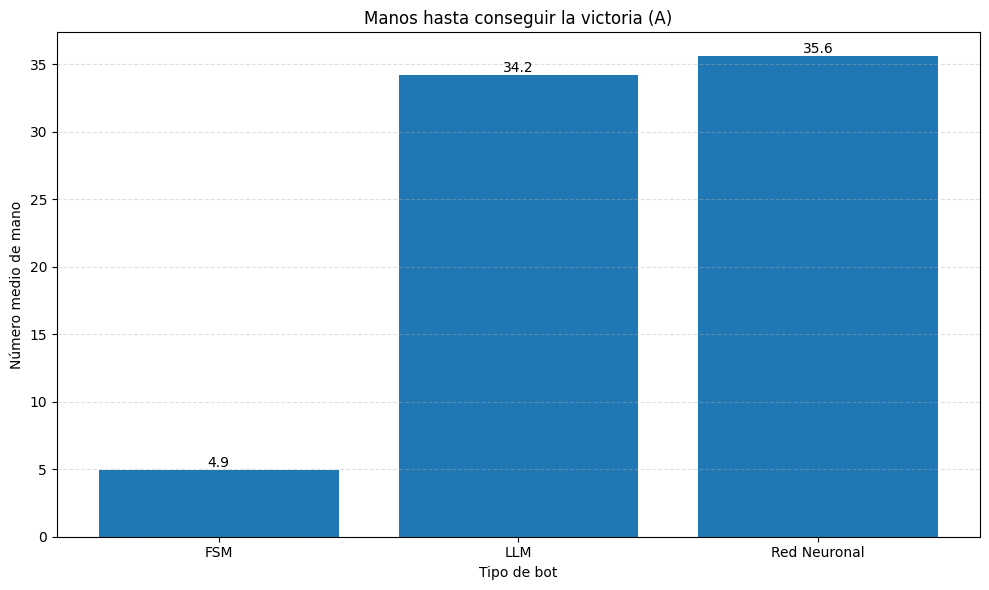

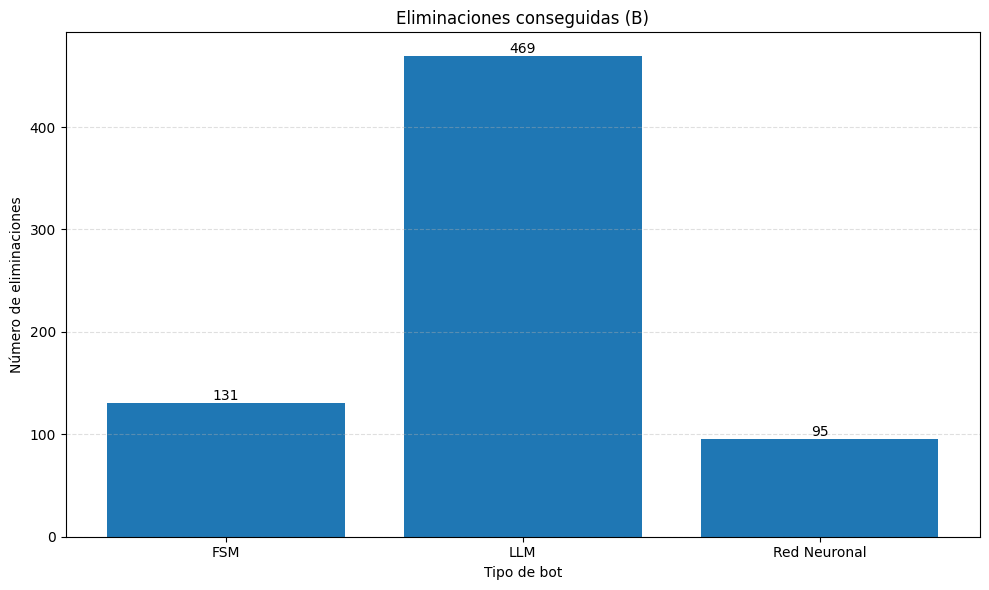

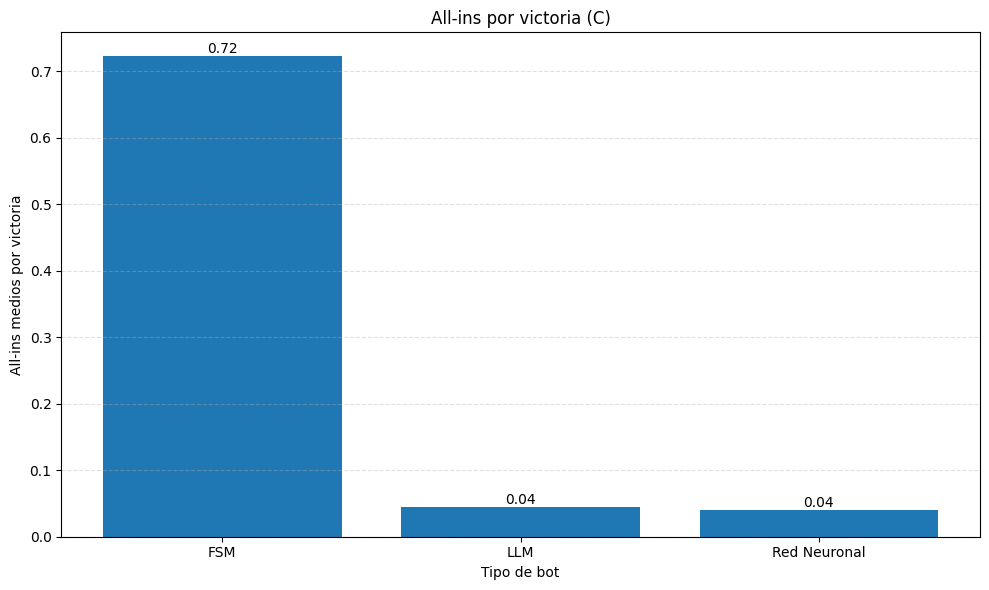

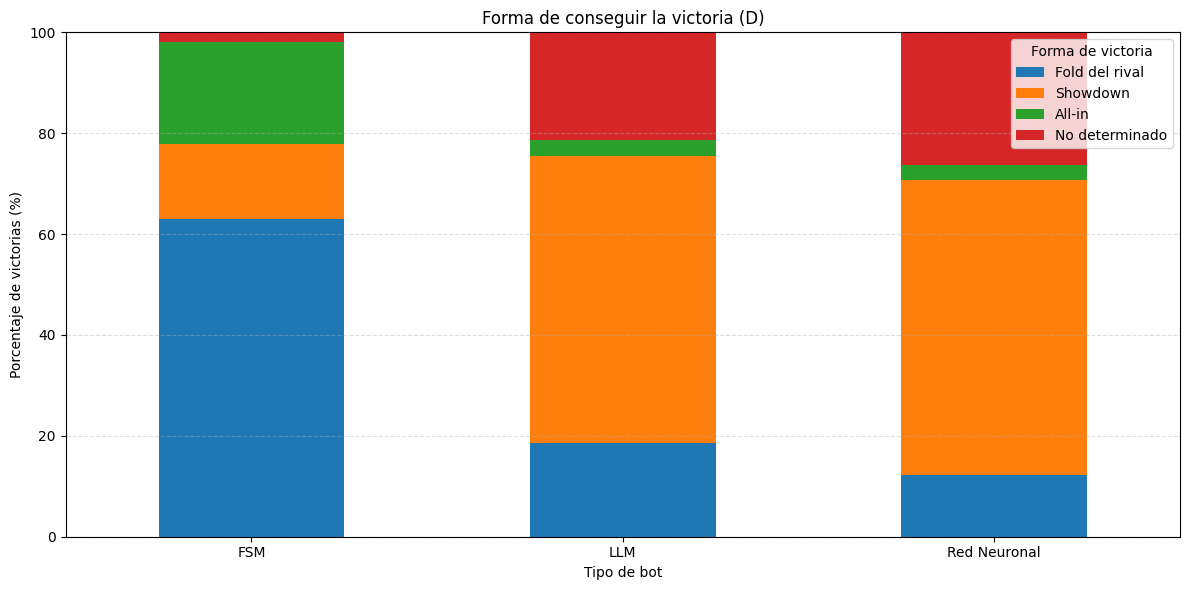

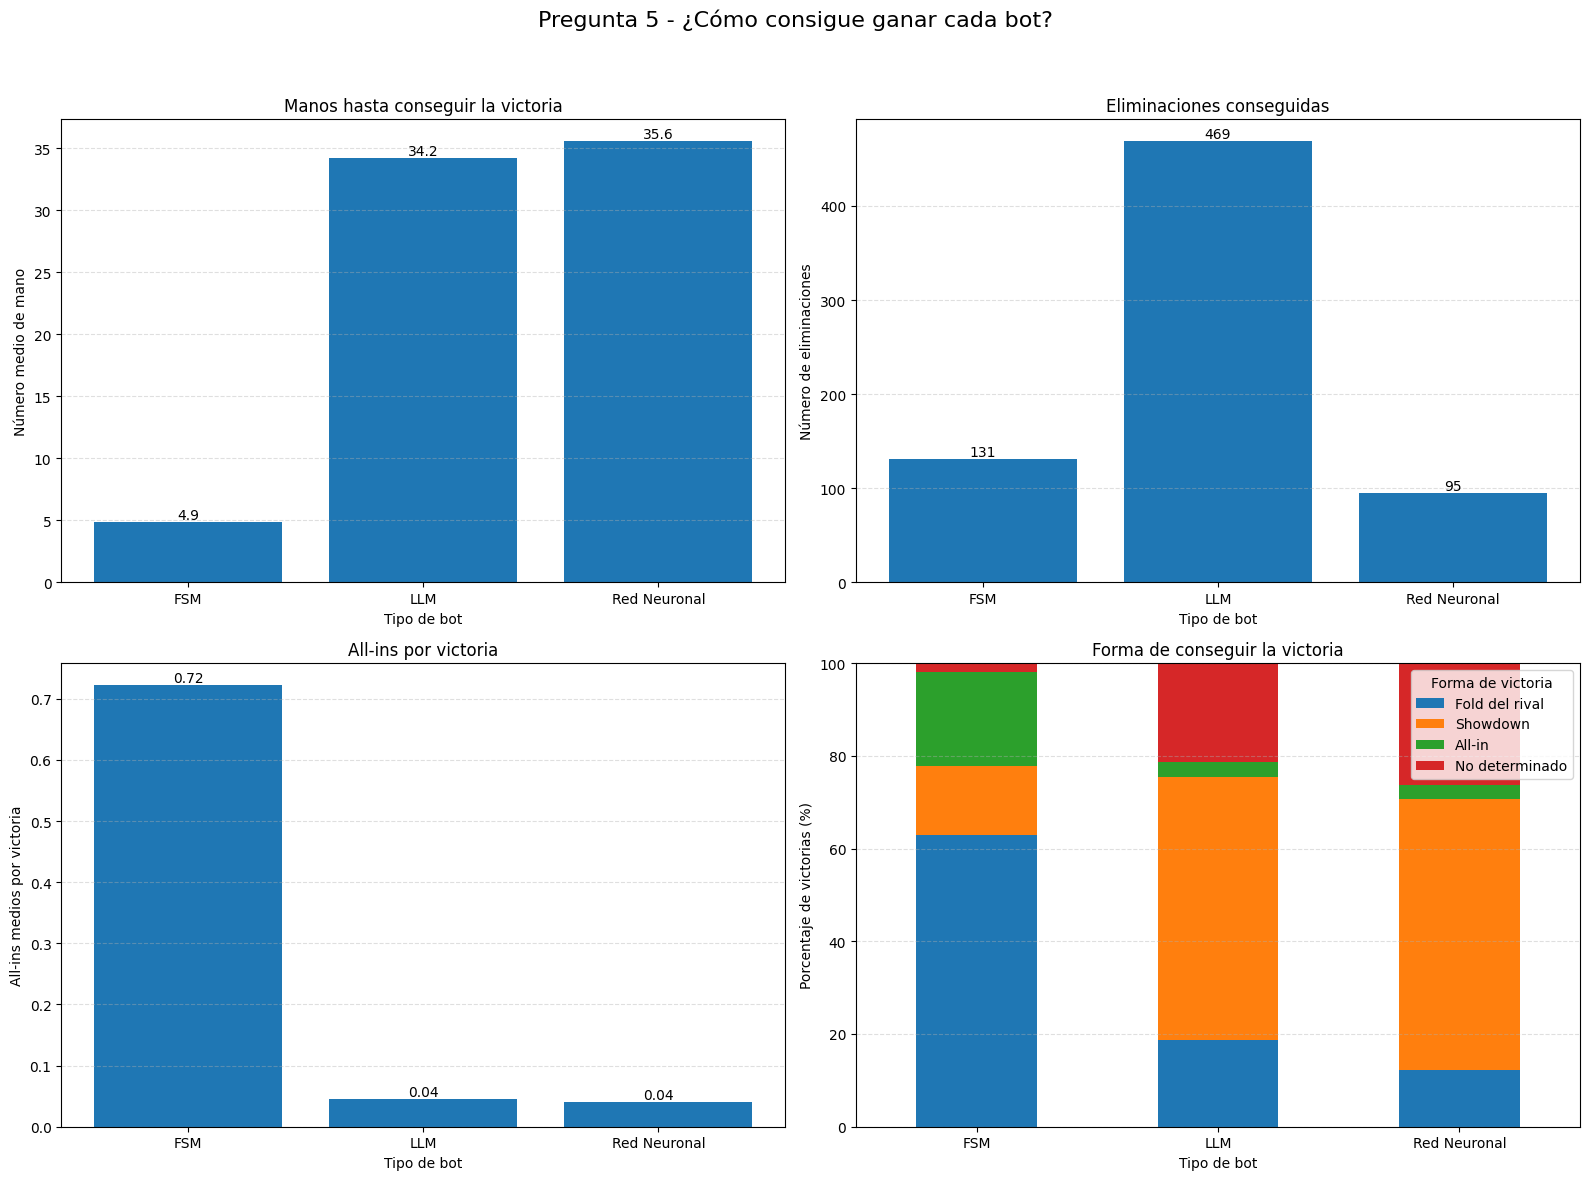

In [204]:
manos_hasta_ganar()
eliminaciones_bots()
allins_por_victoria()
forma_victorias()

completa_pregunta_5()

## Pregunta 6 - ¿Influye el tipo de partida?
- Heads-Up vs Humanos + Bots vs Solo Bots.
- Rendimiento, comportamiento, All-ins, manos hasta ganar y equity.
- Gráficas: Barras.

Y de todo esto podemos sacar las preguntas más interesantes:
- ¿Qué bot gana más rápido?
- ¿Qué bot hace más All-ins?
- ¿Qué bot acierta más cuando hace All-in?
- ¿Qué bot toma mejores decisiones?
- ¿Qué decisiones generan más ganancias o pérdidas?
- ¿Qué bot remonta mejor?
- ¿Qué bot lidera durante más tiempo?

¿Qué bot elimina más jugadores?
- Comparar LLM Local, LLM Online, Red Neuronal y FSM.
- Dentro de los LLM, comparar también los distintos estilos

- ¿Qué bot es más consistente?
- ¿El bot mejora durante la partida?
- ¿Cómo gana cada bot?
- ¿La equity se traduce realmente en mejores resultados?
- ¿Tomar más riesgos aumenta las posibilidades de ganar?

In [205]:
### PREGUNTA 6 - ¿INFLUYE EL TIPO DE PARTIDA? ###


# ============================================================
# PREPARAR DATOS
# ============================================================

def preparar_pregunta_6():

    datos_p6 = []

    for experimento, variantes in datos.items():

        # Identificar el tipo de partida
        if experimento == "1-bot_vs_1-humano":
            tipo_partida = "Heads-Up"

        elif experimento == "1-humano_vs_4-bots":
            tipo_partida = "Humanos + Bots"

        elif experimento == "1-bot_vs_1-bot":
            tipo_partida = "Solo Bots"

        else:
            # No incluir otros experimentos
            continue

        for variante, df in variantes.items():

            # Solo jugadores bots
            df_temp = df[
                df['Type'] != 'HUMAN'
            ].copy()

            # Guardar el contexto de la partida
            df_temp['Tipo partida'] = tipo_partida

            datos_p6.append(df_temp)

    if not datos_p6:
        return pd.DataFrame()

    return pd.concat(
        datos_p6,
        ignore_index=True
    )


datos_p6 = preparar_pregunta_6()


# ============================================================
# NOMBRES DE LOS TIPOS DE BOT
# ============================================================

nombres_tipos = {
    "BOT_LLM": "LLM",
    "BOT_NN": "Red Neuronal",
    "BOT_FSM": "FSM"
}


# ============================================================
# 1. WIN RATE
# ============================================================

def winrate_pregunta_6():

    winrate = (
        datos_p6
        .groupby(
            ['Tipo partida', 'Type']
        )['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
        .unstack()
    )

    winrate = winrate.rename(
        columns=nombres_tipos
    )

    ax = winrate.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Tipo de partida')
    plt.ylabel('Win Rate (%)')
    plt.title('Win Rate según el tipo de partida (A)')

    plt.xticks(rotation=0)
    plt.ylim(0, 100)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_6_winrate.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 2. VPIP
# ============================================================

def vpip_pregunta_6():

    vpip = (
        datos_p6
        .groupby(
            ['Tipo partida', 'Type']
        )['VPIP']
        .mean()
        * 100
    )

    vpip = vpip.unstack().rename(
        columns=nombres_tipos
    )

    ax = vpip.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Tipo de partida')
    plt.ylabel('VPIP (%)')
    plt.title('Pregunta 6 - VPIP según el tipo de partida (B)')

    plt.xticks(rotation=0)
    plt.ylim(0, 100)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_6_vpip.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 3. ALL-INS
# ============================================================

def allins_pregunta_6():

    allins = (
        datos_p6
        .groupby(
            ['Tipo partida', 'Type']
        )['AllIns']
        .sum()
    )

    allins = allins.unstack().rename(
        columns=nombres_tipos
    )

    ax = allins.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Tipo de partida')
    plt.ylabel('Número de All-ins')
    plt.title('All-ins según el tipo de partida (C)')

    plt.xticks(rotation=0)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_6_allins.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 4. MANOS HASTA CONSEGUIR UNA VICTORIA
# ============================================================

def manos_ganar_pregunta_6():

    victorias = datos_p6[
        datos_p6['Hand result'] == 'WON'
    ]

    manos = (
        victorias
        .groupby(
            ['Tipo partida', 'Type']
        )['Hand']
        .mean()
    )

    manos = manos.unstack().rename(
        columns=nombres_tipos
    )

    ax = manos.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Tipo de partida')
    plt.ylabel('Número medio de mano')
    plt.title('Mano media en la que se consigue una victoria (D)')

    plt.xticks(rotation=0)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_6_manos_hasta_ganar.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 5. EQUITY
# ============================================================

def equity_pregunta_6():

    equity_columnas = [
        'Preflop equity',
        'Flop equity',
        'Turn equity',
        'River equity'
    ]

    datos_equity = datos_p6.copy()

    # --------------------------------------------------------
    # Obtener la última equity disponible de cada mano
    # --------------------------------------------------------
    #
    # Ejemplo:
    #
    # Preflop = 40 %
    # Flop    = 55 %
    # Turn    = 62 %
    # River   = 0 %
    #
    # Se utilizará 62 %.
    #
    # El 0 % del parser representa una calle sin equity
    # disponible, por lo que se considera NaN.
    # --------------------------------------------------------

    datos_equity[equity_columnas] = (
        datos_equity[equity_columnas]
        .replace(0, np.nan)
    )

    datos_equity['Equity'] = (
        datos_equity[equity_columnas]
        .ffill(axis=1)
        .iloc[:, -1]
    )

    # Equity media por tipo de partida y tipo de bot
    equity = (
        datos_equity
        .groupby(
            ['Tipo partida', 'Type']
        )['Equity']
        .mean()
    )

    equity = equity.unstack().rename(
        columns=nombres_tipos
    )

    ax = equity.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Tipo de partida')
    plt.ylabel('Equity media (%)')
    plt.title('Equity según el tipo de partida (E)')

    plt.xticks(rotation=0)
    plt.ylim(0, 100)

    plt.legend(
        title='Tipo de bot'
    )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "pregunta_6_equity.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


In [206]:
### ============================================================
### TODAS LAS GRÁFICAS DE LA PREGUNTA 6 JUNTAS
### ============================================================
def completa_pregunta_6():

    nombres_tipos = {
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    }

    # ========================================================
    # DATOS
    # ========================================================

    # --------------------------------------------------------
    # 1. WIN RATE
    # --------------------------------------------------------

    winrate = (
        datos_p6
        .groupby(
            ['Tipo partida', 'Type']
        )['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
        .unstack()
        .rename(columns=nombres_tipos)
    )


    # --------------------------------------------------------
    # 2. VPIP
    # --------------------------------------------------------

    vpip = (
        datos_p6
        .groupby(
            ['Tipo partida', 'Type']
        )['VPIP']
        .mean()
        .mul(100)
        .unstack()
        .rename(columns=nombres_tipos)
    )


    # --------------------------------------------------------
    # 3. ALL-INS
    # --------------------------------------------------------

    allins = (
        datos_p6
        .groupby(
            ['Tipo partida', 'Type']
        )['AllIns']
        .sum()
        .unstack()
        .rename(columns=nombres_tipos)
    )


    # --------------------------------------------------------
    # 4. MANOS HASTA GANAR
    # --------------------------------------------------------

    victorias = datos_p6[
        datos_p6['Hand result'] == 'WON'
    ]

    manos = (
        victorias
        .groupby(
            ['Tipo partida', 'Type']
        )['Hand']
        .mean()
        .unstack()
        .rename(columns=nombres_tipos)
    )


    # --------------------------------------------------------
    # 5. EQUITY
    # --------------------------------------------------------

    equity_columnas = [
        'Preflop equity',
        'Flop equity',
        'Turn equity',
        'River equity'
    ]

    datos_equity = datos_p6.copy()

    datos_equity[equity_columnas] = (
        datos_equity[equity_columnas]
        .replace(0, np.nan)
    )

    datos_equity['Equity'] = (
        datos_equity[equity_columnas]
        .ffill(axis=1)
        .iloc[:, -1]
    )

    equity = (
        datos_equity
        .groupby(
            ['Tipo partida', 'Type']
        )['Equity']
        .mean()
        .unstack()
        .rename(columns=nombres_tipos)
    )


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16)
    )


    # ========================================================
    # 1 - WIN RATE
    # ========================================================

    winrate.plot(
        kind='bar',
        ax=axes[0, 0]
    )

    axes[0, 0].set_xlabel(
        'Tipo de partida'
    )

    axes[0, 0].set_ylabel(
        'Win Rate (%)'
    )

    axes[0, 0].set_title(
        'Win Rate según el tipo de partida'
    )

    axes[0, 0].set_xticklabels(
        axes[0, 0].get_xticklabels(),
        rotation=0
    )

    axes[0, 0].set_ylim(
        0,
        100
    )

    axes[0, 0].legend(
        title='Tipo de bot'
    )

    axes[0, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 2 - VPIP
    # ========================================================

    vpip.plot(
        kind='bar',
        ax=axes[0, 1]
    )

    axes[0, 1].set_xlabel(
        'Tipo de partida'
    )

    axes[0, 1].set_ylabel(
        'VPIP (%)'
    )

    axes[0, 1].set_title(
        'VPIP según el tipo de partida'
    )

    axes[0, 1].set_xticklabels(
        axes[0, 1].get_xticklabels(),
        rotation=0
    )

    axes[0, 1].set_ylim(
        0,
        100
    )

    axes[0, 1].legend(
        title='Tipo de bot'
    )

    axes[0, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 3 - ALL-INS
    # ========================================================

    allins.plot(
        kind='bar',
        ax=axes[1, 0]
    )

    axes[1, 0].set_xlabel(
        'Tipo de partida'
    )

    axes[1, 0].set_ylabel(
        'Número de All-ins'
    )

    axes[1, 0].set_title(
        'All-ins según el tipo de partida'
    )

    axes[1, 0].set_xticklabels(
        axes[1, 0].get_xticklabels(),
        rotation=0
    )

    axes[1, 0].legend(
        title='Tipo de bot'
    )

    axes[1, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 4 - MANOS HASTA GANAR
    # ========================================================

    manos.plot(
        kind='bar',
        ax=axes[1, 1]
    )

    axes[1, 1].set_xlabel(
        'Tipo de partida'
    )

    axes[1, 1].set_ylabel(
        'Número medio de mano'
    )

    axes[1, 1].set_title(
        'Mano media en la que se consigue una victoria'
    )

    axes[1, 1].set_xticklabels(
        axes[1, 1].get_xticklabels(),
        rotation=0
    )

    axes[1, 1].legend(
        title='Tipo de bot'
    )

    axes[1, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 5 - EQUITY
    # ========================================================

    equity.plot(
        kind='bar',
        ax=axes[2, 0]
    )

    axes[2, 0].set_xlabel(
        'Tipo de partida'
    )

    axes[2, 0].set_ylabel(
        'Equity media (%)'
    )

    axes[2, 0].set_title(
        'Equity según el tipo de partida'
    )

    axes[2, 0].set_xticklabels(
        axes[2, 0].get_xticklabels(),
        rotation=0
    )

    axes[2, 0].set_ylim(
        0,
        100
    )

    axes[2, 0].legend(
        title='Tipo de bot'
    )

    axes[2, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 6 - ESPACIO SOBRANTE
    # ========================================================

    axes[2, 1].axis(
        'off'
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 6 - ¿Influye el tipo de partida?',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_6_completa.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

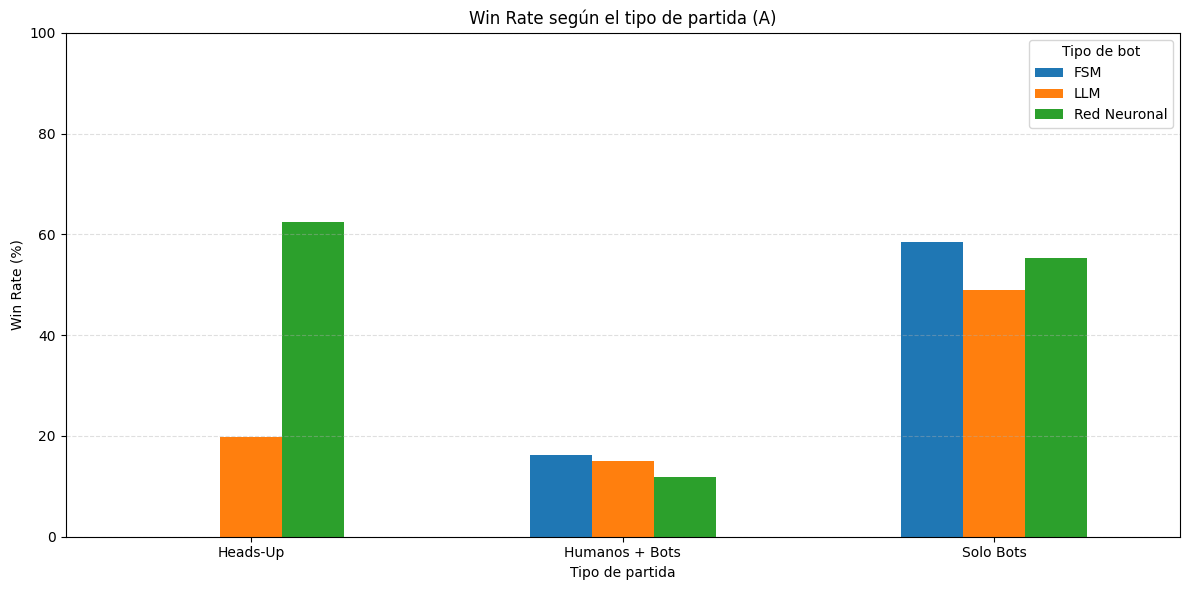

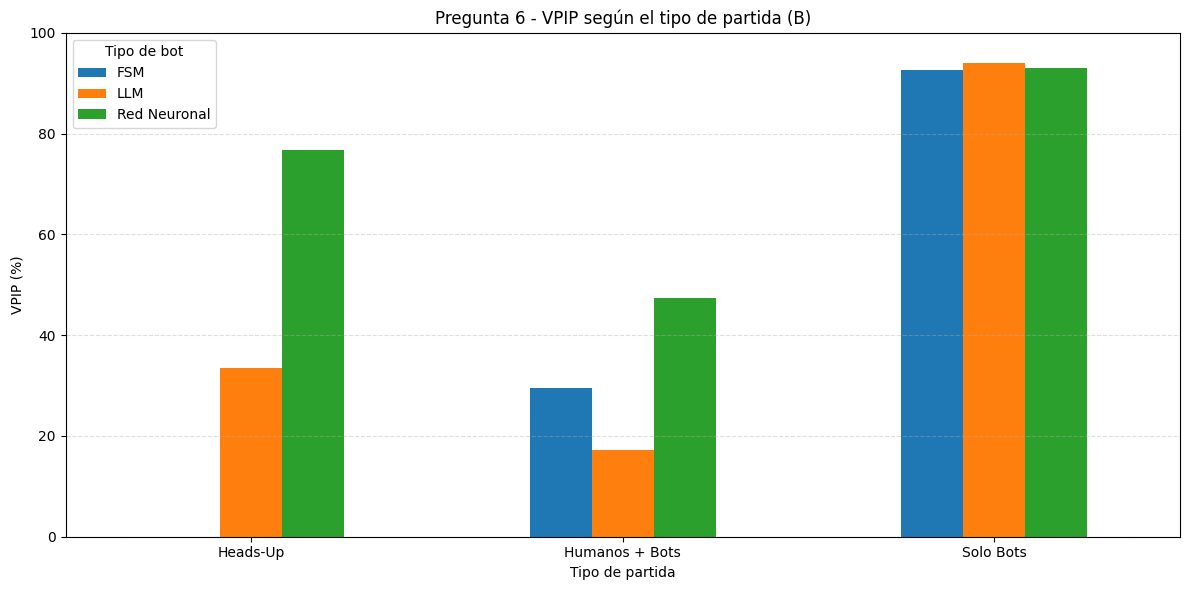

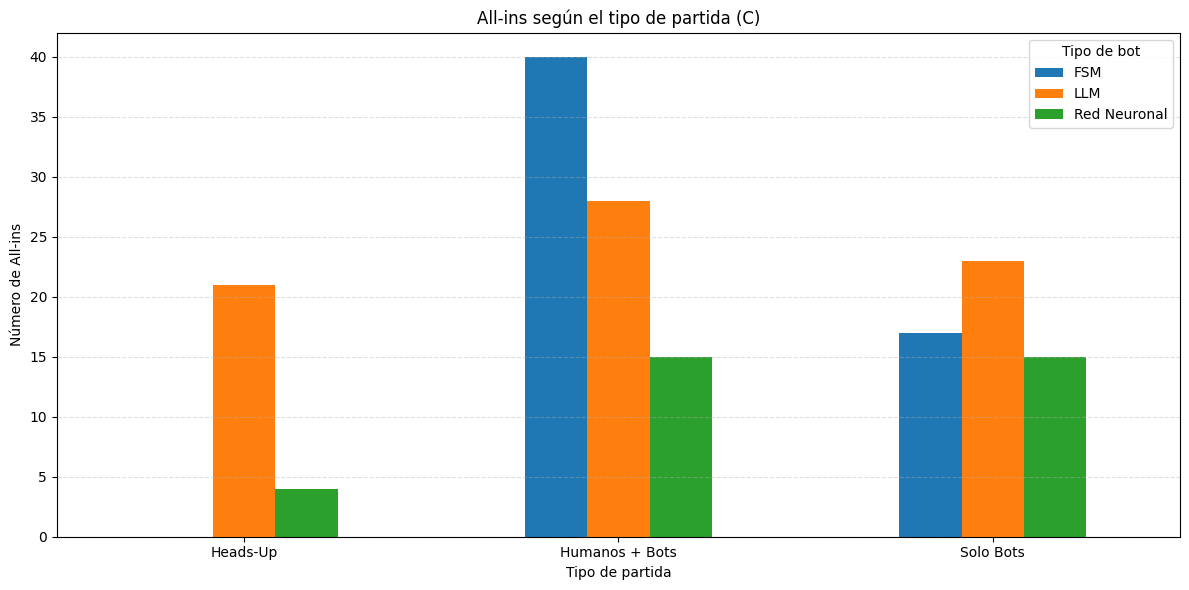

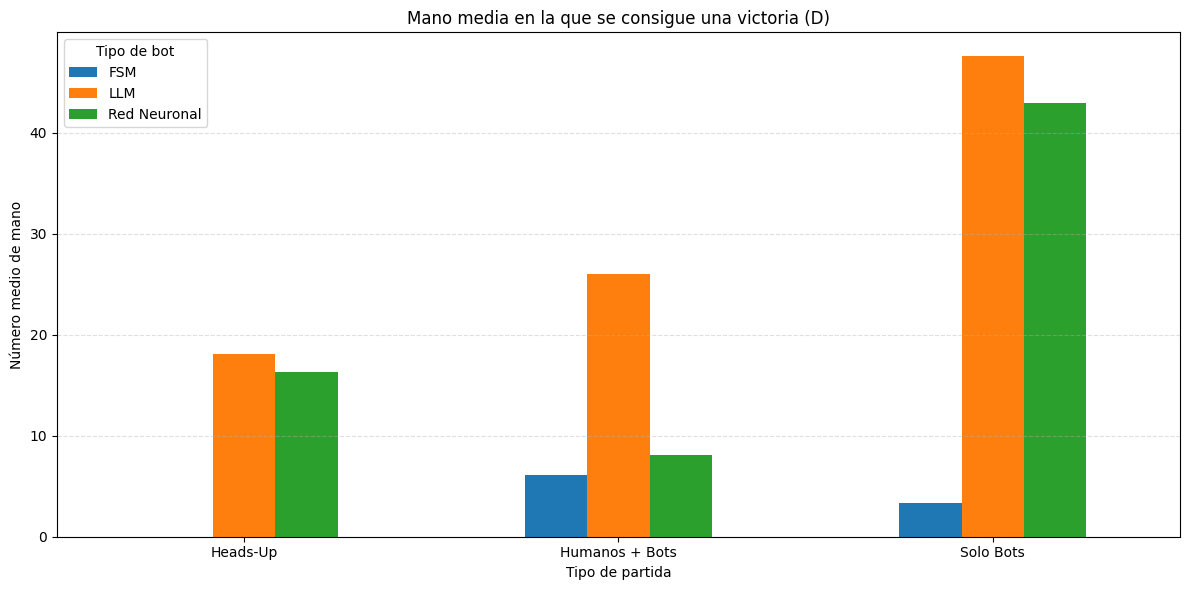

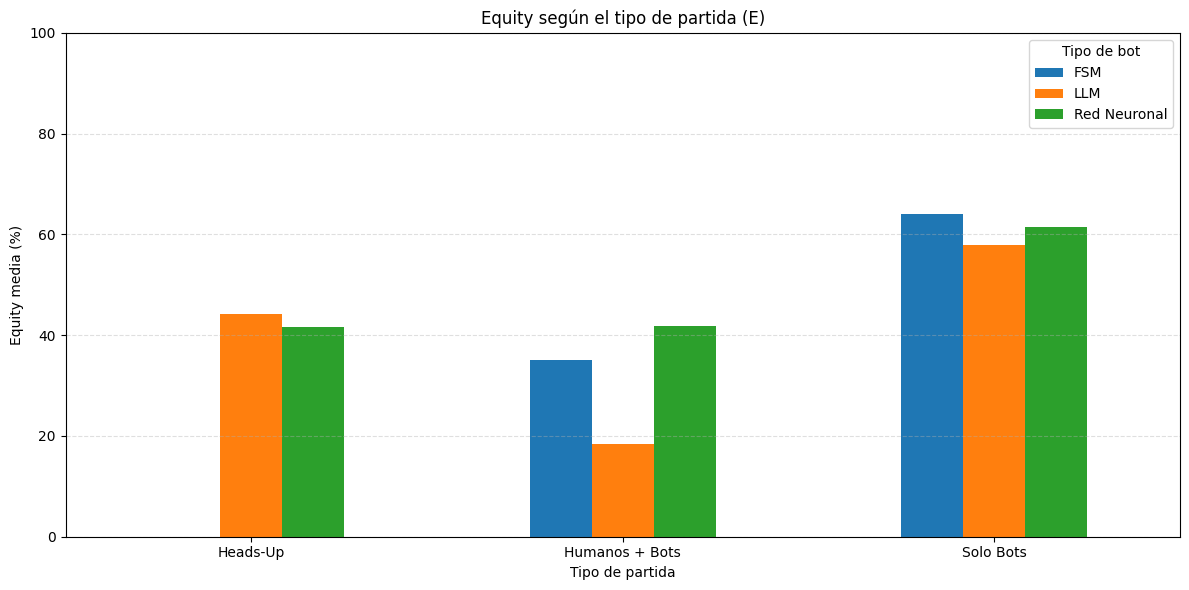

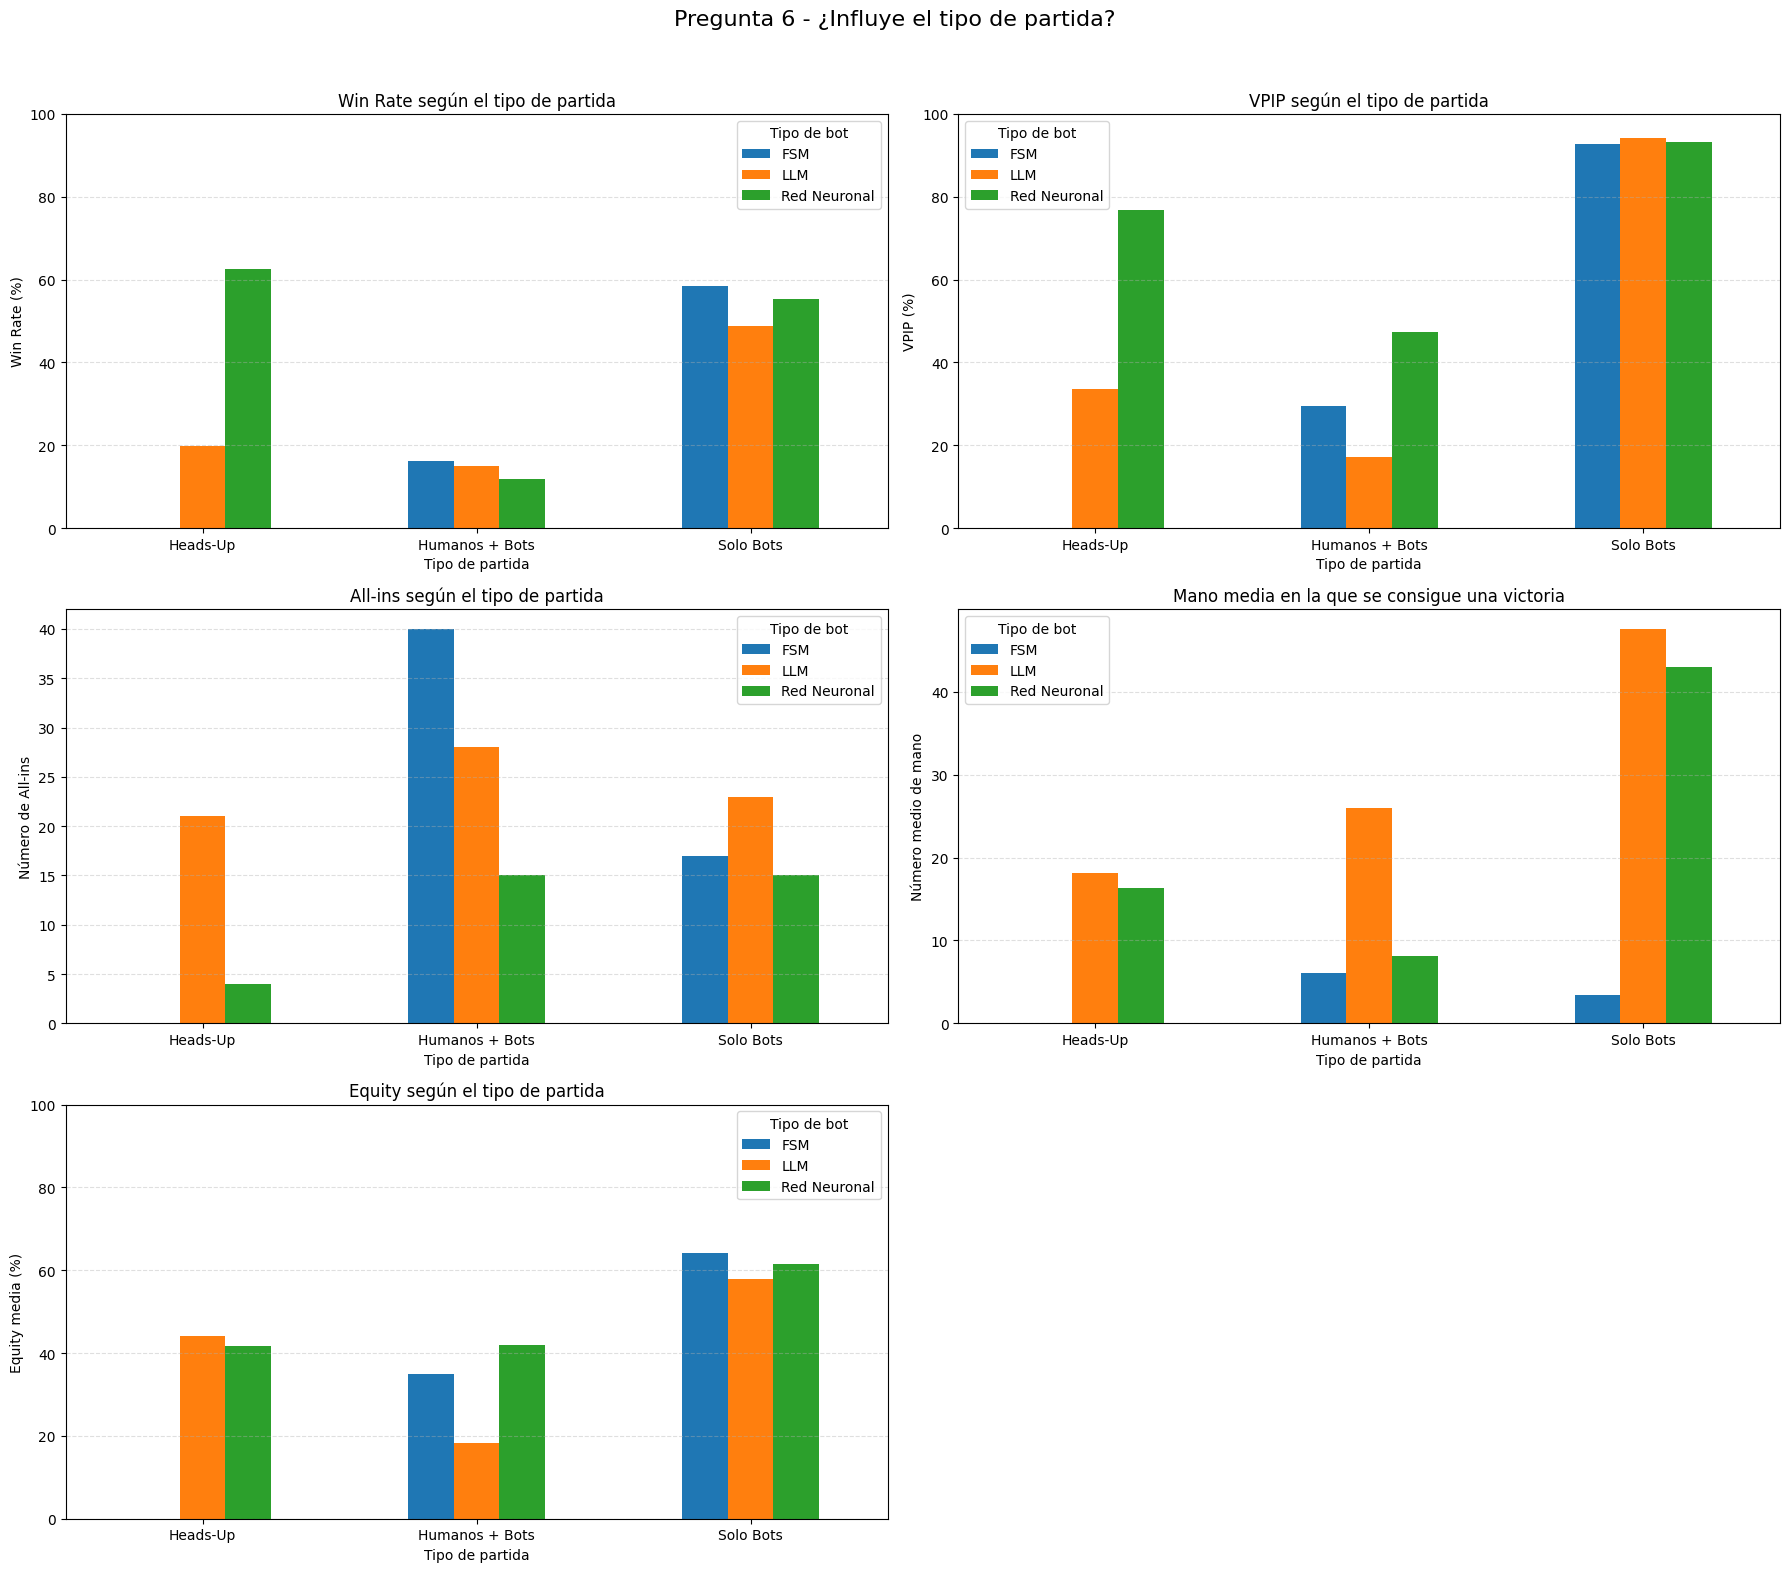

In [207]:
winrate_pregunta_6()
vpip_pregunta_6()
allins_pregunta_6()
manos_ganar_pregunta_6()
equity_pregunta_6()

completa_pregunta_6()

# Análisis específico

## Pregunta 7 - ¿Cómo cambia el bot frente a distintos niveles de jugador?
- Experimento: Humano vs Bot — Heads-Up .
- Comparar: Principiante vs Intermedio vs Profesional.
- Datos: Win Rate, chips, VPIP, PFR, AF, All-ins y equity.
- Gráficas: Barra + Lineas grafica combinada

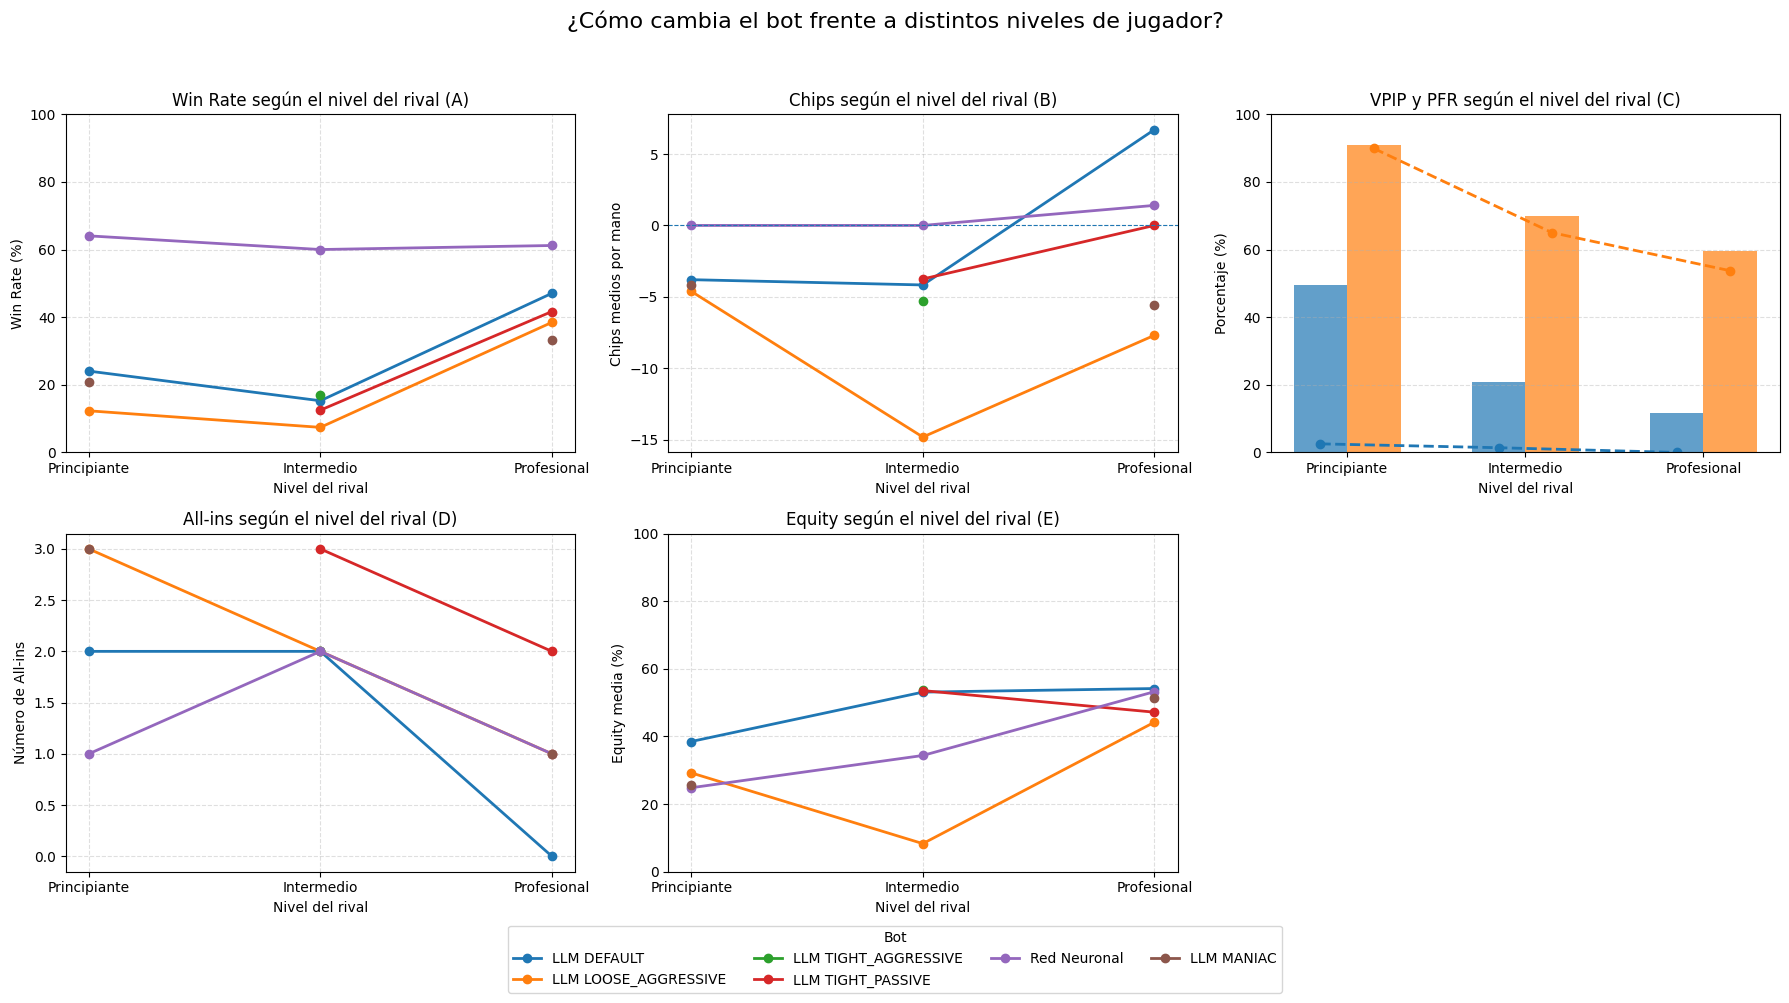

In [208]:
### ============================================================
### PREGUNTA 7 - ¿CÓMO CAMBIA EL BOT FRENTE A DISTINTOS
### NIVELES DE JUGADOR?
### ============================================================


# ============================================================
# CONFIGURACIÓN
# ============================================================

experimento_p7 = "1-bot_vs_1-humano"

variantes_p7 = {
    "Principiante": "1v1-novato",
    "Intermedio": "1v1-medio",
    "Profesional": "1v1-profesional"
}

nombres_tipos = {
    "BOT_LLM": "LLM",
    "BOT_NN": "Red Neuronal",
    "BOT_FSM": "FSM"
}

niveles_p7 = [
    "Principiante",
    "Intermedio",
    "Profesional"
]


# ============================================================
# PREPARAR LOS DATOS
# ============================================================

datos_p7_lista = []

for nivel, variante in variantes_p7.items():

    df = datos[experimento_p7][variante].copy()

    # Solo bots
    df = df[
        df['Type'] != 'HUMAN'
    ].copy()

    df['Nivel rival'] = nivel

    datos_p7_lista.append(df)


datos_p7 = pd.concat(
    datos_p7_lista,
    ignore_index=True
)


# ============================================================
# IDENTIFICAR BOT / ESTILO
# ============================================================

def nombre_bot_p7(fila):

    if fila['Type'] == 'BOT_LLM':
        return f"LLM {fila['Style']}"

    return nombres_tipos.get(
        fila['Type'],
        fila['Type']
    )


datos_p7['Bot'] = datos_p7.apply(
    nombre_bot_p7,
    axis=1
)


# ============================================================
# PREPARAR FIGURA 2 x 3
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()


# ============================================================
# 1. WIN RATE
# ============================================================

ax = axes[0]

winrate = (
    datos_p7
    .groupby(
        ['Nivel rival', 'Bot']
    )['Hand result']
    .apply(
        lambda x: (x == 'WON').mean() * 100
    )
    .reset_index(name='Win Rate')
)

for bot in winrate['Bot'].unique():

    datos_bot = winrate[
        winrate['Bot'] == bot
    ]

    datos_bot = datos_bot.set_index(
        'Nivel rival'
    ).reindex(
        niveles_p7
    )

    ax.plot(
        niveles_p7,
        datos_bot['Win Rate'],
        marker='o',
        linewidth=2,
        label=bot
    )

ax.set_title(
    'Win Rate según el nivel del rival (A)'
)

ax.set_xlabel(
    'Nivel del rival'
)

ax.set_ylabel(
    'Win Rate (%)'
)

ax.set_ylim(
    0,
    100
)

ax.grid(
    axis='both',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)


# ============================================================
# 2. CHIPS
# ============================================================

ax = axes[1]

datos_chips = datos_p7.copy()

datos_chips['Net chips'] = (
    datos_chips['Final stack']
    - datos_chips['Initial stack']
)

chips = (
    datos_chips
    .groupby(
        ['Nivel rival', 'Bot']
    )['Net chips']
    .mean()
    .reset_index(name='Chips medios')
)

for bot in chips['Bot'].unique():

    datos_bot = chips[
        chips['Bot'] == bot
    ]

    datos_bot = datos_bot.set_index(
        'Nivel rival'
    ).reindex(
        niveles_p7
    )

    ax.plot(
        niveles_p7,
        datos_bot['Chips medios'],
        marker='o',
        linewidth=2,
        label=bot
    )

ax.axhline(
    0,
    linestyle='--',
    linewidth=0.8
)

ax.set_title(
    'Chips según el nivel del rival (B)'
)

ax.set_xlabel(
    'Nivel del rival'
)

ax.set_ylabel(
    'Chips medios por mano'
)

ax.grid(
    axis='both',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)


# ============================================================
# 3. VPIP + PFR
# ============================================================

ax = axes[2]

comportamiento = (
    datos_p7
    .groupby(
        ['Nivel rival', 'Bot']
    )[['VPIP', 'PFR']]
    .mean()
    * 100
)

comportamiento = comportamiento.reset_index()


# Solo bots con comparación completa
bots_comparables = [
    'LLM DEFAULT',
    'Red Neuronal'
]

x = np.arange(
    len(niveles_p7)
)

ancho = 0.30


for i, bot in enumerate(
    bots_comparables
):

    datos_bot = comportamiento[
        comportamiento['Bot'] == bot
    ].set_index(
        'Nivel rival'
    )

    vpip = []
    pfr = []

    for nivel in niveles_p7:

        if nivel in datos_bot.index:

            vpip.append(
                datos_bot.loc[
                    nivel,
                    'VPIP'
                ]
            )

            pfr.append(
                datos_bot.loc[
                    nivel,
                    'PFR'
                ]
            )

        else:

            vpip.append(np.nan)
            pfr.append(np.nan)

    if i == 0:
        posicion = x - ancho / 2
    else:
        posicion = x + ancho / 2

    # VPIP -> barras
    ax.bar(
        posicion,
        vpip,
        width=ancho,
        alpha=0.7,
        label=f'{bot} - VPIP'
    )

    # PFR -> línea
    ax.plot(
        posicion,
        pfr,
        marker='o',
        linestyle='--',
        linewidth=2,
        label=f'{bot} - PFR'
    )


ax.set_title(
    'VPIP y PFR según el nivel del rival (C)'
)

ax.set_xlabel(
    'Nivel del rival'
)

ax.set_ylabel(
    'Porcentaje (%)'
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    niveles_p7
)

ax.set_ylim(
    0,
    100
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)


# ============================================================
# 4. ALL-INS
# ============================================================

ax = axes[3]

allins = (
    datos_p7
    .groupby(
        ['Nivel rival', 'Bot']
    )['AllIns']
    .sum()
    .reset_index(name='All-ins')
)

for bot in allins['Bot'].unique():

    datos_bot = allins[
        allins['Bot'] == bot
    ]

    datos_bot = datos_bot.set_index(
        'Nivel rival'
    ).reindex(
        niveles_p7
    )

    ax.plot(
        niveles_p7,
        datos_bot['All-ins'],
        marker='o',
        linewidth=2,
        label=bot
    )

ax.set_title(
    'All-ins según el nivel del rival (D)'
)

ax.set_xlabel(
    'Nivel del rival'
)

ax.set_ylabel(
    'Número de All-ins'
)

ax.grid(
    axis='both',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)


# ============================================================
# 5. EQUITY
# ============================================================

ax = axes[4]

equity_columnas = [
    'Preflop equity',
    'Flop equity',
    'Turn equity',
    'River equity'
]

datos_equity = datos_p7.copy()

# Los 0 representan calles sin equity disponible
datos_equity[equity_columnas] = (
    datos_equity[equity_columnas]
    .replace(0, np.nan)
)

# Equity media disponible durante la mano
datos_equity['Equity'] = (
    datos_equity[equity_columnas]
    .mean(axis=1)
)

equity = (
    datos_equity
    .groupby(
        ['Nivel rival', 'Bot']
    )['Equity']
    .mean()
    .reset_index()
)

for bot in equity['Bot'].unique():

    datos_bot = equity[
        equity['Bot'] == bot
    ]

    datos_bot = datos_bot.set_index(
        'Nivel rival'
    ).reindex(
        niveles_p7
    )

    ax.plot(
        niveles_p7,
        datos_bot['Equity'],
        marker='o',
        linewidth=2,
        label=bot
    )

ax.set_title(
    'Equity según el nivel del rival (E)'
)

ax.set_xlabel(
    'Nivel del rival'
)

ax.set_ylabel(
    'Equity media (%)'
)

ax.set_ylim(
    0,
    100
)

ax.grid(
    axis='both',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)


# ============================================================
# 6. ESPACIO VACÍO
# ============================================================

axes[5].axis('off')


# ============================================================
# LEYENDA GENERAL
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Bot',
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.01)
)


# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(
    '¿Cómo cambia el bot frente a distintos niveles de jugador?',
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)


# ============================================================
# GUARDAR
# ============================================================

plt.savefig(
    OUTPUT_DIR / "pregunta_7_completa.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Pregunta 8 - ¿Cómo se comportan los bots en una mesa con humanos?
- Experimento: 2 humanos principiantes + Gemini + Ollama + NN + FSM.
- Datos: Evolución del stack, Win Rate, VPIP, AF y eliminaciones.
- Gráficas: Líneas + Barras apiladas.

In [209]:
### ============================================================
### PREGUNTA 8 - ¿CÓMO SE COMPORTAN LOS BOTS EN UNA MESA
### CON HUMANOS?
### ============================================================


# ============================================================
# CONFIGURACIÓN
# ============================================================

experimento_p8 = "1-humano_vs_4-bots"

variantes_p8 = {
    "Humano_A": "Humano_A",
    "Humano_B": "Humano_B"
}


# ============================================================
# PREPARAR DATOS
# ============================================================
def preparar_pregunta_8(variante):

    df = datos[experimento_p8][variante].copy()

    # --------------------------------------------------------
    # Identificar cada jugador sin utilizar su nombre real
    # --------------------------------------------------------

    nombre_humano = variante.replace("_", " ")

    def identificar_jugador(fila):

        if fila['Type'] == 'HUMAN':
            return nombre_humano

        elif fila['Type'] == 'BOT_LLM':
            return "LLM"

        elif fila['Type'] == 'BOT_NN':
            return "Red Neuronal"

        elif fila['Type'] == 'BOT_FSM':
            return "FSM"

        return fila['Type']


    # --------------------------------------------------------
    # Identificar Humano A / Humano B
    # --------------------------------------------------------
    df['Jugador'] = df.apply(
        identificar_jugador,
        axis=1
    )

    # --------------------------------------------------------
    # Chips ganadas/perdidas
    # --------------------------------------------------------
    df['Net chips'] = (
        df['Final stack']
        - df['Initial stack']
    )

    return df


# ============================================================
# 1. EVOLUCIÓN DEL STACK
# ============================================================
def stack_pregunta_8(variante, nombre_escenario):

    print(f"Nombre: {nombre_escenario}")
    df = preparar_pregunta_8(variante)

    stack = (
        df
        .groupby(
            ['Hand', 'Jugador']
        )['Final stack']
        .mean()
        .reset_index()
    )

    orden = [
        nombre_escenario.replace("_", " "),
        "LLM",
        "Red Neuronal",
        "FSM"
    ]

    plt.figure(figsize=(10, 5))

    print(stack['Jugador'])
    for jugador in orden:

        datos_jugador = stack[
            stack['Jugador'] == jugador
        ]

        if len(datos_jugador) == 0:
            continue

        plt.plot(
            datos_jugador['Hand'],
            datos_jugador['Final stack'],
            marker='o',
            linewidth=2,
            label=jugador
        )

    plt.xlabel('Número de mano')
    plt.ylabel('Stack')
    plt.title(
        f'Evolución del stack - {nombre_escenario} (A)'
    )

    plt.legend(
        title='Jugador'
    )

    plt.grid(
        axis='both',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pregunta_8_{variante.lower()}_stack.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 2. WIN RATE
# ============================================================
def winrate_pregunta_8(variante, nombre_escenario):

    df = preparar_pregunta_8(variante)

    winrate = (
        df
        .groupby('Jugador')['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
    )

    orden = [
        "Humano A",
        "Humano B",
        "LLM",
        "Red Neuronal",
        "FSM"
    ]

    winrate = winrate.reindex(
        orden
    ).dropna()

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        winrate.index,
        winrate.values
    )

    plt.xlabel('Jugador')
    plt.ylabel('Win Rate (%)')

    plt.title(
        f'Win Rate - {nombre_escenario} (B)'
    )

    plt.ylim(
        0,
        100
    )

    for bar in bars:

        altura = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            altura,
            f'{altura:.1f}%',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pregunta_8_{variante.lower()}_winrate.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 3. VPIP
# ============================================================
def vpip_pregunta_8(variante, nombre_escenario):

    df = preparar_pregunta_8(variante)

    vpip = (
        df
        .groupby('Jugador')['VPIP']
        .mean()
        * 100
    )

    orden = [
        "Humano A",
        "Humano B",
        "LLM",
        "Red Neuronal",
        "FSM"
    ]

    vpip = vpip.reindex(
        orden
    ).dropna()

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        vpip.index,
        vpip.values
    )

    plt.xlabel('Jugador')
    plt.ylabel('VPIP (%)')

    plt.title(
        f'VPIP - {nombre_escenario} (C)'
    )

    plt.ylim(
        0,
        100
    )

    for bar in bars:

        altura = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            altura,
            f'{altura:.1f}%',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pregunta_8_{variante.lower()}_vpip.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 4. ALL-INS
# ============================================================
def allins_pregunta_8(variante, nombre_escenario):

    df = preparar_pregunta_8(variante)

    allins = (
        df
        .groupby('Jugador')['AllIns']
        .sum()
    )

    orden = [
        nombre_escenario.replace("_", " "),
        "LLM",
        "Red Neuronal",
        "FSM"
    ]

    allins = allins.reindex(
        orden
    ).fillna(0)

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        allins.index,
        allins.values
    )

    plt.xlabel('Jugador')
    plt.ylabel('Número de All-ins')

    plt.title(
        f'All-ins - {nombre_escenario} (D)'
    )

    for bar in bars:

        altura = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            altura,
            f'{int(altura)}',
            ha='center',
            va='bottom'
        )

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pregunta_8_{variante.lower()}_allins.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 5. TODAS LAS GRÁFICAS JUNTAS
# ============================================================
def completa_pregunta_8(variante, nombre_escenario):

    df = preparar_pregunta_8(variante)

    orden = [
        "Humano A",
        "Humano B",
        "LLM",
        "Red Neuronal",
        "FSM"
    ]


    # ========================================================
    # DATOS
    # ========================================================

    stack = (
        df
        .groupby(
            ['Hand', 'Jugador']
        )['Final stack']
        .mean()
        .reset_index()
    )

    winrate = (
        df
        .groupby('Jugador')['Hand result']
        .apply(
            lambda x: (
                x == 'WON'
            ).mean() * 100
        )
        .reindex(orden)
    )

    vpip = (
        df
        .groupby('Jugador')['VPIP']
        .mean()
        .reindex(orden)
        * 100
    )

    allins = (
        df
        .groupby('Jugador')['AllIns']
        .sum()
        .reindex(orden)
        .fillna(0)
    )


    # ========================================================
    # FIGURA
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 9)
    )

    axes = axes.flatten()


    # ========================================================
    # STACK
    # ========================================================

    ax = axes[0]

    for jugador in orden:

        datos_jugador = stack[
            stack['Jugador'] == jugador
        ]

        if len(datos_jugador) == 0:
            continue

        ax.plot(
            datos_jugador['Hand'],
            datos_jugador['Final stack'],
            marker='o',
            linewidth=2,
            label=jugador
        )

    ax.set_title(
        'Evolución del stack'
    )

    ax.set_xlabel(
        'Número de mano'
    )

    ax.set_ylabel(
        'Stack'
    )

    ax.grid(
        axis='both',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # WIN RATE
    # ========================================================

    ax = axes[1]

    ax.bar(
        winrate.dropna().index,
        winrate.dropna().values
    )

    ax.set_title(
        'Win Rate'
    )

    ax.set_xlabel(
        'Jugador'
    )

    ax.set_ylabel(
        'Win Rate (%)'
    )

    ax.set_ylim(
        0,
        100
    )

    ax.tick_params(
        axis='x',
        rotation=15
    )

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # VPIP
    # ========================================================

    ax = axes[2]

    ax.bar(
        vpip.dropna().index,
        vpip.dropna().values
    )

    ax.set_title(
        'VPIP'
    )

    ax.set_xlabel(
        'Jugador'
    )

    ax.set_ylabel(
        'VPIP (%)'
    )

    ax.set_ylim(
        0,
        100
    )

    ax.tick_params(
        axis='x',
        rotation=15
    )

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # ALL-INS
    # ========================================================

    ax = axes[3]

    ax.bar(
        allins.index,
        allins.values
    )

    ax.set_title(
        'All-ins'
    )

    ax.set_xlabel(
        'Jugador'
    )

    ax.set_ylabel(
        'Número de All-ins'
    )

    ax.tick_params(
        axis='x',
        rotation=15
    )

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        f'Comportamiento en mesa con humanos - {nombre_escenario}',
        fontsize=15
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.95
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / f"pregunta_8_{variante.lower()}_completa.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


Nombre: Humano_A
0               FSM
1          Humano A
2               LLM
3      Red Neuronal
4               FSM
           ...     
219    Red Neuronal
220             FSM
221        Humano A
222             LLM
223    Red Neuronal
Name: Jugador, Length: 224, dtype: str


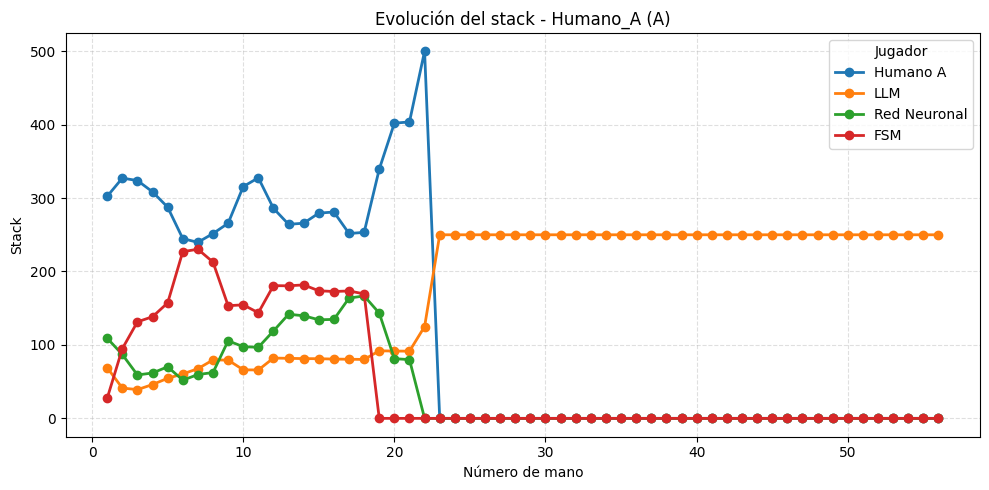

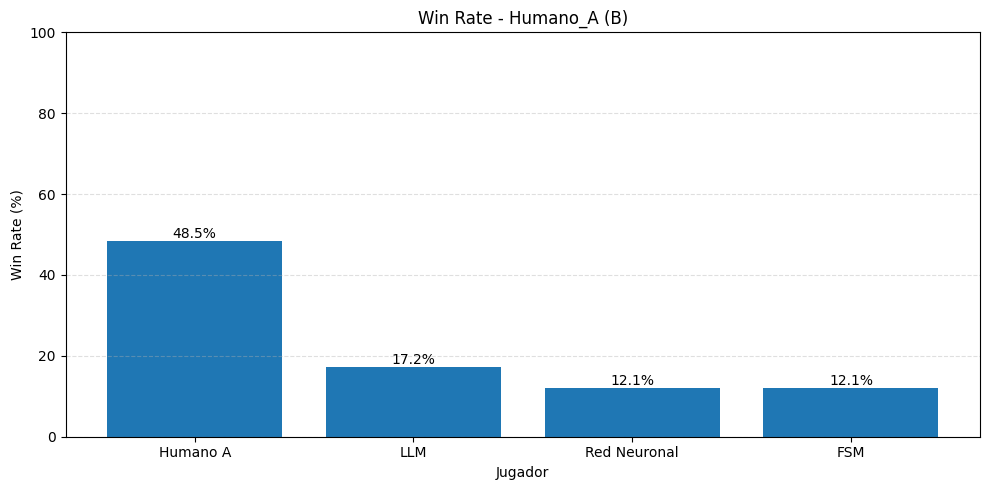

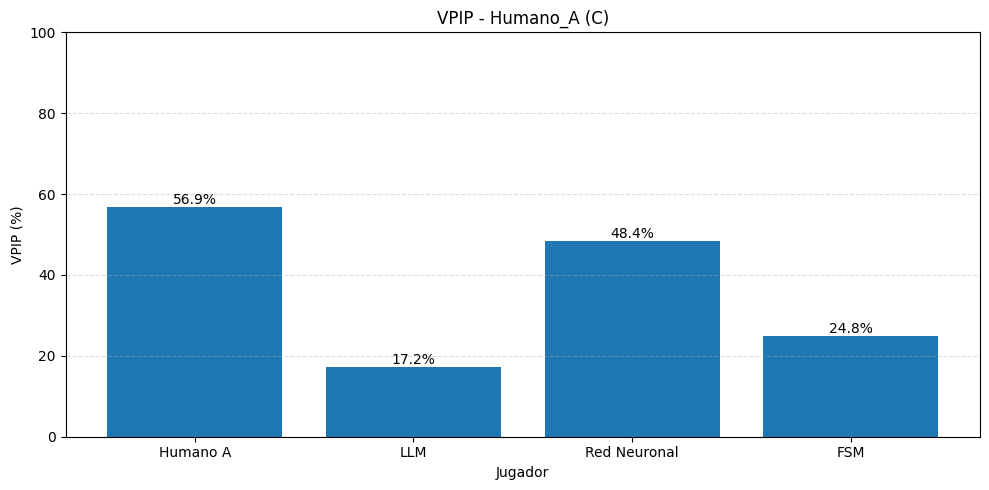

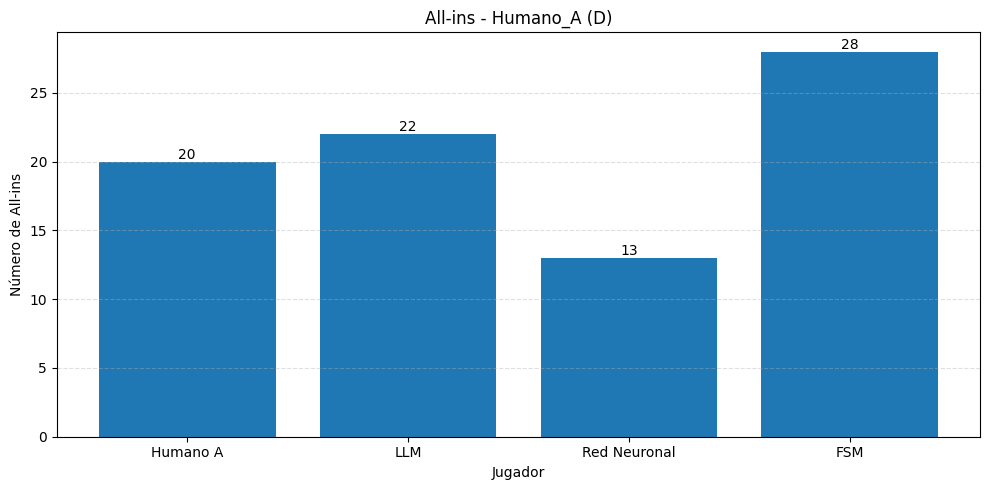

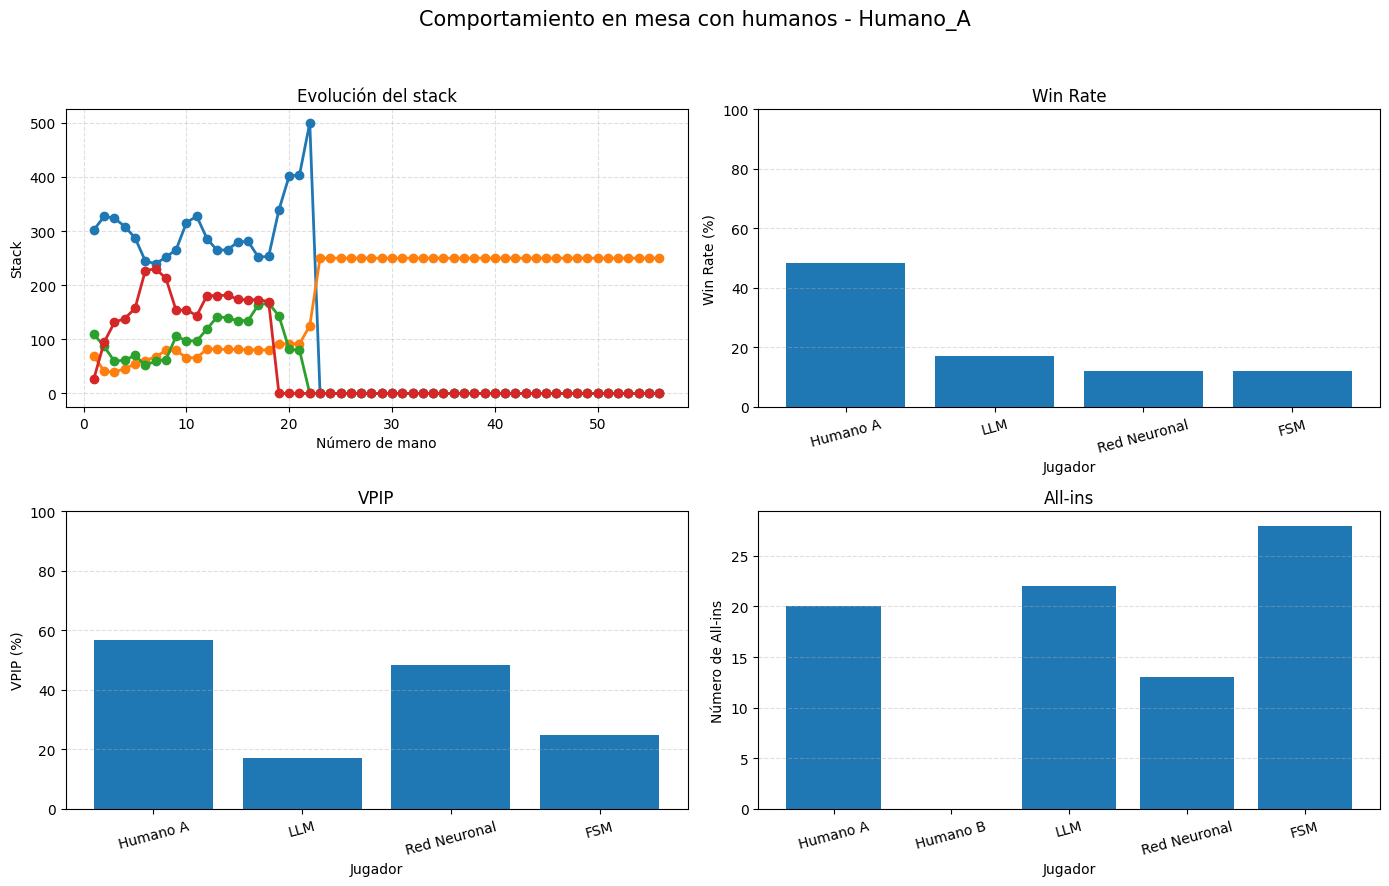

Nombre: Humano_B
0              FSM
1         Humano B
2              LLM
3     Red Neuronal
4              FSM
          ...     
63    Red Neuronal
64             FSM
65        Humano B
66             LLM
67    Red Neuronal
Name: Jugador, Length: 68, dtype: str


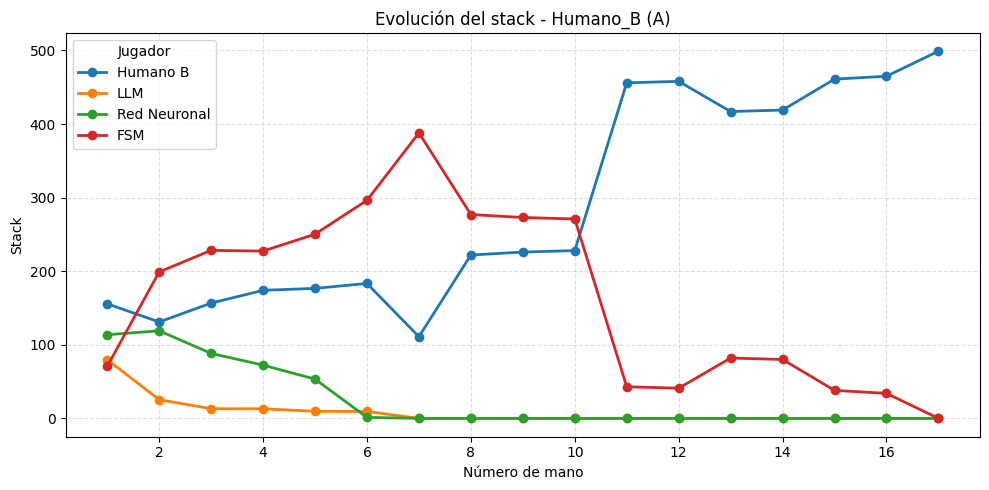

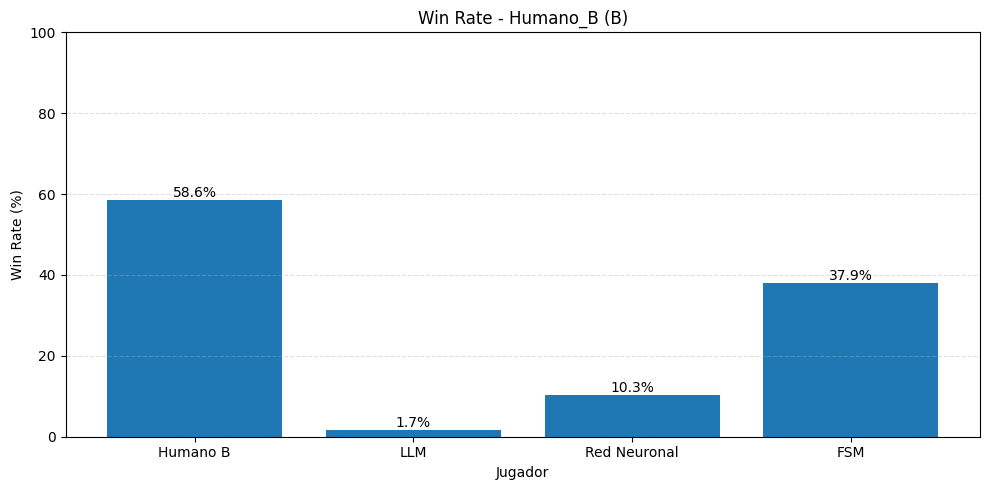

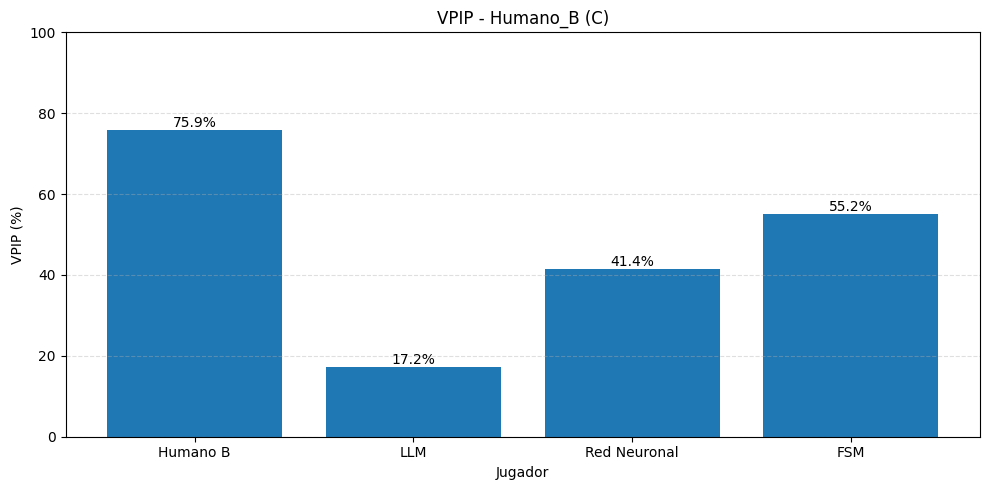

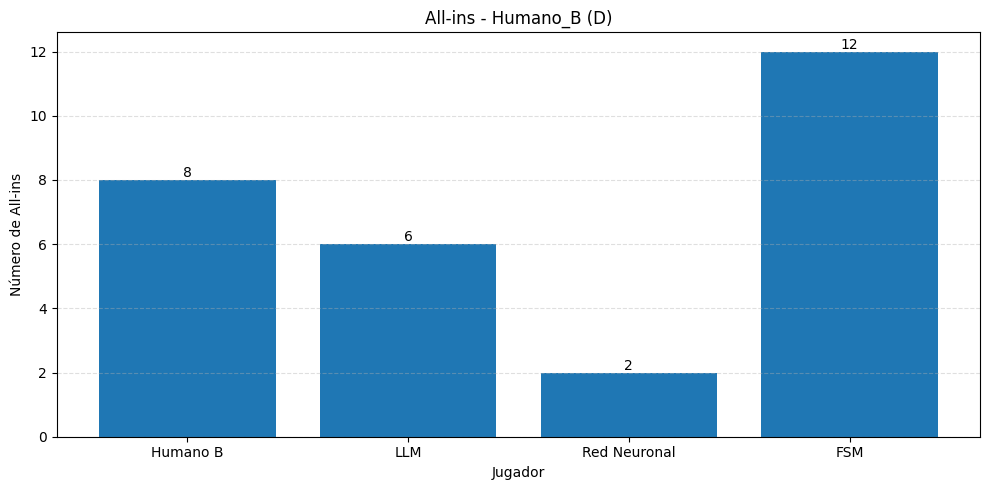

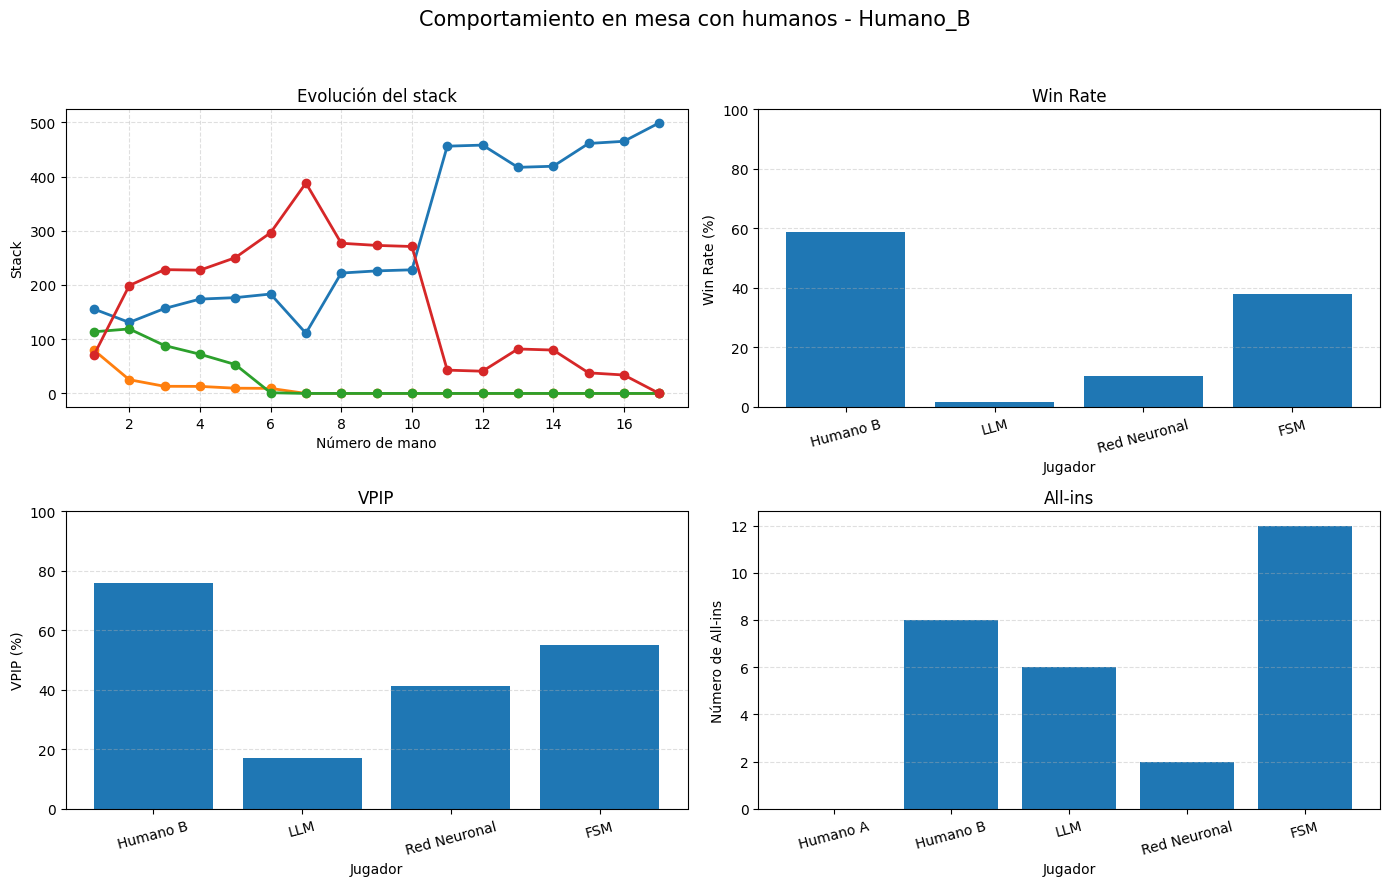

In [210]:
for nombre_escenario, variante in variantes_p8.items():

    stack_pregunta_8(
        variante,
        nombre_escenario
    )

    winrate_pregunta_8(
        variante,
        nombre_escenario
    )

    vpip_pregunta_8(
        variante,
        nombre_escenario
    )

    allins_pregunta_8(
        variante,
        nombre_escenario
    )

    completa_pregunta_8(
        variante,
        nombre_escenario
    )

## Pregunta 9 - ¿Los estilos realmente cambian el comportamiento del mismo modelo?
- Experimento: 6 Ollama con estilos mixtos.
- Comparar: DEFAULT, TP, TAG, LP, LAG y MANIAC.
- Datos: VPIP, PFR, 3Bet, AF, Win Rate, chips y All-ins.
- Gráficas: Radar

In [211]:
### ============================================================
### PREGUNTA 9 - ¿LOS ESTILOS REALMENTE CAMBIAN EL
### COMPORTAMIENTO DEL MISMO MODELO?
### ============================================================


# ============================================================
# CONFIGURACIÓN
# ============================================================

experimento_p9 = "6-bots"
variante_p9 = "6-mixed"

nombres_estilos_p9 = {
    "DEFAULT": "DEFAULT",
    "TIGHT_PASSIVE": "TP",
    "TIGHT_AGGRESSIVE": "TAG",
    "LOOSE_PASSIVE": "LP",
    "LOOSE_AGGRESSIVE": "LAG",
    "MANIAC": "MANIAC"
}

orden_estilos_p9 = [
    "DEFAULT",
    "TP",
    "TAG",
    "LP",
    "LAG",
    "MANIAC"
]


# ============================================================
# PREPARAR DATOS
# ============================================================

def preparar_pregunta_9():

    df = datos[
        experimento_p9
    ][variante_p9].copy()

    # Solo bots LLM
    df = df[
        df['Type'] == 'BOT_LLM'
    ].copy()

    # Nombre corto del estilo
    df['Estilo'] = (
        df['Style']
        .map(nombres_estilos_p9)
        .fillna(df['Style'])
    )

    # Chips netas
    df['Net chips'] = (
        df['Final stack']
        - df['Initial stack']
    )

    return df


datos_p9 = preparar_pregunta_9()


# ============================================================
# 1. COMPORTAMIENTO
# VPIP + PFR + 3Bet
# ============================================================
def comportamiento_pregunta_9():

    comportamiento = (
        datos_p9
        .groupby('Estilo')
        .agg(
            VPIP=('VPIP', 'mean'),
            PFR=('PFR', 'mean'),
            ThreeBet=('3Bet', 'mean')
        )
        .reindex(
            orden_estilos_p9
        )
    )

    # Convertir a porcentaje
    comportamiento[
        ['VPIP', 'PFR', 'ThreeBet']
    ] *= 100

    x = np.arange(
        len(orden_estilos_p9)
    )

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    ancho = 0.25

    # VPIP
    ax.bar(
        x - ancho,
        comportamiento['VPIP'],
        width=ancho,
        label='VPIP'
    )

    # PFR
    ax.bar(
        x,
        comportamiento['PFR'],
        width=ancho,
        label='PFR'
    )

    # 3Bet
    ax.bar(
        x + ancho,
        comportamiento['ThreeBet'],
        width=ancho,
        label='3Bet'
    )

    ax.set_xlabel(
        'Estilo'
    )

    ax.set_ylabel(
        'Porcentaje (%)'
    )

    ax.set_title(
        'Comportamiento según el estilo'
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        orden_estilos_p9
    )

    ax.set_ylim(
        0,
        100
    )

    ax.legend(
        title='Métrica'
    )

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_9_comportamiento.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 2. RESULTADOS
# Win Rate + Chips + All-ins
# ============================================================
def resultados_pregunta_9():

    resultados = (
        datos_p9
        .groupby('Estilo')
        .agg(
            Win_Rate=(
                'Hand result',
                lambda x: (
                    x == 'WON'
                ).mean() * 100
            ),

            Chips=(
                'Net chips',
                'mean'
            ),

            All_ins=(
                'AllIns',
                'sum'
            )
        )
        .reindex(
            orden_estilos_p9
        )
    )

    x = np.arange(
        len(orden_estilos_p9)
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 6)
    )

    # --------------------------------------------------------
    # WIN RATE
    # --------------------------------------------------------

    axes[0].bar(
        x,
        resultados['Win_Rate'],
        width=0.6
    )

    axes[0].set_title(
        'Win Rate (B)'
    )

    axes[0].set_xlabel(
        'Estilo'
    )

    axes[0].set_ylabel(
        'Win Rate (%)'
    )

    axes[0].set_ylim(
        0,
        100
    )

    axes[0].set_xticks(
        x
    )

    axes[0].set_xticklabels(
        orden_estilos_p9
    )

    axes[0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # --------------------------------------------------------
    # CHIPS
    # --------------------------------------------------------

    axes[1].bar(
        x,
        resultados['Chips'],
        width=0.6
    )

    axes[1].set_title(
        'Chips (C)'
    )

    axes[1].set_xlabel(
        'Estilo'
    )

    axes[1].set_ylabel(
        'Chips medios por mano'
    )

    axes[1].set_xticks(
        x
    )

    axes[1].set_xticklabels(
        orden_estilos_p9
    )

    axes[1].axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )

    axes[1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # --------------------------------------------------------
    # ALL-INS
    # --------------------------------------------------------

    axes[2].bar(
        x,
        resultados['All_ins'],
        width=0.6
    )

    axes[2].set_title(
        'All-ins (D)'
    )

    axes[2].set_xlabel(
        'Estilo'
    )

    axes[2].set_ylabel(
        'Número de All-ins'
    )

    axes[2].set_xticks(
        x
    )

    axes[2].set_xticklabels(
        orden_estilos_p9
    )

    axes[2].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )

    fig.suptitle(
        'Resultados según el estilo',
        fontsize=16
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_9_resultados.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# ============================================================
# 3. TODAS JUNTAS
# ============================================================
def completa_pregunta_9():

    # --------------------------------------------------------
    # DATOS DE COMPORTAMIENTO
    # --------------------------------------------------------

    comportamiento = (
        datos_p9
        .groupby('Estilo')
        .agg(
            VPIP=('VPIP', 'mean'),
            PFR=('PFR', 'mean'),
            ThreeBet=('3Bet', 'mean')
        )
        .reindex(
            orden_estilos_p9
        )
    )

    comportamiento[
        ['VPIP', 'PFR', 'ThreeBet']
    ] *= 100


    # --------------------------------------------------------
    # DATOS DE RESULTADOS
    # --------------------------------------------------------

    resultados = (
        datos_p9
        .groupby('Estilo')
        .agg(
            Win_Rate=(
                'Hand result',
                lambda x: (
                    x == 'WON'
                ).mean() * 100
            ),

            Chips=(
                'Net chips',
                'mean'
            ),

            All_ins=(
                'AllIns',
                'sum'
            )
        )
        .reindex(
            orden_estilos_p9
        )
    )


    # ========================================================
    # FIGURA 2x2
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10)
    )

    x = np.arange(
        len(orden_estilos_p9)
    )

    ancho = 0.25


    # ========================================================
    # VPIP / PFR / 3BET
    # ========================================================

    axes[0, 0].bar(
        x - ancho,
        comportamiento['VPIP'],
        width=ancho,
        label='VPIP'
    )

    axes[0, 0].bar(
        x,
        comportamiento['PFR'],
        width=ancho,
        label='PFR'
    )

    axes[0, 0].bar(
        x + ancho,
        comportamiento['ThreeBet'],
        width=ancho,
        label='3Bet'
    )

    axes[0, 0].set_title(
        'VPIP, PFR y 3Bet (A)'
    )

    axes[0, 0].set_ylabel(
        'Porcentaje (%)'
    )

    axes[0, 0].set_ylim(
        0,
        100
    )

    axes[0, 0].set_xticks(
        x
    )

    axes[0, 0].set_xticklabels(
        orden_estilos_p9
    )

    axes[0, 0].legend()

    axes[0, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # WIN RATE
    # ========================================================

    axes[0, 1].bar(
        x,
        resultados['Win_Rate'],
        width=0.6
    )

    axes[0, 1].set_title(
        'Win Rate (B)'
    )

    axes[0, 1].set_ylabel(
        'Win Rate (%)'
    )

    axes[0, 1].set_ylim(
        0,
        100
    )

    axes[0, 1].set_xticks(
        x
    )

    axes[0, 1].set_xticklabels(
        orden_estilos_p9
    )

    axes[0, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # CHIPS
    # ========================================================

    axes[1, 0].bar(
        x,
        resultados['Chips'],
        width=0.6
    )

    axes[1, 0].set_title(
        'Chips (C)'
    )

    axes[1, 0].set_ylabel(
        'Chips medios por mano'
    )

    axes[1, 0].set_xlabel(
        'Estilo'
    )

    axes[1, 0].set_xticks(
        x
    )

    axes[1, 0].set_xticklabels(
        orden_estilos_p9
    )

    axes[1, 0].axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )

    axes[1, 0].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # ALL-INS
    # ========================================================

    axes[1, 1].bar(
        x,
        resultados['All_ins'],
        width=0.6
    )

    axes[1, 1].set_title(
        'All-ins (D)'
    )

    axes[1, 1].set_ylabel(
        'Número de All-ins'
    )

    axes[1, 1].set_xlabel(
        'Estilo'
    )

    axes[1, 1].set_xticks(
        x
    )

    axes[1, 1].set_xticklabels(
        orden_estilos_p9
    )

    axes[1, 1].grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Diferencias entre estilos del mismo modelo',
        fontsize=16
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.95
        ]
    )

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_9_completa.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

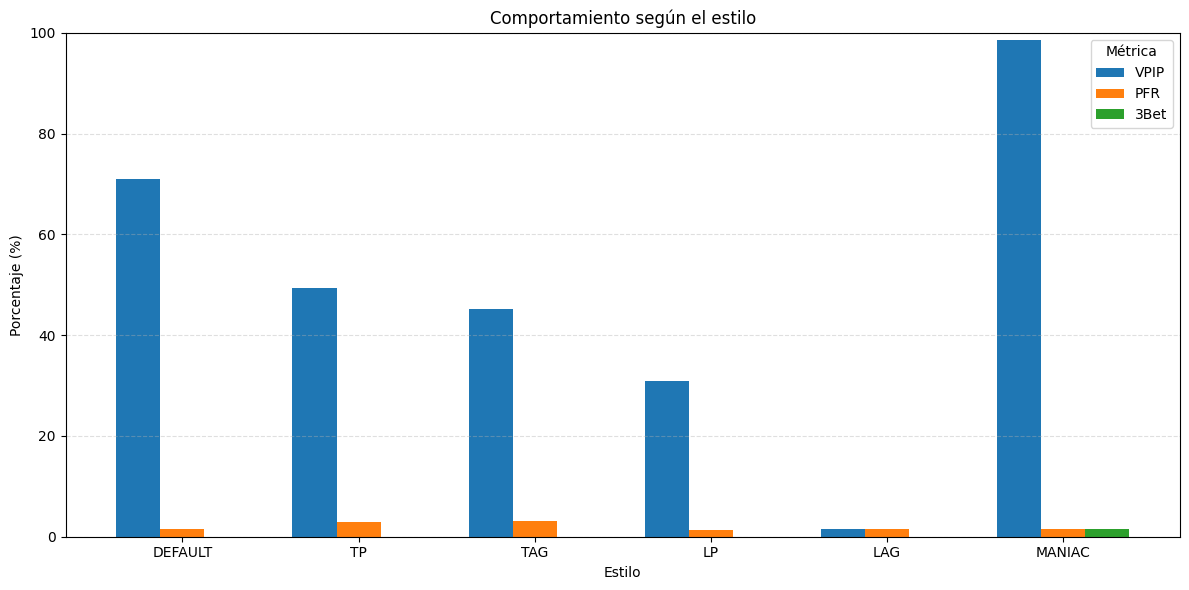

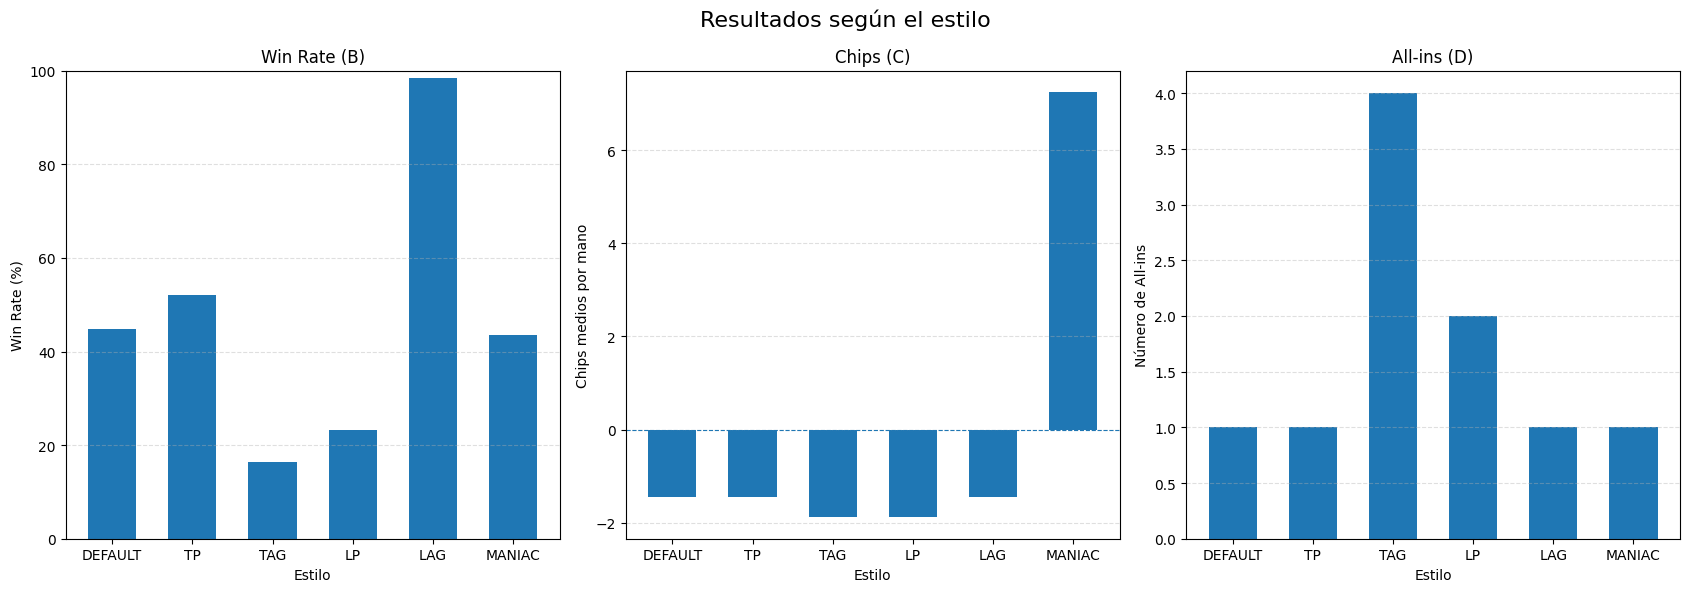

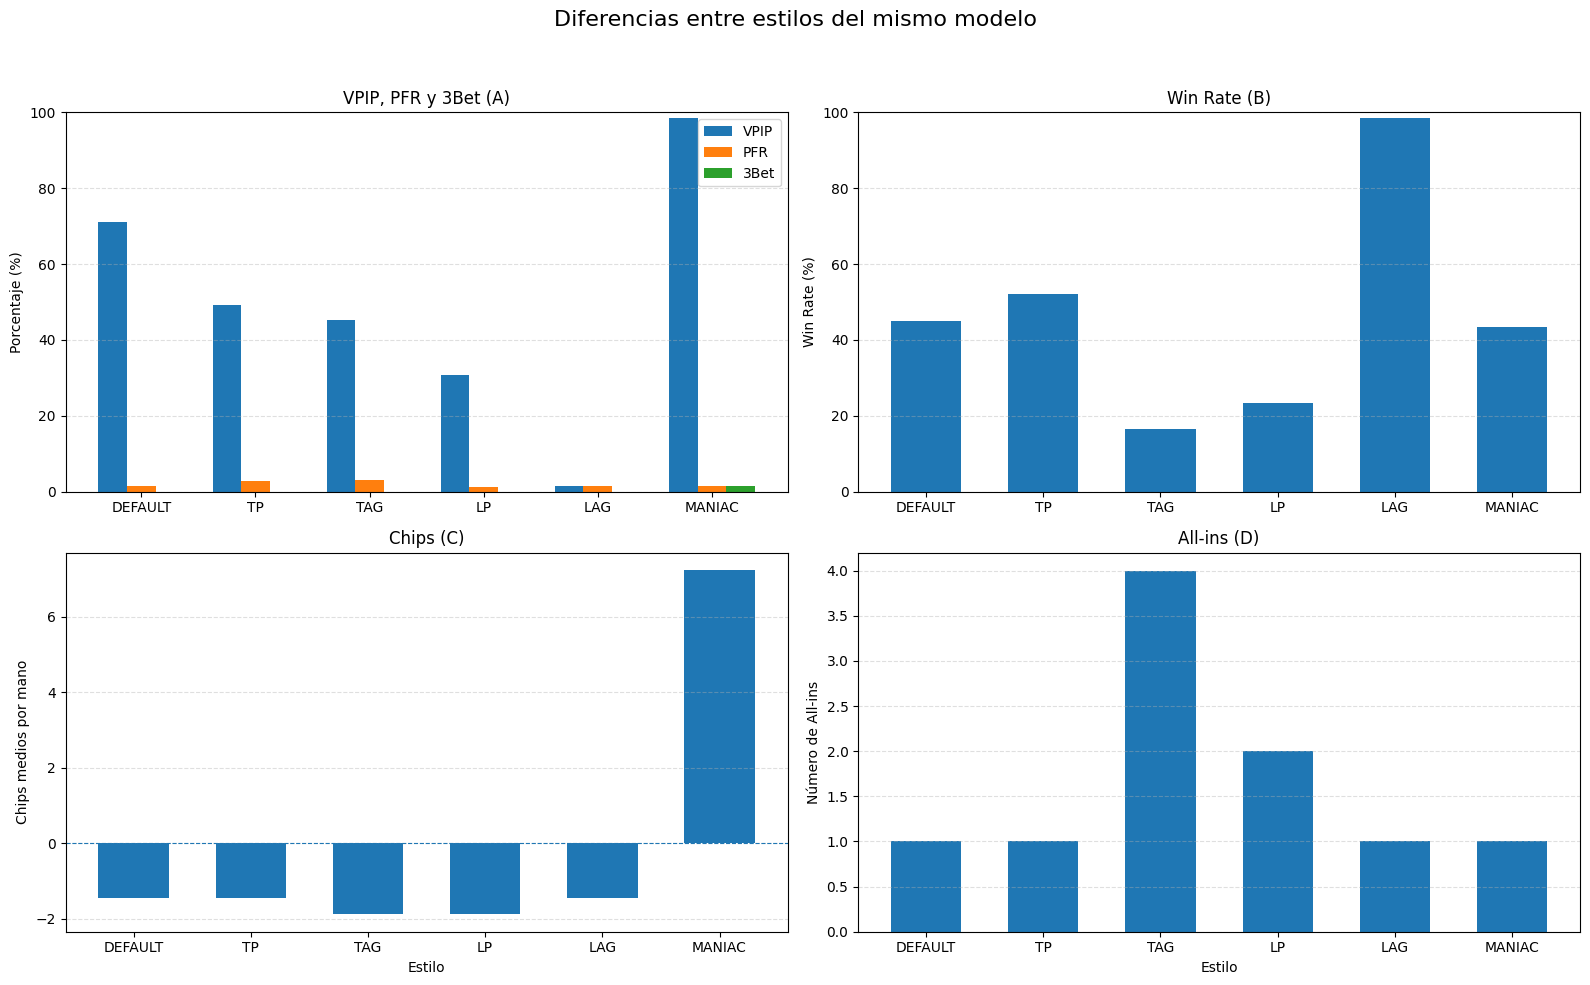

In [212]:
### ============================================================
### EJECUTAR PREGUNTA 9
### ============================================================

comportamiento_pregunta_9()

resultados_pregunta_9()

completa_pregunta_9()

## Pregunta 10 - ¿Cómo compite el LLM contra NN y FSM?
- Experimento: Bot vs Bot.
- Comparar: Ollama DEFAULT, TP y LAG frente a NN/FSM.
- Datos: Win Rate, chips, equity, AF y All-ins.
- Gráficas: Heatmap + Barras.

In [213]:
# ============================================================
# PREGUNTA 10 - ¿CÓMO COMPITE EL LLM CONTRA NN Y FSM?
# SOLO BOT VS BOT
# ============================================================


# ============================================================
# CONFIGURACIÓN
# ============================================================

experimento_p10 = "1-bot_vs_1-bot"

nombres_tipos_p10 = {
    "BOT_LLM": "LLM",
    "BOT_NN": "Red Neuronal",
    "BOT_FSM": "FSM"
}

orden_bots_p10 = [
    "LLM",
    "Red Neuronal",
    "FSM"
]


# ============================================================
# PREPARAR DATOS
# ============================================================

datos_p10_lista = []


for variante, df in datos[
    experimento_p10
].items():

    df_temp = df.copy()

    # --------------------------------------------------------
    # SOLO BOT VS BOT
    # --------------------------------------------------------

    df_temp = df_temp[
        df_temp['Type'].isin(
            nombres_tipos_p10.keys()
        )
    ].copy()


    # --------------------------------------------------------
    # IDENTIFICAR EL TIPO DE BOT
    # --------------------------------------------------------
    #
    # IMPORTANTE:
    # Se utiliza únicamente Type.
    #
    # No se utiliza Style.
    #
    # Los únicos bots serán:
    #
    # LLM
    # Red Neuronal
    # FSM
    # --------------------------------------------------------

    df_temp['Bot'] = (
        df_temp['Type']
        .map(nombres_tipos_p10)
    )


    # --------------------------------------------------------
    # Guardar variante internamente
    # --------------------------------------------------------
    #
    # Se conserva por si se necesita posteriormente,
    # pero NO se utilizará para identificar el bot.
    # --------------------------------------------------------

    df_temp['Variante'] = variante


    datos_p10_lista.append(
        df_temp
    )


datos_p10 = pd.concat(
    datos_p10_lista,
    ignore_index=True
)


# ============================================================
# COMPROBACIÓN
# ============================================================

print(
    "Tipos de bot encontrados:"
)

print(
    datos_p10['Bot'].unique()
)


# ============================================================
# PREPARAR EQUITY
# ============================================================

equity_columnas_p10 = [
    'Preflop equity',
    'Flop equity',
    'Turn equity',
    'River equity'
]


datos_equity_p10 = datos_p10.copy()


# Los 0 representan calles sin equity disponible
datos_equity_p10[
    equity_columnas_p10
] = (
    datos_equity_p10[
        equity_columnas_p10
    ]
    .replace(0, np.nan)
)


# ------------------------------------------------------------
# Equity representativa de cada mano
# ------------------------------------------------------------
#
# Se utiliza la última equity disponible.
# ------------------------------------------------------------

datos_equity_p10['Equity'] = (
    datos_equity_p10[
        equity_columnas_p10
    ]
    .ffill(axis=1)
    .iloc[:, -1]
)


# ------------------------------------------------------------
# Net chips
# ------------------------------------------------------------

datos_equity_p10['Net chips'] = (
    datos_equity_p10['Final stack']
    -
    datos_equity_p10['Initial stack']
)


# ============================================================
# 1. HEATMAP - WIN RATE
# ============================================================
#
# IMPORTANTE:
# Aquí NO utilizamos Variante.
#
# Solo:
# LLM
# Red Neuronal
# FSM
# ============================================================
def heatmap_pregunta_10():

    # --------------------------------------------------------
    # Win Rate por tipo de bot
    # --------------------------------------------------------

    winrate = (
        datos_p10
        .groupby('Bot')['Hand result']
        .apply(
            lambda x:
            (x == 'WON').mean() * 100
        )
        .reindex(
            orden_bots_p10
        )
    )


    # --------------------------------------------------------
    # Convertir a matriz
    # --------------------------------------------------------

    matriz = winrate.values.reshape(
        -1,
        1
    )


    # --------------------------------------------------------
    # Crear figura
    # --------------------------------------------------------

    plt.figure(
        figsize=(6, 5)
    )


    imagen = plt.imshow(
        matriz,
        aspect='auto',
        vmin=0,
        vmax=100
    )


    # --------------------------------------------------------
    # EJE X
    # --------------------------------------------------------

    plt.xticks(
        [0],
        ['Bot vs Bot']
    )


    # --------------------------------------------------------
    # EJE Y
    # --------------------------------------------------------

    plt.yticks(
        np.arange(
            len(orden_bots_p10)
        ),
        orden_bots_p10
    )


    # --------------------------------------------------------
    # VALORES DENTRO DE LAS CELDAS
    # --------------------------------------------------------

    for i in range(
        len(orden_bots_p10)
    ):

        valor = matriz[i, 0]

        if not np.isnan(valor):

            plt.text(
                0,
                i,
                f'{valor:.1f}%',
                ha='center',
                va='center'
            )


    # --------------------------------------------------------
    # BARRA DE COLOR
    # --------------------------------------------------------

    cbar = plt.colorbar(
        imagen
    )

    cbar.set_label(
        'Win Rate (%)'
    )


    # --------------------------------------------------------
    # ETIQUETAS
    # --------------------------------------------------------

    plt.xlabel(
        'Tipo de partida'
    )

    plt.ylabel(
        'Tipo de bot'
    )

    plt.title('Win Rate de cada tipo de bot (A)')


    plt.tight_layout()


    # --------------------------------------------------------
    # GUARDAR
    # --------------------------------------------------------

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_10_heatmap.png",
        dpi=300,
        bbox_inches='tight'
    )


    plt.show()


# ============================================================
# 2. CHIPS
# ============================================================
def chips_pregunta_10():

    chips = (
        datos_equity_p10
        .groupby('Bot')['Net chips']
        .mean()
        .reindex(
            orden_bots_p10
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    bars = plt.bar(
        chips.index,
        chips.values
    )


    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Chips medios por mano'
    )

    plt.title('Chips medios por tipo de bot (B)')


    plt.axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )


    # --------------------------------------------------------
    # Valores
    # --------------------------------------------------------

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )


    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    plt.tight_layout()


    plt.savefig(
        OUTPUT_DIR
        / "pregunta_10_chips.png",
        dpi=300,
        bbox_inches='tight'
    )


    plt.show()


# ============================================================
# 3. EQUITY
# ============================================================
def equity_pregunta_10():

    equity = (
        datos_equity_p10
        .groupby('Bot')['Equity']
        .mean()
        .reindex(
            orden_bots_p10
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    bars = plt.bar(
        equity.index,
        equity.values
    )


    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Equity media (%)'
    )

    plt.title('Equity media por tipo de bot (C)')


    plt.ylim(
        0,
        100
    )


    # --------------------------------------------------------
    # Valores
    # --------------------------------------------------------

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )


    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    plt.tight_layout()


    plt.savefig(
        OUTPUT_DIR
        / "pregunta_10_equity.png",
        dpi=300,
        bbox_inches='tight'
    )


    plt.show()


# ============================================================
# 4. ALL-INS
# ============================================================
def allins_pregunta_10():

    allins = (
        datos_p10
        .groupby('Bot')['AllIns']
        .sum()
        .reindex(
            orden_bots_p10
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    bars = plt.bar(
        allins.index,
        allins.values
    )


    plt.xlabel(
        'Tipo de bot'
    )

    plt.ylabel(
        'Número de All-ins'
    )

    plt.title('All-ins por tipo de bot (D)')


    # --------------------------------------------------------
    # Valores
    # --------------------------------------------------------

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )


    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    plt.tight_layout()


    plt.savefig(
        OUTPUT_DIR
        / "pregunta_10_allins.png",
        dpi=300,
        bbox_inches='tight'
    )


    plt.show()


# ============================================================
# 5. TODAS LAS GRÁFICAS JUNTAS
# ============================================================
def completa_pregunta_10():

    # --------------------------------------------------------
    # WIN RATE
    # --------------------------------------------------------
    #
    # IMPORTANTE:
    # EXACTAMENTE igual que el heatmap individual.
    #
    # NO usamos Variante.
    # --------------------------------------------------------

    winrate = (
        datos_p10
        .groupby('Bot')['Hand result']
        .apply(
            lambda x:
            (x == 'WON').mean() * 100
        )
        .reindex(
            orden_bots_p10
        )
    )


    # --------------------------------------------------------
    # CHIPS
    # --------------------------------------------------------

    chips = (
        datos_equity_p10
        .groupby('Bot')['Net chips']
        .mean()
        .reindex(
            orden_bots_p10
        )
    )


    # --------------------------------------------------------
    # EQUITY
    # --------------------------------------------------------

    equity = (
        datos_equity_p10
        .groupby('Bot')['Equity']
        .mean()
        .reindex(
            orden_bots_p10
        )
    )


    # --------------------------------------------------------
    # ALL-INS
    # --------------------------------------------------------

    allins = (
        datos_p10
        .groupby('Bot')['AllIns']
        .sum()
        .reindex(
            orden_bots_p10
        )
    )


    # ========================================================
    # FIGURA 2 x 2
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 12)
    )


    # ========================================================
    # 1. HEATMAP
    # ========================================================

    ax = axes[0, 0]


    # Convertir a matriz de una sola columna
    matriz = winrate.values.reshape(
        -1,
        1
    )


    imagen = ax.imshow(
        matriz,
        aspect='auto',
        vmin=0,
        vmax=100
    )


    # --------------------------------------------------------
    # EJE X
    # --------------------------------------------------------

    ax.set_xticks(
        [0]
    )

    ax.set_xticklabels(
        ['Bot vs Bot']
    )


    # --------------------------------------------------------
    # EJE Y
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(orden_bots_p10)
        )
    )

    ax.set_yticklabels(
        orden_bots_p10
    )


    # --------------------------------------------------------
    # VALORES
    # --------------------------------------------------------

    for i in range(
        len(orden_bots_p10)
    ):

        valor = matriz[i, 0]

        if not np.isnan(valor):

            ax.text(
                0,
                i,
                f'{valor:.1f}%',
                ha='center',
                va='center'
            )


    ax.set_xlabel(
        'Tipo de partida'
    )

    ax.set_ylabel(
        'Tipo de bot'
    )

    ax.set_title(
        'Win Rate de cada tipo de bot (A)'
    )


    # Barra de color
    cbar = fig.colorbar(
        imagen,
        ax=ax
    )

    cbar.set_label(
        'Win Rate (%)'
    )


    # ========================================================
    # 2. CHIPS
    # ========================================================

    ax = axes[0, 1]


    bars = ax.bar(
        chips.index,
        chips.values
    )


    ax.set_xlabel(
        'Tipo de bot'
    )

    ax.set_ylabel(
        'Chips medios por mano'
    )

    ax.set_title(
        'Chips medios por tipo de bot (B)'
    )


    ax.axhline(
        0,
        linestyle='--',
        linewidth=0.8
    )


    # Valores
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )


    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 3. EQUITY
    # ========================================================

    ax = axes[1, 0]


    bars = ax.bar(
        equity.index,
        equity.values
    )


    ax.set_xlabel(
        'Tipo de bot'
    )

    ax.set_ylabel(
        'Equity media (%)'
    )

    ax.set_title(
        'Equity media por tipo de bot (C)'
    )


    ax.set_ylim(
        0,
        100
    )


    # Valores
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )


    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # 4. ALL-INS
    # ========================================================

    ax = axes[1, 1]


    bars = ax.bar(
        allins.index,
        allins.values
    )


    ax.set_xlabel(
        'Tipo de bot'
    )

    ax.set_ylabel(
        'Número de All-ins'
    )

    ax.set_title(
        'All-ins por tipo de bot (D)'
    )


    # Valores
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )


    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4
    )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        'Pregunta 10 - ¿Cómo compite el LLM contra NN y FSM?',
        fontsize=16
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    plt.savefig(
        OUTPUT_DIR
        / "pregunta_10_completa.png",
        dpi=300,
        bbox_inches='tight'
    )


    plt.show()



Tipos de bot encontrados:
<StringArray>
['Red Neuronal', 'LLM', 'FSM']
Length: 3, dtype: str


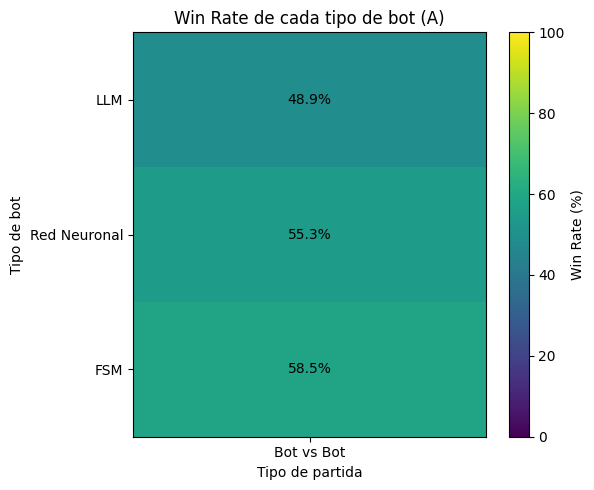

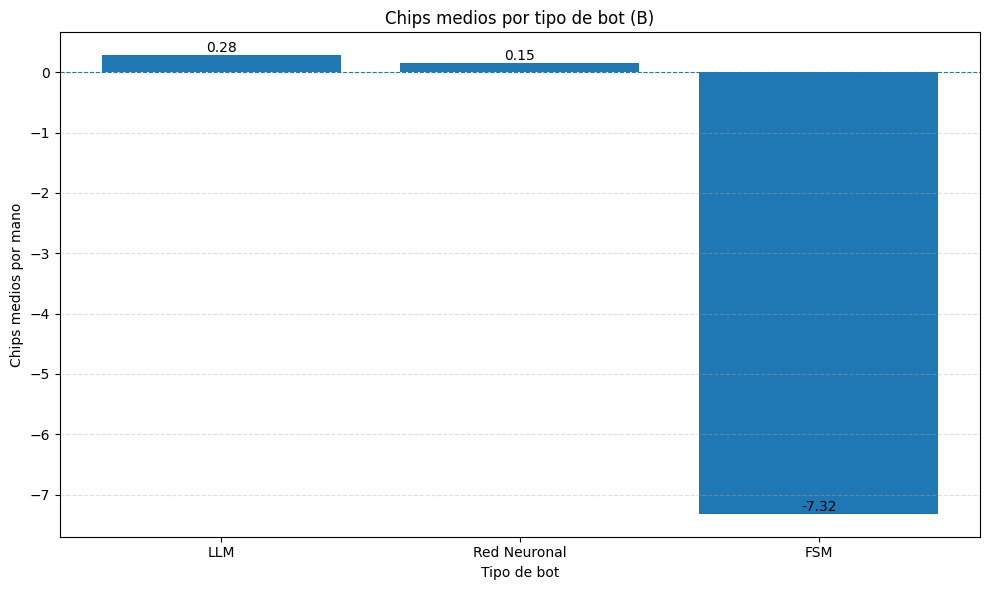

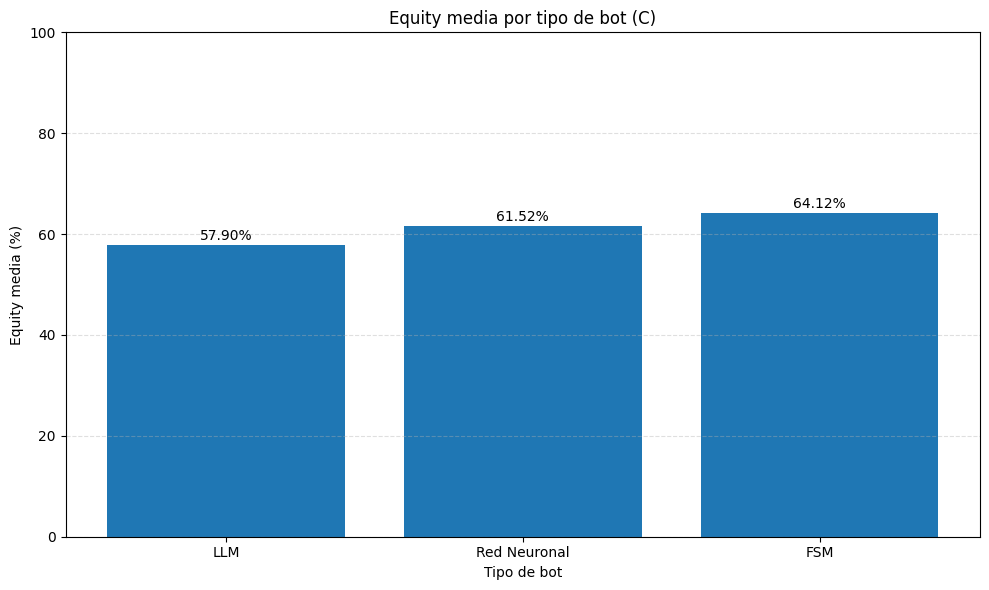

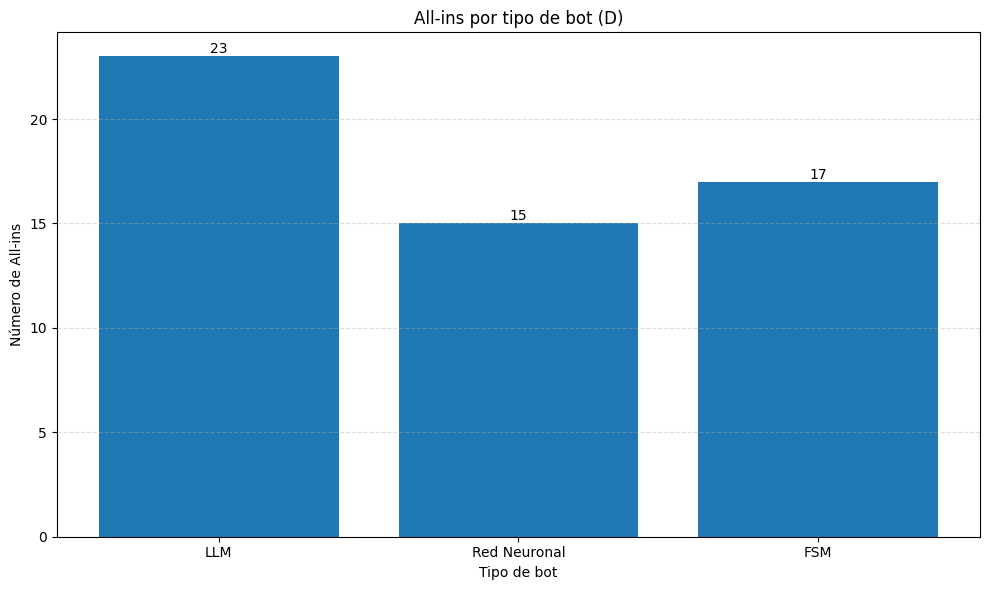

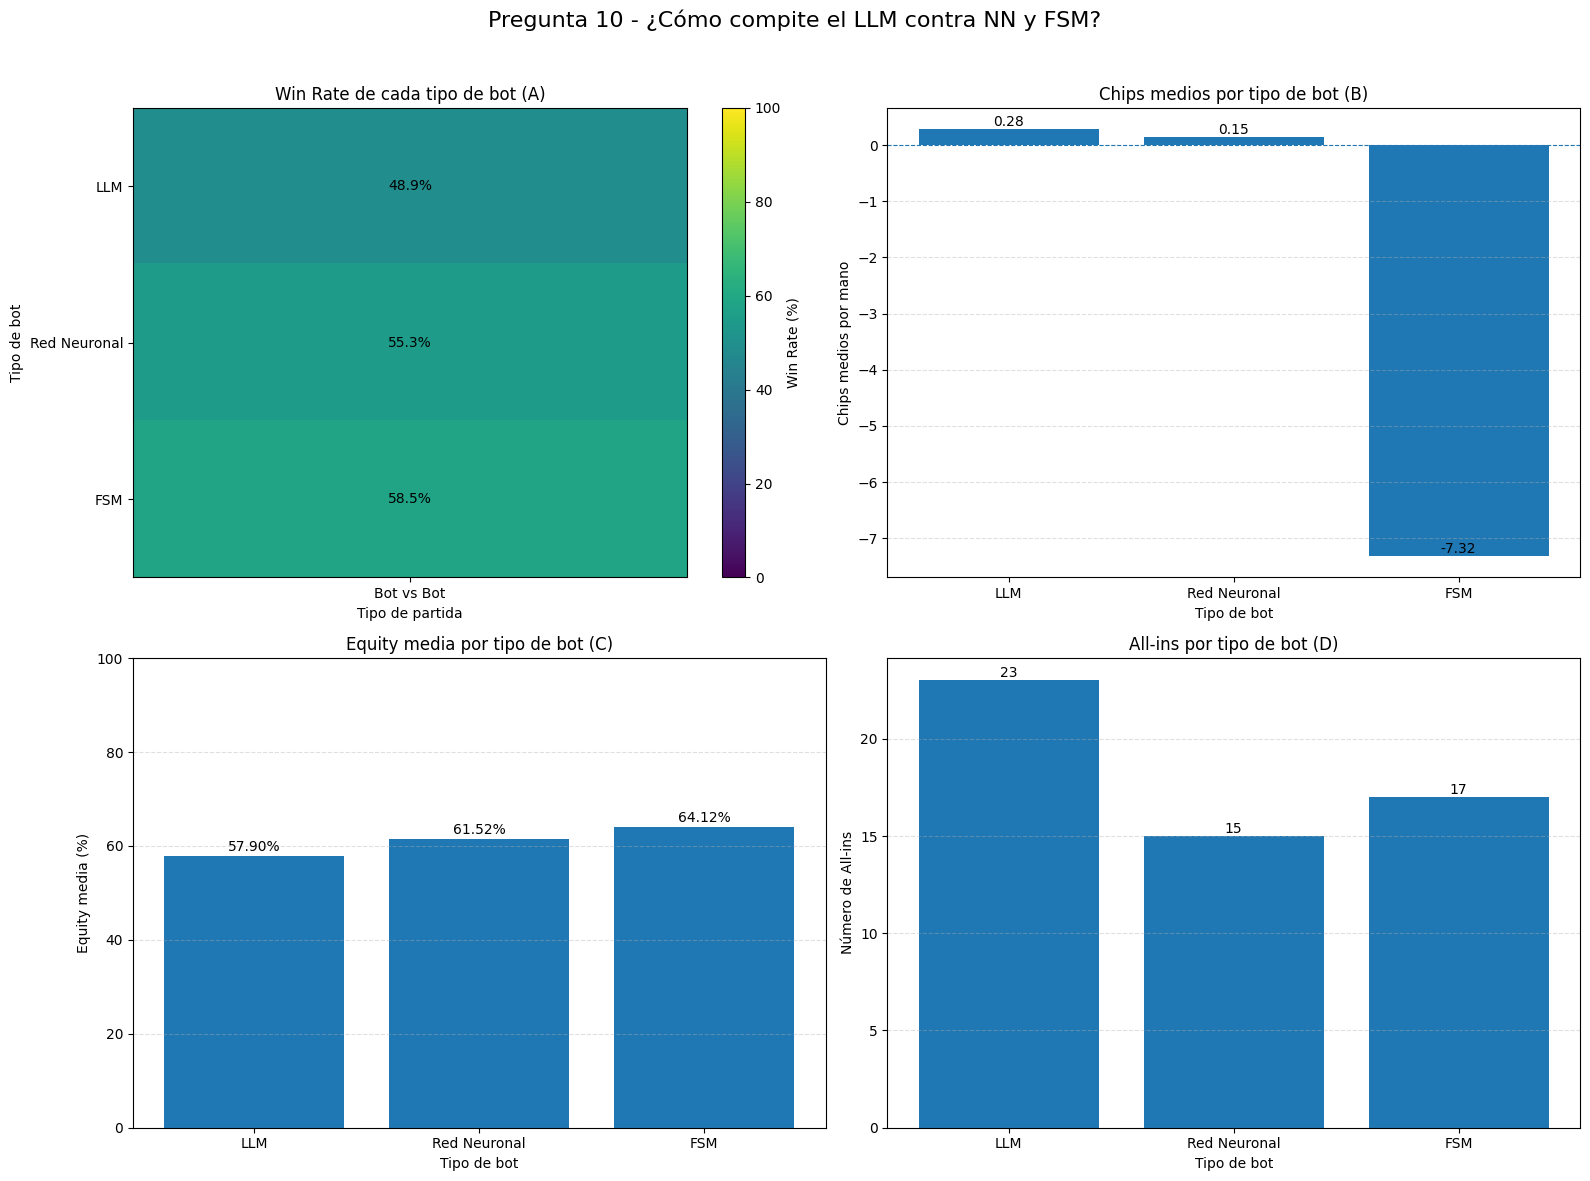

In [214]:
# ============================================================
# EJECUTAR PREGUNTA 10
# ============================================================

heatmap_pregunta_10()

chips_pregunta_10()

equity_pregunta_10()

allins_pregunta_10()

completa_pregunta_10()